# Diagnóstico de cobertura de la base RAMA para el estudio de contingencias atmosféricas (2015–2025)


Base: https://www.aire.cdmx.gob.mx/default.php?opc=%27aKBh%27

Estaciones: http://www.aire.cdmx.gob.mx/default.php?opc=%27ZaBhnmI=&dc=%27ZA==

Histórico de contingencias: http://www.aire.cdmx.gob.mx/descargas/ultima-hora/calidad-aire/pcaa/pcaa-historico-contingencias.pdf
## 1. Objetivo 

Este notebook tiene como propósito realizar un diagnóstico de la disponibilidad,
calidad y continuidad temporal de los datos horarios de la **Red Automática de
Monitoreo Atmosférico (RAMA)** durante el periodo 2015–2025.

El diagnóstico se realizará con un objetivo específico: determinar qué estaciones
y series temporales presentan información suficiente para estudiar posteriormente
la **detección temprana de condiciones asociadas con contingencias ambientales
atmosféricas en la Zona Metropolitana del Valle de México**.

A diferencia de un análisis general de calidad del aire, en este proyecto se
considerarán como **contaminantes objetivo**:

$$
O_3,\qquad PM_{10},\qquad PM_{2.5}.
$$

Esta selección responde a que las contingencias ambientales atmosféricas en la
ZMVM se encuentran asociadas con concentraciones elevadas de ozono y partículas
PM10 y PM2.5.

Por tanto, el diagnóstico de cobertura se realizará **por separado para cada
contaminante objetivo**.

Se definirán tres conjuntos de estaciones candidatas: $S_{O_3}$, $S_{PM_{10}}$ y $S_{PM_{2.5}}$, sin exigir que una misma estación tenga simultáneamente buena cobertura para los tres contaminantes.


### Contaminantes auxiliares

Los archivos RAMA contienen además información de otros contaminantes, entre ellos

$$
NO_2,\qquad NO_x,\qquad NO,\qquad CO,\qquad SO_2.
$$

Estos contaminantes **no serán utilizados inicialmente para seleccionar las estaciones objetivo**.

Sin embargo, se conservarán en la base original porque posteriormente podrán evaluarse como **variables predictoras o covariables químicas** para anticipar episodios de contaminación.

En particular, el problema futuro podrá plantearse de manera general como

$$
\mathbf{X}_t
\longrightarrow
Z_{t+h}^{(c)},
$$

donde

$$
c\in\{O_3,PM_{10},PM_{2.5}\},
$$

$\mathbf{X}_t$ representa la información disponible hasta el tiempo $t$ y
$Z_{t+h}^{(c)}$ representa la ocurrencia futura de una condición de interés
asociada con el contaminante $c$.

La definición exacta de $Z_{t+h}^{(c)}$, de los umbrales de contingencia y de los
horizontes de anticipación **no se realizará todavía en este notebook**.


## Objetivos específicos

Durante este notebook se buscará:

1. verificar la existencia y organización de los archivos RAMA correspondientes al periodo 2015–2025;

2. comprobar la estructura temporal de los registros horarios;

3. identificar valores faltantes, duplicados y posibles huecos temporales;

4. cuantificar la cobertura horaria de cada combinación

$$
(\text{año},\text{contaminante},\text{estación});
$$

5. estudiar la continuidad longitudinal de las estaciones para cada uno de los tres contaminantes objetivo;

6. identificar las estaciones con mejor disponibilidad para

$$
O_3,\qquad PM_{10},\qquad PM_{2.5};
$$

7. analizar posteriormente si la cobertura de las estaciones seleccionadas es
   suficiente para construir las variables temporales necesarias para estudiar
   contingencias;

8. generar tablas reproducibles que sirvan como entrada para los siguientes notebooks del proyecto.


## Alcance de esta etapa

En este notebook **no se realizará todavía**:

- imputación de concentraciones faltantes;
- definición formal de contingencias;
- construcción de etiquetas de eventos;
- cálculo de percentiles de extremos;
- entrenamiento de modelos de aprendizaje automático;
- incorporación de variables meteorológicas;
- selección definitiva de predictores químicos.

El objetivo de esta primera etapa es más fundamental: **determinar qué series horarias de O3, PM10 y PM2.5 poseen calidad, continuidad temporal y cobertura suficientes para construir posteriormente un problema reproducible de detección temprana de contingencias  atmosféricas.**

Las decisiones tomadas durante este notebook deberán basarse primero en la estructura real de los datos y no en criterios elegidos únicamente para maximizar el tamaño de la muestra.

# Conceptos fundamentales para estudiar este notebook

Este notebook tiene como objetivo determinar qué estaciones de la RAMA poseen
información temporal y espacial suficientemente adecuada para continuar el
estudio de contingencias atmosféricas asociadas con

$$
O_3,\qquad PM_{10},\qquad PM_{2.5}.
$$

Para comprender correctamente el procedimiento realizado, es recomendable
estudiar los siguientes conceptos.


## 1. Serie temporal

Una **serie temporal** es una sucesión de observaciones ordenadas en el tiempo.

Puede representarse como

$$
X_1,X_2,\ldots,X_T,
$$

donde $X_t$ es el valor observado en el instante $t$.

En este proyecto, cada estación genera series temporales de concentraciones de
contaminantes.

Por ejemplo,

$$
O_{3,t}^{(s)}
$$

representa la concentración de ozono registrada por la estación $s$ en la hora
$t$.

La característica fundamental de una serie temporal es que el orden de las
observaciones importa.



## 2. Resolución temporal

La **resolución temporal** indica con qué frecuencia se registran las
observaciones.

Los datos utilizados en este notebook tienen resolución horaria.

Por tanto, idealmente cada día contiene 24 observaciones.

Un año ordinario contiene

$$
365\times24=8760
$$

horas, mientras que un año bisiesto contiene

$$
366\times24=8784.
$$



## 3. Estación de monitoreo

Una estación de monitoreo es un punto físico donde se encuentran instrumentos
que registran concentraciones de contaminantes atmosféricos.

Una estación puede:

- medir varios contaminantes;
- medir solamente algunos contaminantes;
- aparecer en determinados años y no en otros;
- presentar periodos sin mediciones válidas.

Por esta razón, la disponibilidad debe estudiarse para cada combinación

$$
(\text{estación},\text{contaminante},\text{tiempo}).
$$



## 4. Red de monitoreo

Una **red de monitoreo** es un conjunto de estaciones que proporcionan
información sobre un contaminante.

Para el contaminante $c$ podemos representar su red mediante

$$
S_c=\{s_1,s_2,\ldots,s_m\}.
$$

Una idea fundamental de este notebook es que no existe necesariamente una única
red adecuada para todos los contaminantes.

Por ello se construyen redes diferentes:

$$
S_{O_3},\qquad
S_{PM_{10}},\qquad
S_{PM_{2.5}}.
$$



## 5. Contaminante objetivo y contaminante auxiliar

Un **contaminante objetivo** es aquel para el cual se desea construir
posteriormente el problema de detección temprana.

En este proyecto son:

$$
O_3,\qquad PM_{10},\qquad PM_{2.5}.
$$

Otros contaminantes, como

$$
NO_2,\qquad NO_x,\qquad NO,\qquad CO,\qquad SO_2,
$$

podrán utilizarse posteriormente como variables auxiliares o predictoras.

Por tanto,

$$
\text{variable objetivo}
\neq
\text{variable predictora}.
$$



## 6. Calidad e integridad estructural de los datos

Antes de analizar concentraciones es necesario comprobar que la base posee una
estructura consistente.

Entre las verificaciones realizadas se encuentran:

- número esperado de archivos;
- número esperado de filas;
- fechas válidas;
- horas válidas;
- registros duplicados;
- valores no numéricos;
- horas faltantes.

Este procedimiento se denomina **auditoría de datos**.

La existencia de un archivo no garantiza que los datos contenidos en él sean
completos:

$$
\text{archivo existente}
\not\Rightarrow
\text{serie completa}.
$$



## 7. Observaciones esperadas y observaciones disponibles

Las **observaciones esperadas** corresponden al número de mediciones que debería
tener una serie si funcionara continuamente.

Para un año $y$,

$$
H_y=
\begin{cases}
8760, & \text{año ordinario},\\
8784, & \text{año bisiesto}.
\end{cases}
$$

Las observaciones realmente almacenadas pueden ser menores.

Es importante utilizar como referencia el calendario teórico y no solamente el
número de registros existentes.


## 8. Datos faltantes

Un **dato faltante** representa una observación que debería existir pero cuya
medición no está disponible.

En los archivos de RAMA se utiliza principalmente el código

$$
-99
$$

para representar información no disponible.



## 2. Configuración inicial del análisis

Antes de comenzar a leer los archivos de RAMA se establecerán las librerías,
rutas y parámetros generales que serán utilizados durante todo el notebook.

El periodo principal de estudio será

$$
2015,\ldots,2025,
$$

es decir, once años completos.

Los contaminantes objetivo se definirán explícitamente como

$$
\mathcal{C}_{\mathrm{obj}}
=
\{O_3,PM_{10},PM_{2.5}\}.
$$

En los nombres de los archivos RAMA, PM2.5 aparece identificado mediante la
abreviatura `PM25`.

También se conservará una lista separada de contaminantes auxiliares que podrán
ser estudiados posteriormente como posibles variables predictoras:

$$
NO_2,\qquad NO_x,\qquad NO,\qquad CO,\qquad SO_2.
$$

En esta primera celda de código únicamente se:

1. importarán las librerías necesarias;
2. definirá el periodo de estudio;
3. establecerán los contaminantes objetivo y auxiliares;
4. comprobará que existen las carpetas anuales esperadas.

Todavía no se leerán los archivos de concentraciones.

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import re
import calendar
import matplotlib.pyplot as plt

In [2]:
# Ruta base: Las carpetas 15RAMA, 16RAMA, ..., 25RAMA 

RUTA_BASE = Path("")

# Periodo de estudio

ANIOS = range(2015, 2026)


# Contaminantes objetivo

CONTAMINANTES_OBJETIVO = [
    "O3",
    "PM10",
    "PM25"
]


# Contaminantes auxiliares

CONTAMINANTES_AUXILIARES = [
    "NO2",
    "NOX",
    "NO",
    "CO",
    "SO2"
]


# Comprobar existencia de carpetas anuales

print("Periodo de estudio:")
print(f"{min(ANIOS)}–{max(ANIOS)}")

print("\nContaminantes objetivo:")
print(CONTAMINANTES_OBJETIVO)

print("\nContaminantes auxiliares:")
print(CONTAMINANTES_AUXILIARES)

print("\nVerificación de carpetas RAMA:")

for anio in ANIOS:

    carpeta = (
        RUTA_BASE
        / f"{str(anio)[-2:]}RAMA"
    )

    estado = (
        "OK"
        if carpeta.exists()
        else "NO ENCONTRADA"
    )

    print(
        f"{anio}: {carpeta} -> {estado}"
    )

Periodo de estudio:
2015–2025

Contaminantes objetivo:
['O3', 'PM10', 'PM25']

Contaminantes auxiliares:
['NO2', 'NOX', 'NO', 'CO', 'SO2']

Verificación de carpetas RAMA:
2015: 15RAMA -> OK
2016: 16RAMA -> OK
2017: 17RAMA -> OK
2018: 18RAMA -> OK
2019: 19RAMA -> OK
2020: 20RAMA -> OK
2021: 21RAMA -> OK
2022: 22RAMA -> OK
2023: 23RAMA -> OK
2024: 24RAMA -> OK
2025: 25RAMA -> OK


## 3. Inventario de archivos RAMA

Una vez comprobada la existencia de las carpetas anuales, el siguiente paso
consiste en construir un inventario reproducible de los archivos disponibles.

Para cada archivo se registrarán:

- el año;
- la carpeta de origen;
- el nombre del archivo;
- el contaminante;
- la ruta completa utilizada para acceder a los datos.

Aunque el proyecto se enfocará posteriormente en

$$
O_3,\qquad PM_{10},\qquad PM_{2.5},
$$

en esta etapa se conservará el inventario completo de contaminantes.

Esto permitirá verificar que la estructura externa de la base sea consistente y
mantener disponibles los contaminantes auxiliares para análisis posteriores.

En particular, interesa comprobar que para cada año

$$
y\in\{2015,\ldots,2025\}
$$

exista exactamente un archivo correspondiente a cada contaminante objetivo.

La existencia del archivo todavía **no garantiza que los datos sean completos**.
En esta etapa únicamente se auditará la organización externa de la base.

In [3]:
# INVENTARIO DE ARCHIVOS RAMA

registros = []

for anio in ANIOS:

    carpeta = (
        RUTA_BASE
        / f"{str(anio)[-2:]}RAMA"
    )

    archivos = sorted(
        carpeta.glob("*.xls")
    )

    for archivo in archivos:

        # Eliminar los cuatro dígitos iniciales del año para obtener la abreviatura del contaminante.
        contaminante = re.sub(
            r"^\d{4}",
            "",
            archivo.stem
        )

        registros.append({
            "ANIO": anio,
            "CARPETA": carpeta.name,
            "ARCHIVO": archivo.name,
            "CONTAMINANTE": contaminante,
            "RUTA": str(archivo)
        })


inventario = pd.DataFrame(
    registros
)

# Resumen general

print(
    f"Total de archivos encontrados: "
    f"{len(inventario)}"
)

print(
    "\nNúmero de archivos por año:"
)

display(
    inventario
    .groupby("ANIO")
    .size()
    .rename("N_ARCHIVOS")
    .to_frame()
)

print(
    "\nArchivos correspondientes a los "
    "contaminantes objetivo:"
)

inventario_objetivo = (
    inventario[
        inventario["CONTAMINANTE"]
        .isin(CONTAMINANTES_OBJETIVO)
    ]
    .sort_values(
        ["ANIO", "CONTAMINANTE"]
    )
    .reset_index(drop=True)
)

display(inventario_objetivo)

Total de archivos encontrados: 99

Número de archivos por año:


,N_ARCHIVOS
ANIO,
2015,9
2016,9
2017,9
2018,9
2019,9
2020,9
2021,9
2022,9
2023,9



Archivos correspondientes a los contaminantes objetivo:


,ANIO,CARPETA,ARCHIVO,CONTAMINANTE,RUTA
0,2015,15RAMA,2015O3.xls,O3,15RAMA/2015O3.xls
1,2015,15RAMA,2015PM10.xls,PM10,15RAMA/2015PM10.xls
2,2015,15RAMA,2015PM25.xls,PM25,15RAMA/2015PM25.xls
3,2016,16RAMA,2016O3.xls,O3,16RAMA/2016O3.xls
4,2016,16RAMA,2016PM10.xls,PM10,16RAMA/2016PM10.xls
5,2016,16RAMA,2016PM25.xls,PM25,16RAMA/2016PM25.xls
6,2017,17RAMA,2017O3.xls,O3,17RAMA/2017O3.xls
7,2017,17RAMA,2017PM10.xls,PM10,17RAMA/2017PM10.xls
8,2017,17RAMA,2017PM25.xls,PM25,17RAMA/2017PM25.xls
9,2018,18RAMA,2018O3.xls,O3,18RAMA/2018O3.xls


Tenemos nuevamente los 99 archivos esperados, con nueve contaminantes por año, y específicamente los tres contaminantes objetivo aparecen en los once años:

$$
11\ \text{años}\times3\ \text{contaminantes objetivo}=33\ \text{archivos}.
$$

Conviene cerrar formalmente la auditoría del inventario objetivo verificando que exista exactamente un archivo para cada combinación año–contaminante. Así distinguimos claramente entre disponibilidad del archivo y calidad de los datos contenidos en él.

## 3.1. Consistencia del inventario de contaminantes objetivo

El inventario inicial identificó los archivos correspondientes a los tres
contaminantes que serán utilizados como variables objetivo:

$$
O_3,\qquad PM_{10},\qquad PM_{2.5}.
$$

Como el periodo comprende once años, si la estructura externa de la base es
completa deberían existir

$$
11\times3=33
$$

combinaciones año–contaminante.

Para verificarlo se construirá una matriz

$$
A_{c,y},
$$

donde

$$
A_{c,y}
=
\text{número de archivos encontrados para el contaminante }c
\text{ durante el año }y.
$$

La situación esperada es

$$
A_{c,y}=1
$$

para todas las combinaciones.

Por tanto:

- $A_{c,y}=0$ indicaría que falta un archivo;
- $A_{c,y}=1$ representa la situación esperada;
- $A_{c,y}>1$ indicaría posibles archivos duplicados.

Esta verificación únicamente evalúa la **estructura externa** de la base.

Es importante distinguir:

$$
\text{archivo disponible}
\not\Rightarrow
\text{serie temporal completa}.
$$

Un archivo puede existir y, aun así, contener estaciones ausentes, valores
`-99`, huecos temporales o periodos prolongados sin mediciones válidas.

Después de esta comprobación comenzará la auditoría del contenido de los
archivos horarios.

In [4]:
# CONSISTENCIA DEL INVENTARIO DE CONTAMINANTES OBJETIVO

disponibilidad_objetivo = (
    inventario_objetivo
    .groupby(
        ["CONTAMINANTE", "ANIO"]
    )
    .size()
    .unstack(fill_value=0)
    .reindex(
        CONTAMINANTES_OBJETIVO
    )
)

print(
    "Matriz de disponibilidad de archivos "
    "para los contaminantes objetivo:"
)

display(disponibilidad_objetivo)


# Verificación de faltantes y duplicados

n_faltantes = int(
    (disponibilidad_objetivo == 0)
    .sum()
    .sum()
)

n_duplicados = int(
    (disponibilidad_objetivo > 1)
    .sum()
    .sum()
)

estructura_completa = bool(
    (disponibilidad_objetivo == 1)
    .all()
    .all()
)


print("\nResumen de consistencia:")
print(
    f"Combinaciones esperadas : "
    f"{len(CONTAMINANTES_OBJETIVO) * len(ANIOS)}"
)
print(
    f"Combinaciones encontradas: "
    f"{len(inventario_objetivo)}"
)
print(
    f"Combinaciones faltantes : "
    f"{n_faltantes}"
)
print(
    f"Combinaciones duplicadas: "
    f"{n_duplicados}"
)
print(
    f"Estructura completa      : "
    f"{estructura_completa}"
)

Matriz de disponibilidad de archivos para los contaminantes objetivo:


ANIO,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
CONTAMINANTE,,,,,,,,,,,
O3,1,1,1,1,1,1,1,1,1,1,1
PM10,1,1,1,1,1,1,1,1,1,1,1
PM25,1,1,1,1,1,1,1,1,1,1,1



Resumen de consistencia:
Combinaciones esperadas : 33
Combinaciones encontradas: 33
Combinaciones faltantes : 0
Combinaciones duplicadas: 0
Estructura completa      : True


La estructura externa ya quedó completamente validada: 33=11×3 archivos objetivo, sin faltantes ni duplicados. Ahora sí conviene pasar del nivel archivo al nivel contenido.

## 4. Inspección de la estructura interna de un archivo objetivo

La existencia de los 33 archivos esperados confirma que la organización externa
de la base es consistente. El siguiente paso consiste en revisar la estructura
interna de los registros horarios.

Antes de automatizar la auditoría para todos los archivos, se inspeccionará un
archivo representativo:

$$
O_3,\qquad 2015.
$$

De acuerdo con la estructura de RAMA, cada archivo debe contener:

1. una columna `FECHA`;
2. una columna `HORA`;
3. una columna por cada estación de monitoreo disponible para el contaminante.

Cada fila representa una observación horaria.

Para un año ordinario como 2015 se esperan

$$
365\times24=8760
$$

registros.

En esta inspección inicial se verificará:

- dimensión de la tabla;
- nombres de las primeras columnas;
- número de estaciones;
- tipo de las variables `FECHA` y `HORA`;
- fecha inicial y final;
- valores observados de `HORA`;
- presencia de valores `-99`;
- presencia de valores `NaN`.

Los valores `-99` son especialmente importantes porque representan datos no
disponibles en los archivos RAMA, pero siguen siendo almacenados como valores
numéricos.

En esta etapa todavía no se modificarán los datos. El objetivo es observar
directamente cómo está almacenada la información original antes de establecer
las reglas generales de limpieza y cobertura.

In [5]:
# INSPECCIÓN DE UN ARCHIVO OBJETIVO REPRESENTATIVO
# O3 - 2015

fila_ejemplo = (
    inventario_objetivo.loc[
        (inventario_objetivo["ANIO"] == 2015)
        & (inventario_objetivo["CONTAMINANTE"] == "O3")
    ]
    .iloc[0]
)

ruta_ejemplo = Path(
    fila_ejemplo["RUTA"]
)

print("Archivo seleccionado:")
print(ruta_ejemplo)


# Lectura del archivo

df_ejemplo = pd.read_excel(
    ruta_ejemplo
)


# Dimensiones

print("\nDimensiones:")
print(
    f"Filas    : {df_ejemplo.shape[0]:,}"
)
print(
    f"Columnas : {df_ejemplo.shape[1]:,}"
)


# Estructura de columnas

print("\nPrimeras columnas:")
print(
    df_ejemplo.columns[:10].tolist()
)

columnas_estaciones = (
    df_ejemplo.columns[2:]
)

print(
    f"\nNúmero de estaciones: "
    f"{len(columnas_estaciones)}"
)

print("\nEstaciones:")
print(
    columnas_estaciones.tolist()
)


# Variables temporales

print("\nTipos de FECHA y HORA:")
print(
    df_ejemplo[
        ["FECHA", "HORA"]
    ].dtypes
)

print("\nRango de fechas:")
print(
    f"{df_ejemplo['FECHA'].min()} "
    f"-> "
    f"{df_ejemplo['FECHA'].max()}"
)

print("\nValores distintos de HORA:")
print(
    sorted(
        df_ejemplo["HORA"]
        .dropna()
        .unique()
        .tolist()
    )
)


# Valores faltantes

datos_estaciones = (
    df_ejemplo[
        columnas_estaciones
    ]
)

n_celdas = (
    datos_estaciones.size
)

n_menos99 = int(
    (datos_estaciones == -99)
    .sum()
    .sum()
)

n_nan = int(
    datos_estaciones
    .isna()
    .sum()
    .sum()
)

pct_menos99 = (
    100 * n_menos99 / n_celdas
)

pct_nan = (
    100 * n_nan / n_celdas
)


print("\nValores faltantes en las mediciones:")
print(
    f"Celdas de medición : {n_celdas:,}"
)
print(
    f"Valores -99        : "
    f"{n_menos99:,} "
    f"({pct_menos99:.2f}%)"
)
print(
    f"Valores NaN        : "
    f"{n_nan:,} "
    f"({pct_nan:.2f}%)"
)


# Primeras observaciones

print("\nPrimeras cinco observaciones:")
display(df_ejemplo.head())

Archivo seleccionado:
15RAMA/2015O3.xls

Dimensiones:
Filas    : 8,760
Columnas : 37

Primeras columnas:
['FECHA', 'HORA', 'ACO', 'AJM', 'AJU', 'ATI', 'BJU', 'CAM', 'CCA', 'CHO']

Número de estaciones: 35

Estaciones:
['ACO', 'AJM', 'AJU', 'ATI', 'BJU', 'CAM', 'CCA', 'CHO', 'COY', 'CUA', 'CUT', 'FAC', 'GAM', 'HGM', 'INN', 'IZT', 'LLA', 'LPR', 'MER', 'MGH', 'MON', 'NEZ', 'PED', 'SAG', 'SFE', 'SJA', 'SUR', 'TAH', 'TLA', 'TLI', 'TPN', 'UAX', 'UIZ', 'VIF', 'XAL']

Tipos de FECHA y HORA:
FECHA    datetime64[ns]
HORA              int64
dtype: object

Rango de fechas:
2015-01-01 00:00:00 -> 2015-12-31 00:00:00

Valores distintos de HORA:
[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24]

Valores faltantes en las mediciones:
Celdas de medición : 306,600
Valores -99        : 73,521 (23.98%)
Valores NaN        : 0 (0.00%)

Primeras cinco observaciones:


,FECHA,HORA,ACO,AJM,AJU,ATI,BJU,CAM,CCA,CHO,...,SJA,SUR,TAH,TLA,TLI,TPN,UAX,UIZ,VIF,XAL
0,2015-01-01,1,4,8,20,21,-99,2,2,3,...,3,2,6,3,2,20,2,2,2,-99
1,2015-01-01,2,5,2,31,16,-99,2,4,6,...,3,2,16,3,3,15,2,2,3,-99
2,2015-01-01,3,6,3,26,10,-99,3,1,4,...,3,1,7,4,3,21,2,4,3,-99
3,2015-01-01,4,7,6,17,7,-99,3,2,5,...,4,2,5,4,3,15,4,4,2,-99
4,2015-01-01,5,6,2,20,5,-99,3,1,4,...,4,2,5,2,3,20,5,4,5,-99


## 4.1. Auditoría estructural de los 33 archivos objetivo

La inspección individual de $O_3$ durante 2015 mostró que el archivo presenta la
estructura temporal esperada, pero también una cantidad importante de valores
`-99`.

El siguiente paso consiste en extender esta auditoría a los

$$
11\times3=33
$$

archivos correspondientes a

$$
O_3,\qquad PM_{10},\qquad PM_{2.5}.
$$

Para cada combinación año–contaminante se verificará:

- número de filas;
- número esperado de horas del año;
- diferencia entre observaciones esperadas y observadas;
- rango de fechas;
- presencia de las horas $1,\ldots,24$;
- registros duplicados en la combinación `FECHA`–`HORA`;
- fechas inválidas;
- valores no numéricos en las columnas de estaciones;
- número de estaciones incluidas;
- cantidad y porcentaje de valores `-99`;
- cantidad de valores `NaN`.

Para un año $y$, el número teórico de registros será

$$
H_y=
\begin{cases}
8760, & \text{si }y\text{ no es bisiesto},\\
8784, & \text{si }y\text{ es bisiesto}.
\end{cases}
$$

La comparación se realizará contra este calendario teórico y no solamente contra
el número de filas efectivamente almacenadas.

Esto es importante porque un archivo podría presentar una estructura interna
aparentemente regular y, aun así, omitir determinadas combinaciones

$$
(\text{FECHA},\text{HORA}).
$$

En esta etapa todavía no se imputará ningún registro faltante. Primero se
identificarán y documentarán las irregularidades estructurales de la base
original.

In [6]:
# AUDITORÍA ESTRUCTURAL DE LOS 33 ARCHIVOS OBJETIVO

resultados_auditoria = []

for _, fila in inventario_objetivo.iterrows():

    anio = int(
        fila["ANIO"]
    )

    contaminante = (
        fila["CONTAMINANTE"]
    )

    ruta = Path(
        fila["RUTA"]
    )

    # Lectura

    df = pd.read_excel(
        ruta
    )

    # Número teórico de horas del año

    horas_esperadas = (
        8784
        if calendar.isleap(anio)
        else 8760
    )

    # Variables temporales

    fecha = pd.to_datetime(
        df["FECHA"],
        errors="coerce"
    )

    hora = pd.to_numeric(
        df["HORA"],
        errors="coerce"
    )

    n_fechas_invalidas = int(
        fecha.isna().sum()
    )

    horas_observadas = sorted(
        hora.dropna()
        .unique()
        .tolist()
    )

    horas_1_24 = (
        horas_observadas
        == list(range(1, 25))
    )

    # Duplicados FECHA-HORA

    n_duplicados_temporales = int(
        pd.DataFrame({
            "FECHA": fecha,
            "HORA": hora
        })
        .duplicated()
        .sum()
    )

    # Columnas de estaciones

    estaciones = (
        df.columns[2:]
    )

    datos = (
        df[estaciones]
    )

    # Conversión numérica para identificar posibles valores no numéricos.
    datos_numericos = (
        datos.apply(
            pd.to_numeric,
            errors="coerce"
        )
    )

    # Un valor se considera no numérico si originalmente estaba presente pero se convierte en NaN.
    no_numericos = (
        datos.notna()
        & datos_numericos.isna()
    )

    n_no_numericos = int(
        no_numericos
        .sum()
        .sum()
    )

    # -99 y NaN

    n_celdas = (
        datos_numericos.size
    )

    n_menos99 = int(
        (datos_numericos == -99)
        .sum()
        .sum()
    )

    n_nan = int(
        datos_numericos
        .isna()
        .sum()
        .sum()
    )

    pct_menos99 = (
        100 * n_menos99 / n_celdas
        if n_celdas > 0
        else np.nan
    )

    # Guardar resultados

    resultados_auditoria.append({
        "ANIO": anio,
        "CONTAMINANTE": contaminante,
        "FILAS_OBSERVADAS": len(df),
        "FILAS_ESPERADAS": horas_esperadas,
        "DIFERENCIA_FILAS":
            len(df) - horas_esperadas,
        "FECHA_INICIO":
            fecha.min(),
        "FECHA_FIN":
            fecha.max(),
        "HORAS_1_24_COMPLETAS":
            horas_1_24,
        "DUPLICADOS_FECHA_HORA":
            n_duplicados_temporales,
        "FECHAS_INVALIDAS":
            n_fechas_invalidas,
        "N_ESTACIONES":
            len(estaciones),
        "VALORES_NO_NUMERICOS":
            n_no_numericos,
        "N_MENOS99":
            n_menos99,
        "PCT_MENOS99":
            pct_menos99,
        "N_NAN":
            n_nan
    })


auditoria_objetivo = pd.DataFrame(
    resultados_auditoria
)

auditoria_objetivo[
    "PCT_MENOS99"
] = (
    auditoria_objetivo[
        "PCT_MENOS99"
    ]
    .round(2)
)


# RESUMEN

print(
    "Archivos auditados:",
    len(auditoria_objetivo)
)

print(
    "\nArchivos con número de filas "
    "distinto al esperado:"
)

display(
    auditoria_objetivo.loc[
        auditoria_objetivo[
            "DIFERENCIA_FILAS"
        ] != 0,
        [
            "ANIO",
            "CONTAMINANTE",
            "FILAS_OBSERVADAS",
            "FILAS_ESPERADAS",
            "DIFERENCIA_FILAS"
        ]
    ]
)


print(
    "\nResumen de posibles problemas estructurales:"
)

print(
    "Archivos sin horas 1–24 completas:",
    int(
        (
            ~auditoria_objetivo[
                "HORAS_1_24_COMPLETAS"
            ]
        ).sum()
    )
)

print(
    "Duplicados FECHA-HORA:",
    int(
        auditoria_objetivo[
            "DUPLICADOS_FECHA_HORA"
        ].sum()
    )
)

print(
    "Fechas inválidas:",
    int(
        auditoria_objetivo[
            "FECHAS_INVALIDAS"
        ].sum()
    )
)

print(
    "Valores no numéricos:",
    int(
        auditoria_objetivo[
            "VALORES_NO_NUMERICOS"
        ].sum()
    )
)


print(
    "\nNúmero de estaciones y porcentaje de -99:"
)

display(
    auditoria_objetivo[
        [
            "ANIO",
            "CONTAMINANTE",
            "N_ESTACIONES",
            "PCT_MENOS99",
            "N_NAN"
        ]
    ]
)

Archivos auditados: 33

Archivos con número de filas distinto al esperado:


,ANIO,CONTAMINANTE,FILAS_OBSERVADAS,FILAS_ESPERADAS,DIFERENCIA_FILAS
27,2024,O3,8782,8784,-2
28,2024,PM10,8782,8784,-2
29,2024,PM25,8782,8784,-2



Resumen de posibles problemas estructurales:
Archivos sin horas 1–24 completas: 0
Duplicados FECHA-HORA: 0
Fechas inválidas: 0
Valores no numéricos: 0

Número de estaciones y porcentaje de -99:


,ANIO,CONTAMINANTE,N_ESTACIONES,PCT_MENOS99,N_NAN
0,2015,O3,35,23.98,0
1,2015,PM10,24,23.96,0
2,2015,PM25,20,28.57,0
3,2016,O3,34,14.29,0
4,2016,PM10,24,19.46,0
5,2016,PM25,21,28.39,0
6,2017,O3,34,15.45,0
7,2017,PM10,24,26.42,0
8,2017,PM25,21,33.32,0
9,2018,O3,34,21.23,0


La auditoría confirma dos cosas importantes.

Primero, la estructura de los 33 archivos es muy limpia: no hay duplicados `FECHA-HORA`, fechas inválidas ni valores no numéricos, y todos manejan correctamente las horas $1,\ldots,24$. Segundo, la única irregularidad estructural aparece en 2024: los tres contaminantes tienen exactamente 8782 filas en lugar de 8784.

Esto sugiere que podrían faltar las mismas dos horas en los tres archivos. Conviene verificarlo explícitamente antes de continuar.

También hay que ser cuidadosos con `PCT_MENOS99`: por ejemplo, PM2.5 alcanza casi (50%) en 2024, pero este porcentaje está calculado sobre **todas las columnas de estaciones del archivo**, incluyendo estaciones que pueden estar inactivas durante largos periodos. Por eso todavía no debemos interpretar esos porcentajes como la calidad real de la red. La cobertura correcta se calculará después estación por estación.

## 4.2. Identificación de los registros horarios ausentes en 2024

La auditoría estructural mostró que los tres contaminantes objetivo presentan en 2024:

$$
8782
$$

registros, cuando un año bisiesto debería contener

$$
366\times24=8784
$$

combinaciones `FECHA`–`HORA`.

Por tanto, en cada archivo faltan exactamente dos registros horarios.

El siguiente paso consiste en identificar esas combinaciones temporales y determinar si las ausencias son comunes a

$$
O_3,\qquad PM_{10},\qquad PM_{2.5}.
$$

Para ello se construirá el calendario horario teórico de 2024:

$$
\mathcal{T}_{2024}
=
\{
(d,h):
d\in\text{fechas de 2024},
\;
h\in\{1,\ldots,24\}
\}.
$$

Este conjunto contiene

$$
|\mathcal{T}_{2024}|=8784
$$

combinaciones.

Para cada contaminante se comparará el conjunto teórico con las combinaciones realmente presentes en el archivo.

Si los mismos registros faltan en los tres contaminantes, esto sugerirá una interrupción común de la base o del sistema de registro y no un problema específico de un contaminante.

Estos registros no serán imputados en esta etapa. Su ausencia se conservará explícitamente para que posteriormente cuente como falta de información al calcular la cobertura temporal.

In [7]:
# IDENTIFICAR LAS HORAS AUSENTES EN 2024

ANIO_AUDITAR = 2024

# Calendario teórico de 2024
# FECHA × HORA

fechas_2024 = pd.date_range(
    start="2024-01-01",
    end="2024-12-31",
    freq="D"
)

calendario_teorico_2024 = pd.MultiIndex.from_product(
    [
        fechas_2024,
        range(1, 25)
    ],
    names=["FECHA", "HORA"]
).to_frame(index=False)

print(
    "Combinaciones FECHA-HORA esperadas:",
    len(calendario_teorico_2024)
)


# Buscar registros ausentes por contaminante

faltantes_2024 = []

conjuntos_faltantes = {}

for contaminante in CONTAMINANTES_OBJETIVO:

    ruta = Path(
        inventario_objetivo.loc[
            (inventario_objetivo["ANIO"] == ANIO_AUDITAR)
            & (
                inventario_objetivo["CONTAMINANTE"]
                == contaminante
            ),
            "RUTA"
        ].iloc[0]
    )

    df = pd.read_excel(
        ruta,
        usecols=["FECHA", "HORA"]
    )

    df["FECHA"] = pd.to_datetime(
        df["FECHA"],
        errors="coerce"
    )

    df["HORA"] = pd.to_numeric(
        df["HORA"],
        errors="coerce"
    ).astype(int)

    observados = (
        df[
            ["FECHA", "HORA"]
        ]
        .drop_duplicates()
    )

    comparacion = (
        calendario_teorico_2024
        .merge(
            observados,
            on=["FECHA", "HORA"],
            how="left",
            indicator=True
        )
    )

    faltantes = (
        comparacion.loc[
            comparacion["_merge"] == "left_only",
            ["FECHA", "HORA"]
        ]
        .copy()
    )

    faltantes["CONTAMINANTE"] = contaminante

    faltantes_2024.append(
        faltantes
    )

    conjuntos_faltantes[contaminante] = set(
        zip(
            faltantes["FECHA"],
            faltantes["HORA"]
        )
    )


faltantes_2024 = pd.concat(
    faltantes_2024,
    ignore_index=True
)

print(
    "\nRegistros horarios ausentes:"
)

display(
    faltantes_2024[
        [
            "CONTAMINANTE",
            "FECHA",
            "HORA"
        ]
    ]
)


# Verificar si las ausencias son comunes

faltantes_comunes = set.intersection(
    *conjuntos_faltantes.values()
)

mismos_faltantes = all(
    conjunto == faltantes_comunes
    for conjunto in conjuntos_faltantes.values()
)

print(
    "\n¿Los tres contaminantes presentan "
    "exactamente los mismos registros ausentes?",
    mismos_faltantes
)

print(
    "\nRegistros ausentes comunes:"
)

for fecha, hora in sorted(
    faltantes_comunes
):
    print(
        f"{fecha.date()} - HORA {hora}"
    )

Combinaciones FECHA-HORA esperadas: 8784

Registros horarios ausentes:


,CONTAMINANTE,FECHA,HORA
0,O3,2024-01-17,19
1,O3,2024-04-06,24
2,PM10,2024-01-17,19
3,PM10,2024-04-06,24
4,PM25,2024-01-17,19
5,PM25,2024-04-06,24



¿Los tres contaminantes presentan exactamente los mismos registros ausentes? True

Registros ausentes comunes:
2024-01-17 - HORA 19
2024-04-06 - HORA 24


Los dos huecos de 2024 son comunes a los tres contaminantes, así que los trataremos como ausencias temporales estructurales de la base y no como fallas específicas de O$_3$, PM10 o PM2.5. Además, representan solamente

$$
\frac{2}{8784}\times 100 \approx 0.023%
$$

del año, por lo que no justifican ningún tratamiento especial en este punto. Lo correcto será que simplemente cuenten como horas no disponibles cuando calculemos cobertura.


## 5. Cobertura horaria por estación y contaminante objetivo

Una vez verificada la estructura temporal de los archivos, se analizará la disponibilidad efectiva de las mediciones para cada combinación

$$
(\text{año},\text{contaminante},\text{estación}).
$$

Éste constituye uno de los pasos centrales del diagnóstico.

Para una estación $s$, contaminante $c$ y año $y$, se definirá la cobertura
horaria como

$$
C_{s,c,y}
=
\frac{N_{s,c,y}^{(\mathrm{válido})}}
{H_y}
\times 100,
$$

donde:

- $N_{s,c,y}^{(\mathrm{válido})}$ es el número de observaciones horarias válidas;
- $H_y$ es el número teórico de horas del año.

Por tanto,

$$
H_y=
\begin{cases}
8760, & \text{año ordinario},\\
8784, & \text{año bisiesto}.
\end{cases}
$$

Una observación será considerada válida cuando:

1. pueda interpretarse como un valor numérico;
2. no sea `NaN`;
3. no corresponda al código `-99`.

Es importante utilizar como denominador el número teórico de horas y no el número de filas almacenadas en cada archivo. De esta manera, las dos horas ausentes identificadas en 2024 también cuentan correctamente como información faltante.


### Ausencia de una estación en un archivo

La lista de estaciones no es necesariamente idéntica entre años.

Por ello debe distinguirse entre:

$$
\text{estación presente en el archivo pero sin mediciones válidas}
$$

y

$$
\text{estación completamente ausente del archivo}.
$$

Para evitar sobreestimar la continuidad longitudinal, para cada contaminante se
construirá primero la unión de todas las estaciones observadas durante
2015–2025:

$$
S_c
=
\bigcup_{y=2015}^{2025}S_{c,y}.
$$

Posteriormente se construirá el panel completo

$$
S_c
\times
\{2015,\ldots,2025\}.
$$

Si una estación no aparece en el archivo correspondiente a determinado año, se
registrará explícitamente con

$$
C_{s,c,y}=0.
$$

De esta manera, una estación que únicamente operó durante algunos años no podrá
parecer artificialmente buena al calcular su cobertura promedio utilizando
solamente los periodos en que estuvo presente.


### Enfoque independiente por contaminante

En este notebook las estaciones se evaluarán independientemente para

$$
O_3,\qquad PM_{10},\qquad PM_{2.5}.
$$

En esta etapa **no se calculará ninguna intersección entre los tres conjuntos de
estaciones**.

El objetivo es conocer primero la red temporal disponible para cada contaminante
objetivo por separado.

In [8]:
# COBERTURA HORARIA POR ESTACIÓN, AÑO Y CONTAMINANTE OBJETIVO

registros_cobertura = []

# 1. Calcular cobertura para las estaciones que aparecen físicamente en cada archivo

for _, fila in inventario_objetivo.iterrows():

    anio = int(
        fila["ANIO"]
    )

    contaminante = (
        fila["CONTAMINANTE"]
    )

    ruta = Path(
        fila["RUTA"]
    )

    df = pd.read_excel(
        ruta
    )

    horas_esperadas = (
        8784
        if calendar.isleap(anio)
        else 8760
    )

    estaciones = (
        df.columns[2:]
    )

    for estacion in estaciones:

        serie = pd.to_numeric(
            df[estacion],
            errors="coerce"
        )

        n_nan = int(
            serie.isna().sum()
        )

        n_menos99 = int(
            (serie == -99).sum()
        )

        validos = (
            serie.notna()
            & (serie != -99)
        )

        n_validos = int(
            validos.sum()
        )

        cobertura_pct = (
            100
            * n_validos
            / horas_esperadas
        )

        registros_cobertura.append({
            "ANIO": anio,
            "CONTAMINANTE": contaminante,
            "ESTACION": estacion,
            "HORAS_ESPERADAS": horas_esperadas,
            "HORAS_EN_ARCHIVO": len(df),
            "N_VALIDOS": n_validos,
            "N_MENOS99": n_menos99,
            "N_NAN": n_nan,
            "COBERTURA_PCT": cobertura_pct,
            "PRESENTE_EN_ARCHIVO": True
        })


cobertura_observada = pd.DataFrame(
    registros_cobertura
)


# 2. CONSTRUIR PANEL COMPLETO POR CONTAMINANTE

paneles = []

for contaminante in CONTAMINANTES_OBJETIVO:

    # Unión de estaciones que aparecen al menos una vez
    estaciones_contaminante = sorted(
        cobertura_observada.loc[
            cobertura_observada["CONTAMINANTE"]
            == contaminante,
            "ESTACION"
        ].unique()
    )

    panel = pd.MultiIndex.from_product(
        [
            [contaminante],
            estaciones_contaminante,
            list(ANIOS)
        ],
        names=[
            "CONTAMINANTE",
            "ESTACION",
            "ANIO"
        ]
    ).to_frame(index=False)

    paneles.append(
        panel
    )


panel_teorico = pd.concat(
    paneles,
    ignore_index=True
)


# Incorporar coberturas observadas

cobertura_panel = (
    panel_teorico
    .merge(
        cobertura_observada,
        on=[
            "CONTAMINANTE",
            "ESTACION",
            "ANIO"
        ],
        how="left"
    )
)


# 3. COMPLETAR COMBINACIONES AUSENTES

cobertura_panel["PRESENTE_EN_ARCHIVO"] = (
    cobertura_panel[
        "PRESENTE_EN_ARCHIVO"
    ]
    .fillna(False)
    .astype(bool)
)

cobertura_panel["AUSENTE_DEL_ARCHIVO"] = (
    ~cobertura_panel[
        "PRESENTE_EN_ARCHIVO"
    ]
)

# Horas teóricas según el año
cobertura_panel["HORAS_ESPERADAS"] = (
    cobertura_panel["ANIO"]
    .apply(
        lambda y:
        8784
        if calendar.isleap(int(y))
        else 8760
    )
)

# Las combinaciones ausentes se registran con cero datos
columnas_cero = [
    "HORAS_EN_ARCHIVO",
    "N_VALIDOS",
    "N_MENOS99",
    "N_NAN",
    "COBERTURA_PCT"
]

cobertura_panel[columnas_cero] = (
    cobertura_panel[columnas_cero]
    .fillna(0)
)

cobertura_panel[
    "PRESENTE_SIN_DATOS"
] = (
    cobertura_panel[
        "PRESENTE_EN_ARCHIVO"
    ]
    & (
        cobertura_panel[
            "N_VALIDOS"
        ] == 0
    )
)

cobertura_panel[
    "COBERTURA_PCT"
] = (
    cobertura_panel[
        "COBERTURA_PCT"
    ]
    .round(2)
)


# 4. RESUMEN DEL PANEL

resumen_panel = (
    cobertura_panel
    .groupby("CONTAMINANTE")
    .agg(
        N_ESTACIONES=(
            "ESTACION",
            "nunique"
        ),
        COMBINACIONES_ESTACION_ANIO=(
            "ESTACION",
            "size"
        ),
        AUSENTE_DEL_ARCHIVO=(
            "AUSENTE_DEL_ARCHIVO",
            "sum"
        ),
        PRESENTE_SIN_DATOS=(
            "PRESENTE_SIN_DATOS",
            "sum"
        ),
        COBERTURA_MEDIANA_PCT=(
            "COBERTURA_PCT",
            "median"
        ),
        COBERTURA_MIN_PCT=(
            "COBERTURA_PCT",
            "min"
        ),
        COBERTURA_MAX_PCT=(
            "COBERTURA_PCT",
            "max"
        )
    )
    .reset_index()
)

columnas_pct = [
    "COBERTURA_MEDIANA_PCT",
    "COBERTURA_MIN_PCT",
    "COBERTURA_MAX_PCT"
]

resumen_panel[columnas_pct] = (
    resumen_panel[columnas_pct]
    .round(2)
)


print(
    "Dimensiones de la tabla observada:",
    cobertura_observada.shape
)

print(
    "Dimensiones del panel completo:",
    cobertura_panel.shape
)

print(
    "\nResumen por contaminante objetivo:"
)

resumen_panel

Dimensiones de la tabla observada: (927, 10)
Dimensiones del panel completo: (1067, 12)

Resumen por contaminante objetivo:


/var/folders/16/rwkptmp92_b7tw7nx11rkvbw0000gn/T/ipykernel_6211/1459555367.py:145: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .fillna(False)


,CONTAMINANTE,N_ESTACIONES,COMBINACIONES_ESTACION_ANIO,AUSENTE_DEL_ARCHIVO,PRESENTE_SIN_DATOS,COBERTURA_MEDIANA_PCT,COBERTURA_MIN_PCT,COBERTURA_MAX_PCT
0,O3,39,429,41,27,82.91,0.0,96.93
1,PM10,31,341,53,44,67.80,0.0,98.59
2,PM25,27,297,46,49,65.68,0.0,98.59


La salida ya muestra una diferencia importante entre los tres problemas:

$$
|S_{O_3}|=39,\qquad |S_{PM10}|=31,\qquad |S_{PM2.5}|=27.
$$

Además, O$_3$ presenta una cobertura mediana claramente mayor: 82.91%, 
frente a (67.80%) para PM10 y (65.68%) para PM2.5. Esto anticipa que probablemente podremos trabajar con una red más amplia y continua para ozono.

También es importante distinguir las dos situaciones que aparecen en el panel:

* `AUSENTE_DEL_ARCHIVO`: la estación ni siquiera aparece como columna ese año;
* `PRESENTE_SIN_DATOS`: la estación aparece, pero no tiene ninguna observación válida.

Todavía no conviene establecer un umbral definitivo de selección. Primero debemos estudiar la continuidad longitudinal de cada estación durante los once años.

## 5.1. Continuidad longitudinal de las estaciones

La cobertura de un solo año no es suficiente para determinar si una estación es
adecuada para un estudio de detección temprana.

Para construir y validar modelos temporales durante 2015–2025 se requiere que
las estaciones presenten una trayectoria suficientemente continua a lo largo
del periodo.

Por esta razón, para cada combinación

$$
(\text{contaminante},\text{estación})
$$

se resumirá la información de los once años mediante los siguientes indicadores.

### Años de presencia en los archivos

Se definirá $N_{\mathrm{archivo}}$ como el número de años en los que la estación aparece físicamente como columna dentro del archivo correspondiente.

### Años con mediciones válidas

Se definirá $N_{\mathrm{datos}}$ como el número de años en los que la estación presenta al menos una observación
válida:

$$
N_{s,c,y}^{(\mathrm{válido})}>0.
$$

Esto permite distinguir una estación presente nominalmente de una estación que
realmente produjo información.

### Años que superan determinados niveles de cobertura

Como diagnóstico se calcularán también:

$$
N_{\geq50},
\qquad
N_{\geq75},
\qquad
N_{\geq90},
$$

donde, por ejemplo,

$$
N_{\geq75}
=
\sum_{y=2015}^{2025}
I(C_{s,c,y}\geq75\%).
$$

Los valores de $50\%$, $75\%$ y $90\%$ se utilizarán únicamente como
**referencias descriptivas**.

En esta etapa no representan todavía criterios definitivos para excluir
estaciones.

### Resumen de la cobertura anual

Para cada estación se calcularán además:

- cobertura media;
- cobertura mediana;
- cobertura mínima;
- cobertura máxima.

La mediana será especialmente útil porque es menos sensible que la media a uno
o dos años excepcionalmente malos.

Sin embargo, una cobertura mediana alta tampoco garantiza continuidad. Por
ejemplo, una estación podría presentar coberturas cercanas al $95\%$ durante
seis años y estar completamente ausente durante los cinco restantes.

Por ello, la selección posterior deberá considerar conjuntamente:

$$
\text{nivel de cobertura}
+
\text{continuidad longitudinal}
+
\text{estabilidad entre años}.
$$

El análisis se realizará de forma independiente para

$$
O_3,\qquad PM_{10},\qquad PM_{2.5}.
$$

In [9]:
# CONTINUIDAD LONGITUDINAL POR ESTACIÓN Y CONTAMINANTE

resumen_longitudinal = (
    cobertura_panel
    .groupby(
        [
            "CONTAMINANTE",
            "ESTACION"
        ]
    )
    .agg(
        ANIOS_EN_ARCHIVO=(
            "PRESENTE_EN_ARCHIVO",
            "sum"
        ),
        ANIOS_CON_DATOS=(
            "N_VALIDOS",
            lambda x: int((x > 0).sum())
        ),
        ANIOS_GE_50=(
            "COBERTURA_PCT",
            lambda x: int((x >= 50).sum())
        ),
        ANIOS_GE_75=(
            "COBERTURA_PCT",
            lambda x: int((x >= 75).sum())
        ),
        ANIOS_GE_90=(
            "COBERTURA_PCT",
            lambda x: int((x >= 90).sum())
        ),
        COBERTURA_MEDIA=(
            "COBERTURA_PCT",
            "mean"
        ),
        COBERTURA_MEDIANA=(
            "COBERTURA_PCT",
            "median"
        ),
        COBERTURA_MIN=(
            "COBERTURA_PCT",
            "min"
        ),
        COBERTURA_MAX=(
            "COBERTURA_PCT",
            "max"
        )
    )
    .reset_index()
)


# Redondear indicadores porcentuales

columnas_cobertura = [
    "COBERTURA_MEDIA",
    "COBERTURA_MEDIANA",
    "COBERTURA_MIN",
    "COBERTURA_MAX"
]

resumen_longitudinal[
    columnas_cobertura
] = (
    resumen_longitudinal[
        columnas_cobertura
    ]
    .round(2)
)


# Resumen general por contaminante

print(
    "Número de combinaciones "
    "contaminante-estación:",
    len(resumen_longitudinal)
)

print(
    "\nDistribución de años con datos "
    "por contaminante:"
)

tabla_anios_con_datos = (
    resumen_longitudinal
    .groupby(
        [
            "CONTAMINANTE",
            "ANIOS_CON_DATOS"
        ]
    )
    .size()
    .unstack(
        fill_value=0
    )
)

display(
    tabla_anios_con_datos
)


# Estaciones con datos durante los 11 años

print(
    "\nEstaciones con mediciones válidas "
    "durante los 11 años:"
)

estaciones_11_anios = (
    resumen_longitudinal.loc[
        resumen_longitudinal[
            "ANIOS_CON_DATOS"
        ] == len(ANIOS),
        [
            "CONTAMINANTE",
            "ESTACION",
            "ANIOS_GE_75",
            "ANIOS_GE_90",
            "COBERTURA_MEDIA",
            "COBERTURA_MEDIANA",
            "COBERTURA_MIN",
            "COBERTURA_MAX"
        ]
    ]
    .sort_values(
        [
            "CONTAMINANTE",
            "COBERTURA_MEDIANA"
        ],
        ascending=[
            True,
            False
        ]
    )
    .reset_index(drop=True)
)

display(estaciones_11_anios)

Número de combinaciones contaminante-estación: 97

Distribución de años con datos por contaminante:


ANIOS_CON_DATOS,0,1,3,5,7,8,9,10,11
CONTAMINANTE,,,,,,,,,
O3,1,2,2,0,2,2,2,3,25
PM10,4,1,0,3,3,3,0,4,13
PM25,3,1,1,2,5,3,0,3,9



Estaciones con mediciones válidas durante los 11 años:


,CONTAMINANTE,ESTACION,ANIOS_GE_75,ANIOS_GE_90,COBERTURA_MEDIA,COBERTURA_MEDIANA,COBERTURA_MIN,COBERTURA_MAX
0,O3,MGH,11,7,91.92,93.50,85.88,96.50
1,O3,CCA,11,8,91.58,92.96,81.55,96.93
2,O3,CUA,8,7,82.05,91.97,49.78,94.26
3,O3,BJU,8,6,80.90,90.87,38.60,95.51
4,O3,FAC,11,6,89.86,90.19,83.61,95.03
5,O3,MER,11,6,90.83,90.01,84.17,96.56
6,O3,PED,10,5,87.79,89.77,74.11,94.97
7,O3,CUT,11,5,88.78,89.25,82.23,95.24
8,O3,UAX,10,5,87.76,89.13,70.25,96.84
9,O3,LPR,8,5,83.15,88.63,59.74,95.91


La salida es muy informativa. La red disponible para $O_3$ es claramente más robusta longitudinalmente:

$$
25\text{ estaciones con datos en los 11 años},
$$

mientras que tenemos

$$
13\text{ para PM}_{10}
\qquad\text{y}\qquad
9\text{ para PM}_{2.5}.
$$

Aparecen candidatos interesantes. Por ejemplo, para $O_3$, MGH, CCA, FAC, MER, CUT y TLA mantienen coberturas muy altas; para PM10 destacan CUT, MER y TLA; y para PM2.5 CCA, UAX, MER y TLA parecen especialmente prometedoras. Pero todavía no seleccionaría ninguna.

Hay una razón: una mediana elevada puede ocultar uno o dos años problemáticos. Por ejemplo, BJU tiene una mediana de cobertura de $90.87\%$ para $O_3$, pero un mínimo de solo $38.60\%$. Antes de fijar un criterio necesitamos ver en qué años ocurren esas caídas.

El siguiente paso será, por tanto, construir la matriz anual de cobertura de las estaciones que poseen datos en los once años.


## 5.2. Estabilidad interanual de las estaciones con continuidad completa

El número de años con mediciones válidas permite identificar estaciones con
continuidad longitudinal, pero no garantiza que la calidad de la cobertura sea
homogénea entre años.

Una estación puede presentar datos durante los once años y, al mismo tiempo,
tener uno o varios periodos con cobertura muy reducida.

Por ejemplo, una secuencia hipotética como

$$
95,\;94,\;93,\;92,\;91,\;90,\;89,\;88,\;87,\;40,\;35
$$

presenta datos durante todo el periodo, pero contiene dos años claramente
problemáticos.

Por ello, para las estaciones que cumplen

$$
N_{\mathrm{datos}}=11
$$

se construirá una matriz de cobertura anual:

$$
\mathbf{C}^{(c)}
=
\left[
C_{s,c,y}
\right],
$$

donde:

- las filas representan estaciones;
- las columnas representan los años 2015–2025;
- cada celda contiene el porcentaje de cobertura horaria anual.

El análisis se realizará por separado para

$$
O_3,\qquad PM_{10},\qquad PM_{2.5}.
$$

Además de los once valores anuales se mostrarán:

- número de años con cobertura mayor o igual al $75\%$;
- número de años con cobertura mayor o igual al $90\%$;
- cobertura mediana;
- cobertura mínima.

El valor de $75\%$ continúa utilizándose solamente como una referencia
descriptiva y no constituye todavía un criterio definitivo de selección.

Esta matriz permitirá identificar tres situaciones diferentes:

1. estaciones con cobertura alta y estable durante prácticamente todo el periodo;

2. estaciones generalmente buenas pero con uno o varios años problemáticos;

3. estaciones con datos durante los once años, pero con cobertura insuficiente
   o muy irregular.

La selección de estaciones deberá favorecer no solamente una cobertura elevada,
sino también una estructura temporal suficientemente estable para permitir
posteriormente entrenamiento, validación y evaluación fuera de muestra.

In [10]:
# MATRICES DE COBERTURA ANUAL PARA ESTACIONES CON DATOS EN LOS 11 AÑOS

matrices_cobertura_11 = {}

for contaminante in CONTAMINANTES_OBJETIVO:

    # Estaciones con al menos algún dato válido en los 11 años

    estaciones_continuas = (
        resumen_longitudinal.loc[
            (resumen_longitudinal["CONTAMINANTE"] == contaminante)
            & (
                resumen_longitudinal["ANIOS_CON_DATOS"]
                == len(ANIOS)
            ),
            "ESTACION"
        ]
        .tolist()
    )

    # Matriz año × estación

    matriz = (
        cobertura_panel.loc[
            (cobertura_panel["CONTAMINANTE"] == contaminante)
            & (
                cobertura_panel["ESTACION"]
                .isin(estaciones_continuas)
            )
        ]
        .pivot(
            index="ESTACION",
            columns="ANIO",
            values="COBERTURA_PCT"
        )
    )

    # Incorporar indicadores longitudinales

    indicadores = (
        resumen_longitudinal.loc[
            (resumen_longitudinal["CONTAMINANTE"] == contaminante)
            & (
                resumen_longitudinal["ESTACION"]
                .isin(estaciones_continuas)
            ),
            [
                "ESTACION",
                "ANIOS_GE_75",
                "ANIOS_GE_90",
                "COBERTURA_MEDIANA",
                "COBERTURA_MIN"
            ]
        ]
        .set_index("ESTACION")
    )

    matriz = (
        matriz
        .join(indicadores)
        .sort_values(
            [
                "ANIOS_GE_75",
                "COBERTURA_MEDIANA"
            ],
            ascending=[
                False,
                False
            ]
        )
    )

    matrices_cobertura_11[
        contaminante
    ] = matriz

    # Mostrar resultados

    print(
        "\n"
        + "=" * 50
    )

    print(
        f"{contaminante}: estaciones con datos "
        f"durante los 11 años"
    )

    print(
        "=" * 50
    )

    print(
        f"Número de estaciones: "
        f"{len(matriz)}"
    )

    display(
        matriz.round(2)
    )


O3: estaciones con datos durante los 11 años
Número de estaciones: 25


,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025,ANIOS_GE_75,ANIOS_GE_90,COBERTURA_MEDIANA,COBERTURA_MIN
ESTACION,,,,,,,,,,,,,,,
MGH,93.50,95.72,85.88,87.63,95.40,88.33,96.50,94.73,89.44,93.58,90.39,11,7,93.50,85.88
CCA,92.60,91.36,82.91,81.55,96.03,95.26,89.49,95.23,93.11,92.96,96.93,11,8,92.96,81.55
FAC,92.83,92.43,83.61,84.35,94.65,95.03,90.19,89.59,93.37,86.07,86.38,11,6,90.19,83.61
MER,95.32,87.99,88.46,93.31,95.05,93.53,96.56,90.01,86.04,88.68,84.17,11,6,90.01,84.17
CUT,95.24,89.25,93.40,91.04,94.13,82.47,84.12,88.25,84.00,82.23,92.40,11,5,89.25,82.23
TLA,95.30,87.74,82.99,84.41,93.11,94.54,94.77,87.19,79.37,80.32,92.25,11,5,87.74,79.37
UIZ,96.44,92.74,79.22,89.92,76.58,94.30,77.51,87.69,76.71,86.93,88.09,11,3,87.69,76.58
PED,92.50,89.55,89.77,85.32,91.34,94.97,90.13,74.11,76.92,87.91,93.12,10,5,89.77,74.11
UAX,96.84,94.23,94.04,89.13,88.73,95.55,91.05,85.88,82.07,70.25,77.58,10,5,89.13,70.25



PM10: estaciones con datos durante los 11 años
Número de estaciones: 13


,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025,ANIOS_GE_75,ANIOS_GE_90,COBERTURA_MEDIANA,COBERTURA_MIN
ESTACION,,,,,,,,,,,,,,,
CUT,94.43,95.31,79.62,87.47,93.07,83.87,81.78,87.02,72.58,90.45,94.84,10,5,87.47,72.58
MER,94.78,83.17,73.47,71.58,90.57,78.11,97.04,87.91,82.67,83.19,87.55,9,3,83.19,71.58
TLA,69.49,88.14,82.01,82.99,78.20,76.61,87.43,84.75,75.99,57.16,86.24,9,0,82.01,57.16
BJU,39.04,97.87,95.06,96.20,42.18,87.51,95.41,96.21,86.53,76.50,56.20,8,5,87.51,39.04
FAC,94.45,58.97,82.75,77.75,85.30,83.71,85.84,79.77,77.50,70.66,66.05,8,1,79.77,58.97
CUA,86.05,96.71,77.96,93.26,83.55,41.07,17.92,86.03,90.56,69.62,51.18,7,3,83.55,17.92
VIF,63.76,94.47,82.50,84.44,74.99,86.17,59.85,83.23,75.88,68.56,80.87,7,1,80.87,59.85
ATI,66.48,96.86,72.37,94.34,70.22,92.21,77.04,75.59,54.59,53.39,81.88,6,3,75.59,53.39
CAM,83.34,85.22,64.36,68.86,49.50,74.70,78.70,44.82,77.44,81.57,59.86,5,0,74.70,44.82



PM25: estaciones con datos durante los 11 años
Número de estaciones: 9


,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025,ANIOS_GE_75,ANIOS_GE_90,COBERTURA_MEDIANA,COBERTURA_MIN
ESTACION,,,,,,,,,,,,,,,
CCA,92.04,97.78,84.74,77.34,88.82,86.09,89.20,95.26,90.48,86.27,98.40,11,5,89.20,77.34
UAX,94.18,92.94,84.00,86.34,63.77,95.21,90.92,92.39,77.08,38.88,89.32,9,5,89.32,38.88
MER,94.78,83.17,73.47,71.58,90.57,78.11,97.04,87.91,82.67,83.19,87.55,9,3,83.19,71.58
TLA,69.49,88.14,82.01,82.99,78.20,76.61,87.43,84.75,75.99,57.16,86.24,9,0,82.01,57.16
BJU,39.06,97.84,95.06,96.20,42.18,87.51,95.41,96.21,86.53,76.50,56.20,8,5,87.51,39.06
NEZ,96.35,98.06,74.79,95.56,83.85,74.90,65.56,86.70,85.65,37.74,79.32,7,3,83.85,37.74
CAM,83.34,85.22,64.36,68.86,49.50,74.70,78.70,44.82,77.44,81.57,59.86,5,0,74.70,44.82
SAG,92.99,88.40,56.59,69.25,32.74,81.51,73.11,81.47,26.78,68.42,16.95,4,1,69.25,16.95
INN,26.76,69.48,70.92,48.39,37.71,93.68,64.51,83.94,33.39,44.91,53.04,2,1,53.04,26.76


Estas matrices nos permiten hacer una primera preselección longitudinal, todavía no definitiva. Se observa una diferencia clara entre los contaminantes: $O_3$ permite una red bastante amplia y estable, mientras que PM10 y sobre todo PM2.5 son mucho más restrictivos.

Como criterio exploratorio, exigimos que exista alguna medición válida en los once años y que en al menos 9 de ellos la cobertura anual sea $\geq75\%$. Esto permite tolerar hasta dos años problemáticos sin descartar una estación que podría seguir siendo muy útil.

## 5.3. Preselección longitudinal exploratoria de estaciones

Las matrices de cobertura anual muestran que no todas las estaciones con datos durante los once años presentan la misma estabilidad temporal.

Para continuar el diagnóstico se realizará una preselección exploratoria de estaciones.

Una estación será considerada candidata longitudinal cuando cumpla
simultáneamente:

$$
N_{\mathrm{datos}}=11,
$$

y

$$
N_{\geq75}\geq9.
$$

La primera condición exige que exista al menos alguna medición válida durante cada uno de los años 2015–2025.

La segunda exige que la cobertura horaria anual sea al menos del $75\%$ en nueve
o más de los once años.

En términos prácticos, este criterio permite hasta dos años con cobertura
inferior al $75\%$:

$$
11-9=2.
$$

Esto resulta útil porque una estación puede experimentar interrupciones
temporales, mantenimiento o problemas instrumentales sin que necesariamente
deba ser descartada de todo el estudio.


### Importante: este criterio no es definitivo

Los valores

$$
75\%
$$

y

$$
9\text{ de }11\text{ años}
$$

se utilizan en esta etapa como **filtros diagnósticos**, no como umbrales metodológicos definitivos.

Una cobertura anual elevada tampoco garantiza que la información esté
distribuida uniformemente durante el año.

Por ejemplo, dos estaciones pueden tener una cobertura anual del $80\%$:

- una podría presentar pequeños faltantes distribuidos a lo largo del año;
- otra podría contener un bloque continuo de varios meses sin observaciones.

Estas dos situaciones no son equivalentes para un problema de predicción
temporal.

Por ello, las estaciones que superen esta preselección serán sometidas
posteriormente a un análisis más detallado de:

- huecos temporales;
- duración de los periodos sin datos;
- distribución mensual de la cobertura;
- disponibilidad efectiva para construir las variables utilizadas en la
  detección temprana.

La preselección se realizará de forma independiente para

$$
O_3,\qquad PM_{10},\qquad PM_{2.5},
$$

sin requerir que una estación pertenezca simultáneamente a los tres conjuntos.

In [11]:
# PRESELECCIÓN LONGITUDINAL EXPLORATORIA

criterio_anios_datos = len(ANIOS)   # 11 años
criterio_anios_ge75 = 9             # al menos 9 años con cobertura >= 75 %

candidatas_longitudinales = (
    resumen_longitudinal.loc[
        (
            resumen_longitudinal["ANIOS_CON_DATOS"]
            == criterio_anios_datos
        )
        &
        (
            resumen_longitudinal["ANIOS_GE_75"]
            >= criterio_anios_ge75
        )
    ]
    .copy()
)


# Ordenar dentro de cada contaminante

candidatas_longitudinales = (
    candidatas_longitudinales
    .sort_values(
        [
            "CONTAMINANTE",
            "ANIOS_GE_75",
            "COBERTURA_MEDIANA"
        ],
        ascending=[
            True,
            False,
            False
        ]
    )
    .reset_index(drop=True)
)


# Mostrar resumen

print(
    "Criterio exploratorio:"
)

print(
    f"- Datos válidos en los "
    f"{criterio_anios_datos} años"
)

print(
    f"- Cobertura >= 75 % en al menos "
    f"{criterio_anios_ge75} años"
)


print(
    "\nNúmero de estaciones candidatas "
    "por contaminante:"
)

resumen_candidatas = (
    candidatas_longitudinales
    .groupby("CONTAMINANTE")
    .size()
    .rename("N_CANDIDATAS")
    .reindex(
        CONTAMINANTES_OBJETIVO,
        fill_value=0
    )
    .to_frame()
)

print(
    resumen_candidatas
)


# Mostrar estaciones candidatas

for contaminante in CONTAMINANTES_OBJETIVO:

    print(
        "\n"
        + "=" * 50
    )

    print(
        f"{contaminante}: "
        "estaciones candidatas longitudinales"
    )

    print(
        "=" * 50
    )

    tabla = (
        candidatas_longitudinales.loc[
            candidatas_longitudinales[
                "CONTAMINANTE"
            ] == contaminante,
            [
                "ESTACION",
                "ANIOS_CON_DATOS",
                "ANIOS_GE_75",
                "ANIOS_GE_90",
                "COBERTURA_MEDIA",
                "COBERTURA_MEDIANA",
                "COBERTURA_MIN",
                "COBERTURA_MAX"
            ]
        ]
        .reset_index(drop=True)
    )

    display(tabla)

Criterio exploratorio:
- Datos válidos en los 11 años
- Cobertura >= 75 % en al menos 9 años

Número de estaciones candidatas por contaminante:
              N_CANDIDATAS
CONTAMINANTE              
O3                      14
PM10                     3
PM25                     4

O3: estaciones candidatas longitudinales


,ESTACION,ANIOS_CON_DATOS,ANIOS_GE_75,ANIOS_GE_90,COBERTURA_MEDIA,COBERTURA_MEDIANA,COBERTURA_MIN,COBERTURA_MAX
0,MGH,11,11,7,91.92,93.50,85.88,96.50
1,CCA,11,11,8,91.58,92.96,81.55,96.93
2,FAC,11,11,6,89.86,90.19,83.61,95.03
3,MER,11,11,6,90.83,90.01,84.17,96.56
4,CUT,11,11,5,88.78,89.25,82.23,95.24
5,TLA,11,11,5,88.36,87.74,79.37,95.30
6,UIZ,11,11,3,86.01,87.69,76.58,96.44
7,PED,11,10,5,87.79,89.77,74.11,94.97
8,UAX,11,10,5,87.76,89.13,70.25,96.84
9,SAG,11,10,2,84.05,86.93,62.12,96.87



PM10: estaciones candidatas longitudinales


,ESTACION,ANIOS_CON_DATOS,ANIOS_GE_75,ANIOS_GE_90,COBERTURA_MEDIA,COBERTURA_MEDIANA,COBERTURA_MIN,COBERTURA_MAX
0,CUT,11,10,5,87.31,87.47,72.58,95.31
1,MER,11,9,3,84.55,83.19,71.58,97.04
2,TLA,11,9,0,79.00,82.01,57.16,88.14



PM25: estaciones candidatas longitudinales


,ESTACION,ANIOS_CON_DATOS,ANIOS_GE_75,ANIOS_GE_90,COBERTURA_MEDIA,COBERTURA_MEDIANA,COBERTURA_MIN,COBERTURA_MAX
0,CCA,11,11,5,89.67,89.20,77.34,98.40
1,UAX,11,9,5,82.28,89.32,38.88,95.21
2,MER,11,9,3,84.55,83.19,71.58,97.04
3,TLA,11,9,0,79.00,82.01,57.16,88.14


La preselección ya deja una estructura bastante razonable:

$$
14\text{ estaciones para }O_3,\qquad
3\text{ para PM}_{10},\qquad
4\text{ para PM}_{2.5}.
$$

Pero todavía hay estaciones que merecen cautela. Por ejemplo, UAX en PM2.5 tiene una mediana de (89.32%), pero un año con apenas (38.88%); TLA llega a (57.16%). Antes de descartarlas necesitamos saber cómo están distribuidos esos faltantes.

Ahora analizaremos las rachas consecutivas sin observaciones válidas sobre una cuadrícula horaria completa 2015–2025.

## 5.4. Estructura temporal de los datos faltantes

La cobertura anual resume la cantidad de información disponible, pero no describe
cómo se distribuyen temporalmente los datos faltantes.

Por ejemplo, una cobertura anual del $80\%$ puede corresponder a situaciones muy
diferentes:

- pequeñas pérdidas aisladas distribuidas durante todo el año;
- varios huecos de unas cuantas horas;
- interrupciones de varios días;
- uno o más periodos continuos de varias semanas o meses.

Esta diferencia es particularmente importante para un problema de detección
temprana, porque los modelos utilizarán información temporal previa para
anticipar condiciones futuras.

Para cada estación candidata y contaminante se construirá una cuadrícula horaria completa durante todo el periodo $2015\text{--}2025.$

Para cada instante horario $t$ se definirá

$$
V_t=
\begin{cases}
1, & \text{si existe una concentración válida},\\
0, & \text{si la observación está ausente, es `NaN` o vale `-99`}.
\end{cases}
$$

A partir de esta secuencia se estudiarán las **rachas consecutivas de datos
faltantes**.

Si una racha tiene longitud $L$ horas, entonces:

$$
L=24
$$

equivale aproximadamente a un día completo sin información,

$$
L=72
$$

a tres días, y

$$
L=168
$$

a una semana.

Para cada combinación contaminante–estación se calcularán:

- cobertura horaria global durante 2015–2025;
- longitud máxima de una racha faltante;
- número de rachas de al menos $24$ horas;
- número de rachas de al menos $72$ horas;
- número de rachas de al menos $168$ horas.

La cobertura global se calculará como

$$
C_{s,c}^{(\mathrm{global})}
=
\frac{
\sum_t V_t
}{
N_{\mathrm{horas\ teóricas}}
}
\times100.
$$

Este análisis permitirá diferenciar estaciones con faltantes dispersos de
estaciones que presentan interrupciones prolongadas.

Todavía no se eliminará ninguna estación. Los resultados se utilizarán para
evaluar si el criterio longitudinal anterior es suficiente o necesita ser
refinado.

In [12]:
# RACHAS CONSECUTIVAS DE DATOS FALTANTES EN LAS ESTACIONES CANDIDATAS

# Cuadrícula horaria teórica completa 2015–2025
indice_horario_completo = pd.date_range(
    start="2015-01-01 00:00:00",
    end="2025-12-31 23:00:00",
    freq="h"
)

n_horas_teoricas = len(
    indice_horario_completo
)

print(
    "Número total de horas teóricas "
    f"2015–2025: {n_horas_teoricas:,}"
)


# Función para obtener las longitudes de las rachas de False

def longitudes_rachas_faltantes(mascara_valida):
    """
    Recibe una serie booleana:
    True  = dato válido
    False = dato faltante

    Devuelve las longitudes, en horas,
    de todas las rachas consecutivas de faltantes.
    """

    faltante = ~mascara_valida

    grupos = (
        faltante.ne(
            faltante.shift()
        )
        .cumsum()
    )

    rachas = (
        faltante[
            faltante
        ]
        .groupby(
            grupos[
                faltante
            ]
        )
        .size()
    )

    return (
        rachas.to_numpy()
        if len(rachas) > 0
        else np.array([], dtype=int)
    )


# Analizar cada contaminante por separado

resultados_rachas = []

for contaminante in CONTAMINANTES_OBJETIVO:

    estaciones = (
        candidatas_longitudinales.loc[
            candidatas_longitudinales[
                "CONTAMINANTE"
            ] == contaminante,
            "ESTACION"
        ]
        .tolist()
    )

    # Construir series 2015–2025 para las estaciones candidatas

    series_anuales = []

    for anio in ANIOS:

        ruta = Path(
            inventario_objetivo.loc[
                (
                    inventario_objetivo["ANIO"]
                    == anio
                )
                &
                (
                    inventario_objetivo[
                        "CONTAMINANTE"
                    ]
                    == contaminante
                ),
                "RUTA"
            ].iloc[0]
        )

        df = pd.read_excel(
            ruta
        )

        # Crear un índice horario interno.
        # RAMA codifica HORA de 1 a 24. Para representar las 24 posiciones consecutivas del día se utiliza HORA - 1.

        fecha = pd.to_datetime(
            df["FECHA"],
            errors="coerce"
        )

        hora = pd.to_numeric(
            df["HORA"],
            errors="coerce"
        )

        timestamp = (
            fecha
            + pd.to_timedelta(
                hora - 1,
                unit="h"
            )
        )

        datos_anio = pd.DataFrame(
            index=timestamp
        )

        for estacion in estaciones:

            if estacion in df.columns:

                serie = pd.to_numeric(
                    df[estacion],
                    errors="coerce"
                )

                datos_anio[
                    estacion
                ] = serie.to_numpy()

            else:

                datos_anio[
                    estacion
                ] = np.nan

        series_anuales.append(
            datos_anio
        )

    datos_periodo = pd.concat(
        series_anuales
    )

    # Reindexar contra TODAS las horas teóricas
    datos_periodo = (
        datos_periodo
        .reindex(
            indice_horario_completo
        )
    )

    # Calcular métricas por estación
    for estacion in estaciones:

        serie = (
            datos_periodo[
                estacion
            ]
        )

        mascara_valida = (
            serie.notna()
            & (serie != -99)
        )

        n_validos = int(
            mascara_valida.sum()
        )

        cobertura_global = (
            100
            * n_validos
            / n_horas_teoricas
        )

        rachas = (
            longitudes_rachas_faltantes(
                mascara_valida
            )
        )

        max_racha = (
            int(rachas.max())
            if len(rachas) > 0
            else 0
        )

        resultados_rachas.append({
            "CONTAMINANTE": contaminante,
            "ESTACION": estacion,
            "COBERTURA_GLOBAL_PCT":
                cobertura_global,
            "MAX_RACHA_FALTANTE_H":
                max_racha,
            "MAX_RACHA_FALTANTE_DIAS":
                max_racha / 24,
            "RACHAS_GE_24H":
                int((rachas >= 24).sum()),
            "RACHAS_GE_72H":
                int((rachas >= 72).sum()),
            "RACHAS_GE_168H":
                int((rachas >= 168).sum())
        })


resumen_rachas = pd.DataFrame(
    resultados_rachas
)

resumen_rachas[
    "COBERTURA_GLOBAL_PCT"
] = (
    resumen_rachas[
        "COBERTURA_GLOBAL_PCT"
    ]
    .round(2)
)

resumen_rachas[
    "MAX_RACHA_FALTANTE_DIAS"
] = (
    resumen_rachas[
        "MAX_RACHA_FALTANTE_DIAS"
    ]
    .round(1)
)


# Mostrar resultados

for contaminante in CONTAMINANTES_OBJETIVO:

    print(
        "\n"
        + "=" * 50
    )

    print(
        f"{contaminante}: estructura temporal "
        "de los datos faltantes"
    )

    print(
        "=" * 50
    )

    tabla = (
        resumen_rachas.loc[
            resumen_rachas[
                "CONTAMINANTE"
            ] == contaminante
        ]
        .drop(
            columns="CONTAMINANTE"
        )
        .sort_values(
            [
                "MAX_RACHA_FALTANTE_H",
                "COBERTURA_GLOBAL_PCT"
            ],
            ascending=[
                True,
                False
            ]
        )
        .reset_index(drop=True)
    )

    display(tabla)

Número total de horas teóricas 2015–2025: 96,432

O3: estructura temporal de los datos faltantes


,ESTACION,COBERTURA_GLOBAL_PCT,MAX_RACHA_FALTANTE_H,MAX_RACHA_FALTANTE_DIAS,RACHAS_GE_24H,RACHAS_GE_72H,RACHAS_GE_168H
0,MGH,91.92,685,28.5,38,13,7
1,UIZ,86.02,903,37.6,59,28,14
2,FAC,89.86,973,40.5,51,20,7
3,MER,90.83,1021,42.5,50,22,6
4,CUT,88.77,1024,42.7,40,24,10
5,TLA,88.36,1045,43.5,45,17,14
6,CCA,91.59,1309,54.5,30,15,9
7,NEZ,85.59,1538,64.1,48,24,14
8,UAX,87.76,1746,72.8,43,20,13
9,PED,87.79,2040,85.0,44,20,13



PM10: estructura temporal de los datos faltantes


,ESTACION,COBERTURA_GLOBAL_PCT,MAX_RACHA_FALTANTE_H,MAX_RACHA_FALTANTE_DIAS,RACHAS_GE_24H,RACHAS_GE_72H,RACHAS_GE_168H
0,CUT,87.31,926,38.6,60,27,11
1,MER,84.55,1009,42.0,99,37,15
2,TLA,79.00,1338,55.8,89,44,27



PM25: estructura temporal de los datos faltantes


,ESTACION,COBERTURA_GLOBAL_PCT,MAX_RACHA_FALTANTE_H,MAX_RACHA_FALTANTE_DIAS,RACHAS_GE_24H,RACHAS_GE_72H,RACHAS_GE_168H
0,MER,84.55,1009,42.0,99,37,15
1,CCA,89.68,1106,46.1,44,17,13
2,TLA,79.00,1338,55.8,89,44,27
3,UAX,82.27,5720,238.3,49,25,15


Estos resultados son muy importantes porque muestran algo que no era visible con la cobertura anual. Por ejemplo, UAX parecía una excelente candidata para PM2.5:

$$
\text{mediana}=89.32%,
$$

pero ahora vemos una interrupción máxima de

$$
5720\text{ h}\approx238.3\text{ días}.
$$

Eso cambia por completo su valoración. Algo similar ocurre con LLA y VIF para $O_3$. Incluso las mejores estaciones presentan interrupciones de varias semanas, así que no conviene seleccionar únicamente a partir de cobertura anual.

El siguiente paso natural es localizar temporalmente estos problemas mediante la cobertura mensual. Esto nos permitirá distinguir una estación con uno o dos meses malos de otra con pérdidas persistentes o concentradas en determinados años.

## 5.5. Cobertura mensual de las estaciones candidatas

El análisis de rachas mostró que una cobertura anual elevada puede coexistir con
interrupciones continuas de varias semanas o incluso varios meses.

Por ejemplo, una estación podría conservar una cobertura anual cercana al $85\%$
aunque presente un bloque prolongado sin información.

Esto puede ser problemático para un estudio de detección temprana porque una
interrupción extensa elimina por completo determinados periodos atmosféricos y
puede afectar:

- la representación de ciertas estaciones del año;
- la construcción de rezagos;
- la identificación de episodios;
- el entrenamiento de modelos;
- la validación temporal fuera de muestra.

Por ello, el siguiente diagnóstico se realizará a escala mensual.

Para una estación $s$, contaminante $c$, año $y$ y mes $m$, se definirá

$$
C_{s,c,y,m}
=
\frac{
N_{s,c,y,m}^{(\mathrm{válido})}
}{
H_{y,m}
}
\times100,
$$

donde $H_{y,m}$ es el número teórico de horas del mes.

Por ejemplo, un mes de $31$ días contiene $31\times24=744$ horas teóricas.

La cobertura mensual permitirá identificar de manera más precisa cuándo se producen las interrupciones observadas anteriormente.

Como resumen descriptivo se contabilizarán, para cada estación:

- meses con cobertura mayor o igual al $75\%$;
- meses con cobertura entre $50\%$ y $75\%$;
- meses con cobertura menor al $50\%$;
- meses completamente sin datos.

El periodo 2015–2025 contiene $11\times12=132$ meses.

Por tanto, una estación temporalmente estable debería presentar una proporción
alta de meses con buena cobertura y pocos periodos completamente ausentes.

El umbral mensual del $75\%$ seguirá utilizándose únicamente como referencia
diagnóstica. Todavía no se empleará como criterio definitivo de exclusión.

In [13]:
# COBERTURA MENSUAL DE LAS ESTACIONES CANDIDATAS

resultados_mensuales = []

for contaminante in CONTAMINANTES_OBJETIVO:

    estaciones = (
        candidatas_longitudinales.loc[
            candidatas_longitudinales["CONTAMINANTE"]
            == contaminante,
            "ESTACION"
        ]
        .tolist()
    )

    for anio in ANIOS:

        ruta = Path(
            inventario_objetivo.loc[
                (
                    inventario_objetivo["ANIO"]
                    == anio
                )
                &
                (
                    inventario_objetivo["CONTAMINANTE"]
                    == contaminante
                ),
                "RUTA"
            ].iloc[0]
        )

        df = pd.read_excel(
            ruta
        )

        df["FECHA"] = pd.to_datetime(
            df["FECHA"],
            errors="coerce"
        )

        df["MES"] = (
            df["FECHA"]
            .dt.month
        )

        for mes in range(1, 13):

            df_mes = (
                df.loc[
                    df["MES"] == mes
                ]
            )

            dias_mes = calendar.monthrange(
                anio,
                mes
            )[1]

            horas_esperadas_mes = (
                dias_mes * 24
            )

            for estacion in estaciones:

                if estacion in df_mes.columns:

                    serie = pd.to_numeric(
                        df_mes[estacion],
                        errors="coerce"
                    )

                    n_validos = int(
                        (
                            serie.notna()
                            & (serie != -99)
                        ).sum()
                    )

                else:

                    n_validos = 0

                cobertura_mes = (
                    100
                    * n_validos
                    / horas_esperadas_mes
                )

                resultados_mensuales.append({
                    "CONTAMINANTE": contaminante,
                    "ESTACION": estacion,
                    "ANIO": anio,
                    "MES": mes,
                    "HORAS_ESPERADAS": horas_esperadas_mes,
                    "N_VALIDOS": n_validos,
                    "COBERTURA_MENSUAL_PCT":
                        cobertura_mes
                })


cobertura_mensual = pd.DataFrame(
    resultados_mensuales
)

cobertura_mensual[
    "COBERTURA_MENSUAL_PCT"
] = (
    cobertura_mensual[
        "COBERTURA_MENSUAL_PCT"
    ]
    .round(2)
)


# RESUMEN TEMPORAL POR ESTACIÓN

resumen_mensual = (
    cobertura_mensual
    .groupby(
        [
            "CONTAMINANTE",
            "ESTACION"
        ]
    )
    .agg(
        MESES_TOTALES=(
            "COBERTURA_MENSUAL_PCT",
            "size"
        ),
        MESES_GE_75=(
            "COBERTURA_MENSUAL_PCT",
            lambda x:
            int((x >= 75).sum())
        ),
        MESES_50_75=(
            "COBERTURA_MENSUAL_PCT",
            lambda x:
            int(
                (
                    (x >= 50)
                    & (x < 75)
                ).sum()
            )
        ),
        MESES_LT_50=(
            "COBERTURA_MENSUAL_PCT",
            lambda x:
            int((x < 50).sum())
        ),
        MESES_SIN_DATOS=(
            "COBERTURA_MENSUAL_PCT",
            lambda x:
            int((x == 0).sum())
        ),
        COBERTURA_MENSUAL_MEDIANA=(
            "COBERTURA_MENSUAL_PCT",
            "median"
        ),
        COBERTURA_MENSUAL_MIN=(
            "COBERTURA_MENSUAL_PCT",
            "min"
        )
    )
    .reset_index()
)


# Porcentaje de meses con cobertura >= 75 %

resumen_mensual[
    "PCT_MESES_GE_75"
] = (
    100
    * resumen_mensual[
        "MESES_GE_75"
    ]
    / resumen_mensual[
        "MESES_TOTALES"
    ]
).round(1)


# resultados por contaminante

for contaminante in CONTAMINANTES_OBJETIVO:

    print(
        "\n"
        + "=" * 70
    )

    print(
        f"{contaminante}: resumen de cobertura mensual"
    )

    print(
        "=" * 70
    )

    tabla = (
        resumen_mensual.loc[
            resumen_mensual[
                "CONTAMINANTE"
            ] == contaminante
        ]
        .drop(
            columns="CONTAMINANTE"
        )
        .sort_values(
            [
                "PCT_MESES_GE_75",
                "MESES_SIN_DATOS",
                "COBERTURA_MENSUAL_MEDIANA"
            ],
            ascending=[
                False,
                True,
                False
            ]
        )
        .reset_index(drop=True)
    )

    display(tabla)


O3: resumen de cobertura mensual


,ESTACION,MESES_TOTALES,MESES_GE_75,MESES_50_75,MESES_LT_50,MESES_SIN_DATOS,COBERTURA_MENSUAL_MEDIANA,COBERTURA_MENSUAL_MIN,PCT_MESES_GE_75
0,FAC,132,124,4,4,1,94.825,0.0,93.9
1,MER,132,123,8,1,1,95.015,0.0,93.2
2,MGH,132,122,8,2,0,95.700,12.5,92.4
3,CCA,132,122,6,4,1,96.390,0.0,92.4
4,CUT,132,118,8,6,1,95.125,0.0,89.4
5,PED,132,117,8,7,1,94.945,0.0,88.6
6,UAX,132,115,5,12,2,96.035,0.0,87.1
7,TLA,132,115,11,6,2,94.860,0.0,87.1
8,UIZ,132,112,10,10,1,93.345,0.0,84.8
9,NEZ,132,112,11,9,4,94.975,0.0,84.8



PM10: resumen de cobertura mensual


,ESTACION,MESES_TOTALES,MESES_GE_75,MESES_50_75,MESES_LT_50,MESES_SIN_DATOS,COBERTURA_MENSUAL_MEDIANA,COBERTURA_MENSUAL_MIN,PCT_MESES_GE_75
0,CUT,132,118,7,7,1,93.910,0.0,89.4
1,MER,132,107,20,5,1,90.435,0.0,81.1
2,TLA,132,91,25,16,4,89.245,0.0,68.9



PM25: resumen de cobertura mensual


,ESTACION,MESES_TOTALES,MESES_GE_75,MESES_50_75,MESES_LT_50,MESES_SIN_DATOS,COBERTURA_MENSUAL_MEDIANA,COBERTURA_MENSUAL_MIN,PCT_MESES_GE_75
0,CCA,132,118,5,9,0,97.980,6.05,89.4
1,MER,132,107,20,5,1,90.435,0.00,81.1
2,UAX,132,106,10,16,8,95.290,0.00,80.3
3,TLA,132,91,25,16,4,89.245,0.00,68.9


Los resultados mensuales confirman que las estaciones candidatas no son equivalentes.

Para $O_3$, FAC, MER, MGH y CCA son especialmente estables: más del 92% de los meses tienen cobertura $\geq75%$. En cambio, VIF, LLA y MON tienen entre 10 y 12 meses completamente sin datos.

Para PM10, CUT destaca claramente. MER sigue siendo razonable, mientras que TLA presenta una estructura más irregular, con 16 meses por debajo del $50%$ y cuatro meses completamente ausentes.

En PM2.5 aparece el caso más interesante: CCA es muy estable; MER también parece utilizable; UAX conserva buena cobertura en muchos meses pero tiene ocho meses completamente sin datos, coherente con la racha de aproximadamente 238 días que detectamos. Antes de decidir si esto justifica excluir UAX, necesitamos saber cuándo ocurrieron esos huecos. No es lo mismo una interrupción en 2015 que una en 2024, especialmente porque más adelante utilizaremos validación temporal.



## 5.6. Localización temporal de los meses con cobertura deficiente

La cobertura mensual permitió cuantificar cuántos meses problemáticos presenta
cada estación, pero todavía no indica **cuándo** ocurrieron esos periodos.

Esta información es importante porque la posición temporal de los faltantes puede
afectar de manera diferente el análisis posterior.

Por ejemplo, una estación podría presentar ocho meses sin datos concentrados en
un solo año, mientras que otra podría presentarlos distribuidos a lo largo de
todo el periodo 2015–2025.

También es particularmente importante identificar problemas durante los años
más recientes, ya que posteriormente será necesario separar cronológicamente los
datos para entrenamiento y evaluación fuera de muestra.

Para continuar el diagnóstico se localizarán todos los meses cuya cobertura sea

$$
C_{s,c,y,m}<50\%.
$$

Dentro de ellos se distinguirán los meses con ausencia total de información:

$$
C_{s,c,y,m}=0.
$$

Para cada estación candidata se reportarán:

- número de meses con cobertura menor al $50\%$;
- años en los que aparecen esos meses;
- lista exacta de los periodos con cobertura menor al $50\%$;
- lista exacta de los meses completamente sin datos.

Este análisis permitirá determinar si los problemas de cobertura corresponden a
interrupciones aisladas, a un año particularmente problemático o a fallas
recurrentes durante diferentes partes del periodo.

El umbral del $50\%$ continúa siendo exclusivamente diagnóstico y no se utilizará
todavía como criterio automático para eliminar estaciones.

In [14]:
# LOCALIZACIÓN DE MESES CON COBERTURA DEFICIENTE

cobertura_mensual["PERIODO"] = (
    cobertura_mensual["ANIO"]
    .astype(str)
    + "-"
    + cobertura_mensual["MES"]
    .astype(str)
    .str.zfill(2)
)


# Función para resumir periodos problemáticos

def resumir_periodos_problematicos(grupo):

    meses_lt50 = (
        grupo.loc[
            grupo["COBERTURA_MENSUAL_PCT"] < 50
        ]
        .sort_values(
            ["ANIO", "MES"]
        )
    )

    meses_cero = (
        grupo.loc[
            grupo["COBERTURA_MENSUAL_PCT"] == 0
        ]
        .sort_values(
            ["ANIO", "MES"]
        )
    )

    anios_problematicos = sorted(
        meses_lt50["ANIO"]
        .unique()
        .tolist()
    )

    lista_lt50 = [
        (
            f"{fila.PERIODO} "
            f"({fila.COBERTURA_MENSUAL_PCT:.1f}%)"
        )
        for fila in meses_lt50.itertuples()
    ]

    lista_cero = (
        meses_cero["PERIODO"]
        .tolist()
    )

    return pd.Series({
        "N_MESES_LT_50":
            len(meses_lt50),

        "ANIOS_CON_MESES_LT_50":
            ", ".join(
                map(str, anios_problematicos)
            )
            if anios_problematicos
            else "-",

        "MESES_LT_50":
            "; ".join(lista_lt50)
            if lista_lt50
            else "-",

        "N_MESES_SIN_DATOS":
            len(meses_cero),

        "MESES_SIN_DATOS":
            ", ".join(lista_cero)
            if lista_cero
            else "-"
    })


# Aplicar a cada contaminante-estación

periodos_problematicos = (
    cobertura_mensual
    .groupby(
        [
            "CONTAMINANTE",
            "ESTACION"
        ]
    )
    .apply(
        resumir_periodos_problematicos,
        include_groups=False
    )
    .reset_index()
)


# Mostrar resultados

for contaminante in CONTAMINANTES_OBJETIVO:

    print(
        "\n"
        + "=" * 50
    )

    print(
        f"{contaminante}: localización de "
        "los meses con cobertura < 50 %"
    )

    print(
        "=" * 50
    )

    tabla = (
        periodos_problematicos.loc[
            periodos_problematicos[
                "CONTAMINANTE"
            ] == contaminante
        ]
        .drop(
            columns="CONTAMINANTE"
        )
        .sort_values(
            [
                "N_MESES_LT_50",
                "N_MESES_SIN_DATOS"
            ]
        )
        .reset_index(drop=True)
    )

    display(tabla)


O3: localización de los meses con cobertura < 50 %


,ESTACION,N_MESES_LT_50,ANIOS_CON_MESES_LT_50,MESES_LT_50,N_MESES_SIN_DATOS,MESES_SIN_DATOS
0,MER,1,2025,2025-08 (0.0%),1,2025-08
1,MGH,2,"2020, 2023",2020-08 (42.3%); 2023-12 (12.5%),0,-
2,CCA,4,"2017, 2018, 2021",2017-07 (47.3%); 2017-12 (0.0%); 2018-01 (28.1...,1,2017-12
3,FAC,4,"2017, 2018, 2021, 2025",2017-08 (0.0%); 2018-04 (34.0%); 2021-07 (34.1...,1,2017-08
4,CUT,6,"2020, 2021, 2023, 2024",2020-07 (38.4%); 2020-08 (22.0%); 2021-02 (33....,1,2024-07
5,TLA,6,"2016, 2017, 2022, 2023, 2024",2016-08 (22.0%); 2017-02 (0.0%); 2022-02 (33.2...,2,"2017-02, 2023-06"
6,PED,7,"2016, 2017, 2021, 2022, 2023",2016-03 (43.7%); 2017-09 (37.8%); 2021-12 (47....,1,2022-08
7,NEZ,9,"2017, 2018, 2019, 2021, 2023, 2024, 2025",2017-04 (0.0%); 2017-05 (0.0%); 2018-02 (31.4%...,4,"2017-04, 2017-05, 2024-07, 2025-10"
8,UIZ,10,"2017, 2019, 2021, 2022, 2023",2017-03 (0.0%); 2017-11 (38.9%); 2019-04 (30.6...,1,2017-03
9,UAX,12,"2018, 2021, 2022, 2023, 2024, 2025",2018-06 (44.9%); 2021-12 (48.5%); 2022-10 (36....,2,"2024-01, 2024-06"



PM10: localización de los meses con cobertura < 50 %


,ESTACION,N_MESES_LT_50,ANIOS_CON_MESES_LT_50,MESES_LT_50,N_MESES_SIN_DATOS,MESES_SIN_DATOS
0,MER,5,"2017, 2018, 2020, 2024",2017-03 (19.1%); 2017-07 (40.5%); 2018-05 (0.0...,1,2018-05
1,CUT,7,"2017, 2020, 2021, 2023",2017-05 (0.0%); 2020-07 (38.0%); 2020-08 (35.9...,1,2017-05
2,TLA,16,"2015, 2017, 2018, 2019, 2020, 2023, 2024, 2025",2015-01 (0.0%); 2015-02 (45.5%); 2015-04 (5.3%...,4,"2015-01, 2017-08, 2023-06, 2024-07"



PM25: localización de los meses con cobertura < 50 %


,ESTACION,N_MESES_LT_50,ANIOS_CON_MESES_LT_50,MESES_LT_50,N_MESES_SIN_DATOS,MESES_SIN_DATOS
0,MER,5,"2017, 2018, 2020, 2024",2017-03 (19.1%); 2017-07 (40.5%); 2018-05 (0.0...,1,2018-05
1,CCA,9,"2017, 2018, 2019, 2020, 2021, 2023, 2024",2017-07 (29.6%); 2017-08 (46.6%); 2018-07 (27....,0,-
2,TLA,16,"2015, 2017, 2018, 2019, 2020, 2023, 2024, 2025",2015-01 (0.0%); 2015-02 (45.5%); 2015-04 (5.3%...,4,"2015-01, 2017-08, 2023-06, 2024-07"
3,UAX,16,"2017, 2018, 2019, 2023, 2024, 2025",2017-05 (36.8%); 2017-10 (41.9%); 2018-06 (27....,8,"2019-03, 2019-04, 2024-01, 2024-02, 2024-03, 2..."


La localización mensual confirma que hay dos tipos de candidatas: unas bastante estables y otras cuya buena cobertura global oculta bloques problemáticos. Antes de imponer un filtro adicional, conviene ver la estructura completa de los 132 meses.

En particular:

* para O$_3$, MER, MGH, CCA y FAC parecen muy robustas;
* para PM10, CUT y MER destacan claramente frente a TLA;
* para PM2.5, CCA y MER presentan el comportamiento más regular;
* UAX en PM2.5 merece especial atención porque sus ocho meses sin datos están concentrados en bloques largos;
* TLA tiene problemas más dispersos en distintos años.

Yo todavía no descartamos formalmente ninguna. Primero haremos una representación visual de la cobertura mensual; muchas veces una tabla de 132 meses no deja ver tan claramente la estructura de los huecos como un mapa de calor.

## 5.7. Visualización de la cobertura mensual

Los indicadores anteriores resumen adecuadamente la disponibilidad de cada
estación, pero reducen una serie temporal de $132$ meses a unos cuantos valores.

Para estudiar la **estructura temporal completa de los faltantes**, se
representará la cobertura mensual mediante un mapa de calor para cada
contaminante.

Para cada contaminante $c$ se construirá una matriz

$$
\mathbf{M}^{(c)}
=
\left[
C_{s,c,y,m}
\right],
$$

donde:

- cada fila representa una estación candidata;
- cada columna representa un mes del periodo 2015–2025;
- cada celda contiene la cobertura horaria mensual expresada como porcentaje.

De esta manera será posible observar visualmente:

- interrupciones aisladas;
- bloques continuos de meses con baja cobertura;
- años particularmente problemáticos;
- recuperación posterior de una estación;
- diferencias de estabilidad entre estaciones.

La visualización será especialmente útil para distinguir dos situaciones que
pueden producir indicadores globales similares:

$$
\text{faltantes dispersos}
\qquad\text{vs.}\qquad
\text{faltantes concentrados en bloques largos}.
$$

Esta distinción es relevante para el proyecto porque un bloque continuo sin
información puede impedir la construcción de secuencias temporales, rezagos y
eventos durante una parte completa del periodo.

Los mapas de calor serán utilizados únicamente como herramienta diagnóstica.
La selección definitiva de estaciones se realizará después de combinar la
evidencia anual, mensual y la duración de las interrupciones.

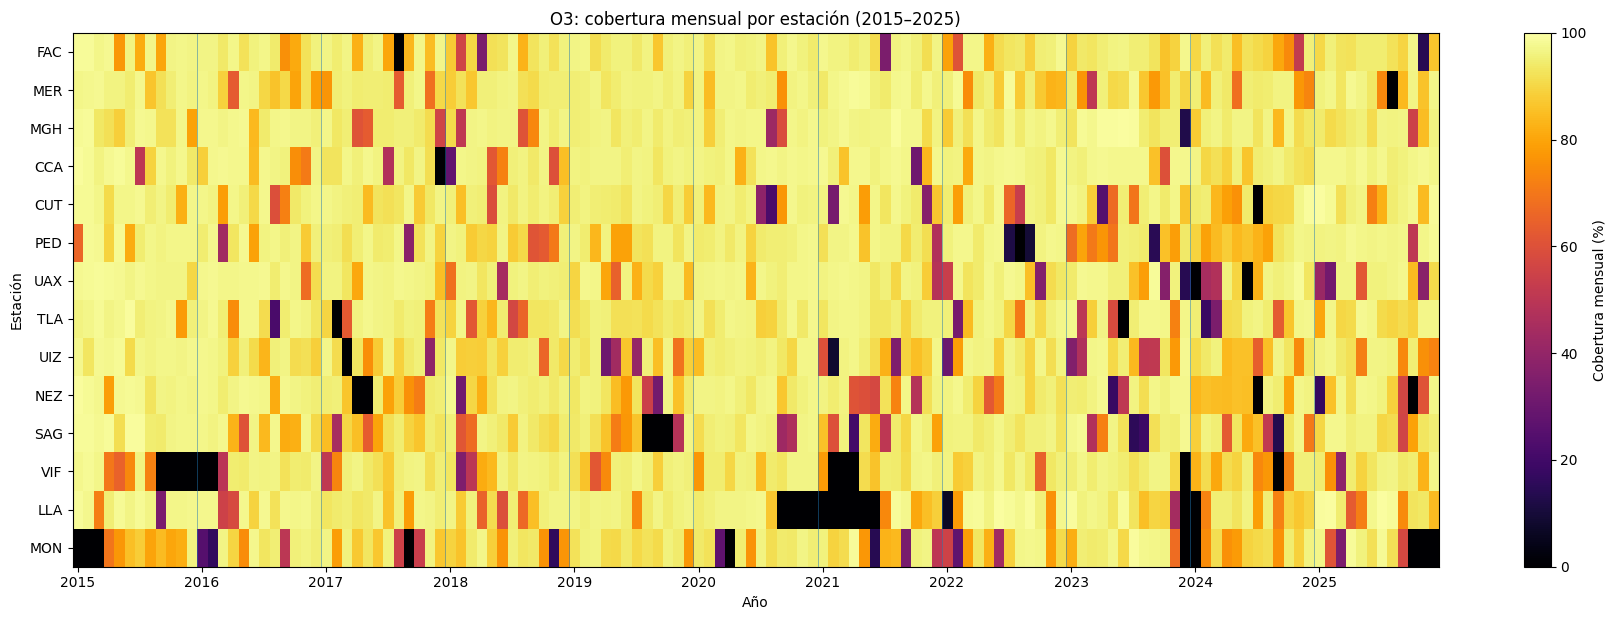

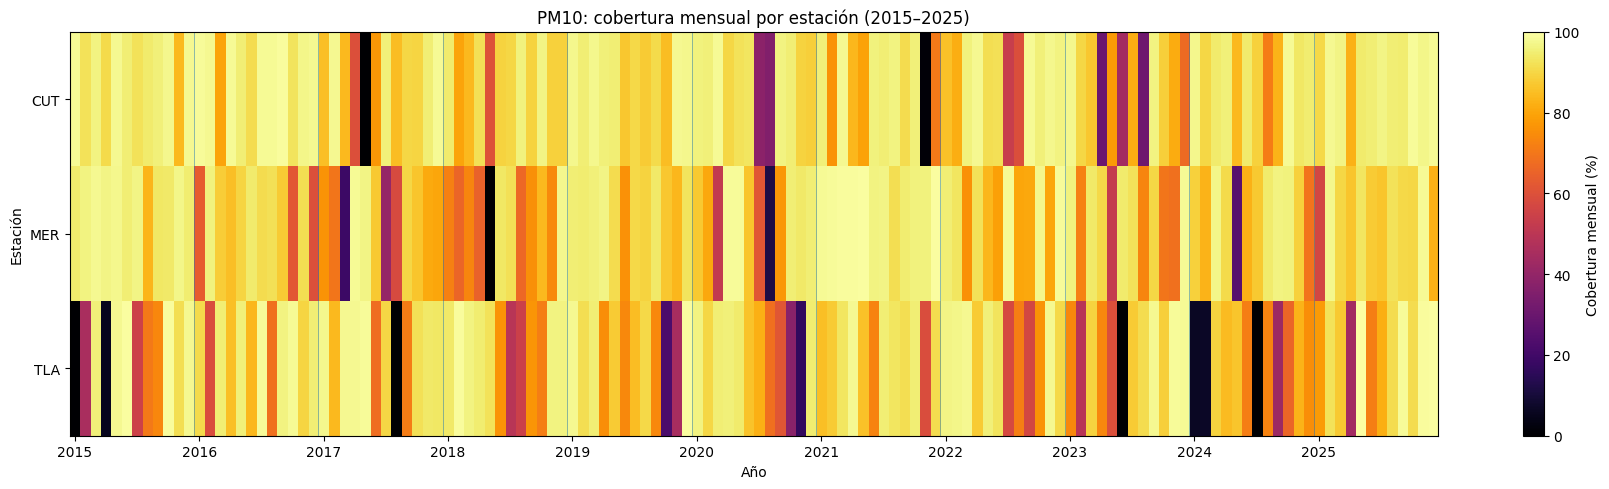

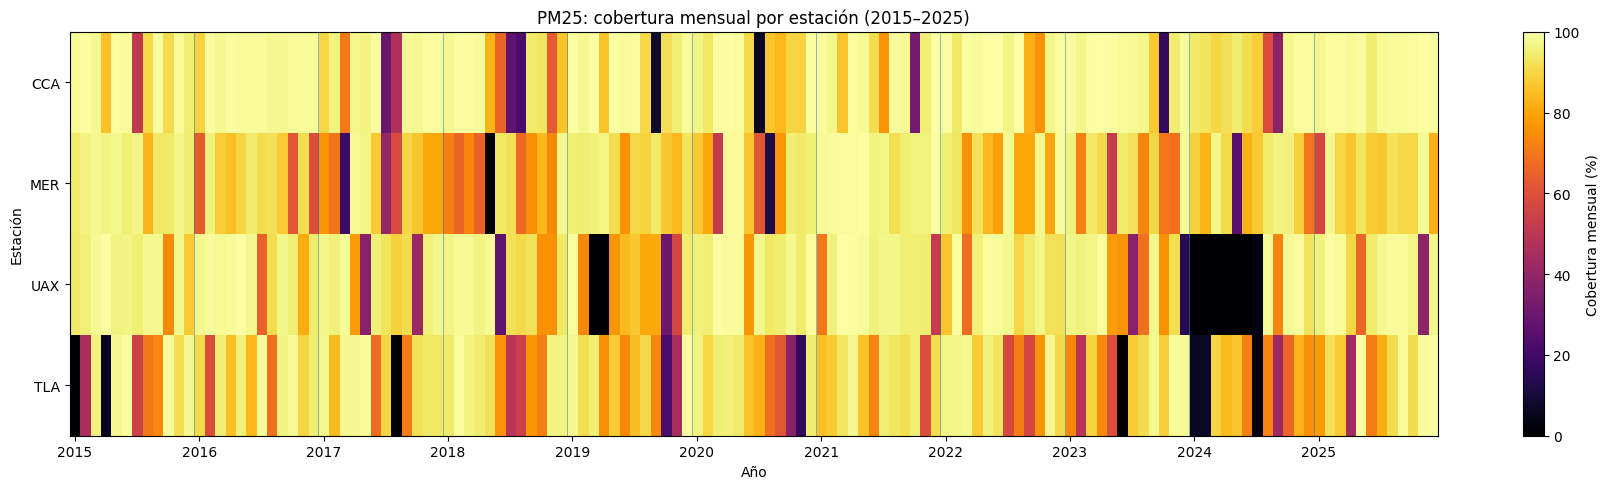

In [15]:
# MAPAS DE CALOR DE LA COBERTURA MENSUAL


# Crear una etiqueta temporal YYYY-MM

cobertura_mensual["FECHA_MES"] = pd.to_datetime(
    dict(
        year=cobertura_mensual["ANIO"],
        month=cobertura_mensual["MES"],
        day=1
    )
)


for contaminante in CONTAMINANTES_OBJETIVO:

    # Orden de estaciones: utilizar el ranking de estabilidad mensual

    orden_estaciones = (
        resumen_mensual.loc[
            resumen_mensual["CONTAMINANTE"]
            == contaminante
        ]
        .sort_values(
            [
                "PCT_MESES_GE_75",
                "MESES_SIN_DATOS",
                "COBERTURA_MENSUAL_MEDIANA"
            ],
            ascending=[
                False,
                True,
                False
            ]
        )["ESTACION"]
        .tolist()
    )

    # Matriz estación × mes

    matriz = (
        cobertura_mensual.loc[
            cobertura_mensual["CONTAMINANTE"]
            == contaminante
        ]
        .pivot(
            index="ESTACION",
            columns="FECHA_MES",
            values="COBERTURA_MENSUAL_PCT"
        )
        .reindex(
            orden_estaciones
        )
    )


    fig, ax = plt.subplots(
        figsize=(18, max(5, 0.45 * len(matriz)))
    )

    imagen = ax.imshow(
        matriz.values,
        cmap='inferno',
        aspect="auto",
        vmin=0,
        vmax=100
    )

    ax.set_yticks(
        range(len(matriz.index))
    )

    ax.set_yticklabels(
        matriz.index
    )


    fechas = matriz.columns

    posiciones_anios = [
        i
        for i, fecha in enumerate(fechas)
        if fecha.month == 1
    ]

    etiquetas_anios = [
        fechas[i].year
        for i in posiciones_anios
    ]

    ax.set_xticks(
        posiciones_anios
    )

    ax.set_xticklabels(
        etiquetas_anios
    )

    # Líneas verticales para separar años
    for posicion in posiciones_anios[1:]:
        ax.axvline(
            posicion - 0.5,
            linewidth=0.7,
            alpha=0.5
        )


    ax.set_title(
        f"{contaminante}: cobertura mensual por estación (2015–2025)"
    )

    ax.set_xlabel(
        "Año"
    )

    ax.set_ylabel(
        "Estación"
    )

    barra = fig.colorbar(
        imagen,
        ax=ax
    )

    barra.set_label(
        "Cobertura mensual (%)"
    )

    plt.tight_layout()
    plt.show()

Las gráficas confirman lo que sugerían las tablas:

- En $O_3$, **FAC, MER, MGH y CCA** muestran una continuidad especialmente buena; CUT, TLA y UIZ también conservan una estructura bastante aprovechable. En cambio, VIF, LLA y MON presentan bloques oscuros prolongados que difícilmente pueden considerarse simples faltantes aislados.

- Para PM10, **CUT y MER** son claramente las estaciones más consistentes. TLA conserva información durante todo el periodo, pero presenta más meses problemáticos y una degradación especialmente visible alrededor de 2024.

- Para PM2.5, **CCA y MER** son las estaciones más estables. El caso de UAX es especialmente ilustrativo: visualmente aparece el gran bloque sin información durante 2024 que ya habíamos cuantificado en aproximadamente (238) días. TLA, por su parte, presenta problemas distribuidos en varios años.

Todavía no elegimos la red definitiva usando umbrales elegidos a mano. El siguiente paso será integrar en una sola tabla los tres niveles de evidencia ya calculamos:

$$
\text{cobertura anual}
+
\text{cobertura mensual}
+
\text{rachas de faltantes}.
$$

Así podremos plantear después un criterio de selección transparente y hacer un análisis de sensibilidad.

## 5.8. Integración de los indicadores de estabilidad temporal

Hasta este punto se han estudiado tres dimensiones complementarias de la
disponibilidad de datos:

1. **continuidad anual**, mediante indicadores como

$$
N_{\geq75}
$$

y la cobertura mediana anual;

2. **continuidad mensual**, mediante la proporción de meses con cobertura
mayor o igual al $75\%$;

3. **estructura de los faltantes**, mediante la duración máxima de las rachas
consecutivas sin información.

Cada indicador describe una característica diferente.

Por ejemplo, una estación puede presentar una cobertura mediana anual elevada,
pero contener un bloque continuo de varios meses sin mediciones. De manera
análoga, otra estación puede presentar muchos faltantes pequeños sin llegar a
tener una interrupción prolongada.

Por ello, antes de establecer una red definitiva de estaciones se construirá
una tabla integrada con los principales indicadores:

$$
\left(
N_{\geq75},
\widetilde{C}_{\mathrm{anual}},
C_{\mathrm{global}},
P_{\mathrm{meses}\geq75},
N_{\mathrm{meses}=0},
L_{\max}
\right),
$$

donde:

- $N_{\geq75}$ es el número de años con cobertura anual de al menos $75\%$;
- $\widetilde{C}_{\mathrm{anual}}$ es la cobertura anual mediana;
- $C_{\mathrm{global}}$ es la cobertura horaria global durante 2015–2025;
- $P_{\mathrm{meses}\geq75}$ es el porcentaje de meses con cobertura de al menos $75\%$;
- $N_{\mathrm{meses}=0}$ es el número de meses completamente sin datos;
- $L_{\max}$ es la duración máxima de una racha consecutiva sin información.

El objetivo de esta tabla no será crear todavía un puntaje artificial ni elegir
automáticamente las estaciones.

Se utilizará para comparar de manera conjunta:

$$
\text{cantidad de información}
\qquad+\qquad
\text{continuidad}
\qquad+\qquad
\text{estabilidad temporal}.
$$

A partir de esta evidencia se podrá evaluar posteriormente la sensibilidad de la selección frente a distintos criterios razonables.

In [16]:
# TABLA INTEGRADA DE ESTABILIDAD TEMPORAL

# Indicadores longitudinales
indicadores_anuales = (
    candidatas_longitudinales[
        [
            "CONTAMINANTE",
            "ESTACION",
            "ANIOS_CON_DATOS",
            "ANIOS_GE_75",
            "ANIOS_GE_90",
            "COBERTURA_MEDIA",
            "COBERTURA_MEDIANA",
            "COBERTURA_MIN"
        ]
    ]
    .copy()
)


# Indicadores mensuales

indicadores_mensuales = (
    resumen_mensual[
        [
            "CONTAMINANTE",
            "ESTACION",
            "PCT_MESES_GE_75",
            "MESES_LT_50",
            "MESES_SIN_DATOS",
            "COBERTURA_MENSUAL_MEDIANA"
        ]
    ]
    .copy()
)


# Indicadores de rachas

indicadores_rachas = (
    resumen_rachas[
        [
            "CONTAMINANTE",
            "ESTACION",
            "COBERTURA_GLOBAL_PCT",
            "MAX_RACHA_FALTANTE_H",
            "MAX_RACHA_FALTANTE_DIAS",
            "RACHAS_GE_24H",
            "RACHAS_GE_72H",
            "RACHAS_GE_168H"
        ]
    ]
    .copy()
)


# Integración de las tres fuentes de información

estabilidad_integrada = (
    indicadores_anuales
    .merge(
        indicadores_mensuales,
        on=[
            "CONTAMINANTE",
            "ESTACION"
        ],
        how="left"
    )
    .merge(
        indicadores_rachas,
        on=[
            "CONTAMINANTE",
            "ESTACION"
        ],
        how="left"
    )
)


# Orden preliminar únicamente para facilitar inspección

estabilidad_integrada = (
    estabilidad_integrada
    .sort_values(
        [
            "CONTAMINANTE",
            "PCT_MESES_GE_75",
            "MAX_RACHA_FALTANTE_DIAS",
            "COBERTURA_GLOBAL_PCT"
        ],
        ascending=[
            True,
            False,
            True,
            False
        ]
    )
    .reset_index(drop=True)
)


# Mostrar indicadores principales

columnas_mostrar = [
    "ESTACION",
    "ANIOS_GE_75",
    "COBERTURA_MEDIANA",
    "COBERTURA_GLOBAL_PCT",
    "PCT_MESES_GE_75",
    "MESES_LT_50",
    "MESES_SIN_DATOS",
    "MAX_RACHA_FALTANTE_DIAS"
]


for contaminante in CONTAMINANTES_OBJETIVO:

    print(
        "\n"
        + "=" * 70
    )

    print(
        f"{contaminante}: indicadores integrados "
        "de estabilidad temporal"
    )

    print(
        "=" * 70
    )

    tabla = (
        estabilidad_integrada.loc[
            estabilidad_integrada[
                "CONTAMINANTE"
            ] == contaminante,
            columnas_mostrar
        ]
        .reset_index(drop=True)
    )

    display(tabla)


O3: indicadores integrados de estabilidad temporal


,ESTACION,ANIOS_GE_75,COBERTURA_MEDIANA,COBERTURA_GLOBAL_PCT,PCT_MESES_GE_75,MESES_LT_50,MESES_SIN_DATOS,MAX_RACHA_FALTANTE_DIAS
0,FAC,11,90.19,89.86,93.9,4,1,40.5
1,MER,11,90.01,90.83,93.2,1,1,42.5
2,MGH,11,93.50,91.92,92.4,2,0,28.5
3,CCA,11,92.96,91.59,92.4,4,1,54.5
4,CUT,11,89.25,88.77,89.4,6,1,42.7
5,PED,10,89.77,87.79,88.6,7,1,85.0
6,TLA,11,87.74,88.36,87.1,6,2,43.5
7,UAX,10,89.13,87.76,87.1,12,2,72.8
8,UIZ,11,87.69,86.02,84.8,10,1,37.6
9,NEZ,9,85.72,85.59,84.8,9,4,64.1



PM10: indicadores integrados de estabilidad temporal


,ESTACION,ANIOS_GE_75,COBERTURA_MEDIANA,COBERTURA_GLOBAL_PCT,PCT_MESES_GE_75,MESES_LT_50,MESES_SIN_DATOS,MAX_RACHA_FALTANTE_DIAS
0,CUT,10,87.47,87.31,89.4,7,1,38.6
1,MER,9,83.19,84.55,81.1,5,1,42.0
2,TLA,9,82.01,79.00,68.9,16,4,55.8



PM25: indicadores integrados de estabilidad temporal


,ESTACION,ANIOS_GE_75,COBERTURA_MEDIANA,COBERTURA_GLOBAL_PCT,PCT_MESES_GE_75,MESES_LT_50,MESES_SIN_DATOS,MAX_RACHA_FALTANTE_DIAS
0,CCA,11,89.20,89.68,89.4,9,0,46.1
1,MER,9,83.19,84.55,81.1,5,1,42.0
2,UAX,9,89.32,82.27,80.3,16,8,238.3
3,TLA,9,82.01,79.00,68.9,16,4,55.8


Estas tablas muestran una jerarquía clara, pero hay un punto metodológico importante: no conviene convertir inmediatamente esa jerarquía en una selección definitiva. Si escogemos, por ejemplo, “máximo 60 días de hueco” sin estudiar qué ocurre al mover ese límite, el criterio sería difícil de justificar.

Tenemos que hacer un análisis de sensibilidad de la selección temporal. Definiremos tres escenarios, desde el filtro longitudinal inicial hasta un núcleo más exigente. No pretendemos demostrar que uno sea “el correcto”, sino identificar estaciones que sobreviven a cambios razonables en los criterios.

## 5.9. Sensibilidad de la selección frente a los criterios de estabilidad

Los indicadores integrados permiten comparar simultáneamente la cobertura anual,
la continuidad mensual y la duración de las interrupciones.

Sin embargo, no existe un único umbral natural que permita declarar
automáticamente que una estación es adecuada o inadecuada.

Por ejemplo, podría exigirse que la racha máxima sin datos sea menor que $60$ días, pero también sería razonable explorar límites de $90$ días.

De manera análoga, la proporción mínima de meses con cobertura suficiente podría establecerse en $80\%$ o en $85\%$.

Para evitar que la selección dependa de una única combinación arbitraria de umbrales, se realizará un **análisis de sensibilidad** mediante tres escenarios.

### Escenario A: preselección longitudinal

Corresponde al criterio utilizado hasta ahora:

$$
N_{\geq75}\geq9.
$$

Todas las estaciones analizadas en esta sección cumplen además con datos válidos
en los once años.

Este escenario representa la red candidata más amplia.


### Escenario B: estabilidad temporal moderada

Además de la condición anterior, se exigirá:

$$
P_{\mathrm{meses}\geq75}\geq80\%,
$$

$$
N_{\mathrm{meses}=0}\leq2,
$$

y

$$
L_{\max}\leq90\text{ días}.
$$

Este escenario permite interrupciones ocasionales, pero elimina estaciones con
bloques extremadamente largos o con demasiados meses completamente ausentes.


### Escenario C: núcleo temporal robusto

Se utilizará un criterio más exigente:

$$
N_{\geq75}\geq10,
$$

$$
P_{\mathrm{meses}\geq75}\geq85\%,
$$

$$
N_{\mathrm{meses}=0}\leq1,
$$

y

$$
L_{\max}\leq60\text{ días}.
$$

Este escenario pretende identificar estaciones con una trayectoria temporal
especialmente estable.



### Interpretación

Los tres escenarios no deben interpretarse como tres modelos diferentes ni como
una selección definitiva.

Su finalidad es determinar qué estaciones son **robustas frente a cambios
razonables en los criterios de cobertura**.

Una estación que permanece seleccionada bajo los escenarios B y C constituye un
candidato temporal particularmente fuerte.

En cambio, una estación que solamente aparece en el escenario A puede seguir
siendo útil, pero requerirá una justificación adicional.

Finalmente, la decisión sobre la red de estaciones no dependerá exclusivamente
de la continuidad temporal. También deberá considerarse posteriormente su
**representatividad espacial**, ya que para estudiar contingencias atmosféricas
no sería adecuado conservar únicamente estaciones muy completas si todas
representaran una zona geográfica similar.

In [17]:
# ANÁLISIS DE SENSIBILIDAD DE LA SELECCIÓN TEMPORAL

sensibilidad_estaciones = (
    estabilidad_integrada
    .copy()
)

# ESCENARIO A: Preselección longitudinal original

sensibilidad_estaciones["ESCENARIO_A"] = (
    sensibilidad_estaciones["ANIOS_GE_75"] >= 9
)

# ESCENARIO B: Estabilidad temporal moderada

sensibilidad_estaciones["ESCENARIO_B"] = (
    (sensibilidad_estaciones["ANIOS_GE_75"] >= 9)
    &
    (sensibilidad_estaciones["PCT_MESES_GE_75"] >= 80)
    &
    (sensibilidad_estaciones["MESES_SIN_DATOS"] <= 2)
    &
    (
        sensibilidad_estaciones[
            "MAX_RACHA_FALTANTE_DIAS"
        ] <= 90
    )
)


# ESCENARIO C: Núcleo temporal robusto

sensibilidad_estaciones["ESCENARIO_C"] = (
    (sensibilidad_estaciones["ANIOS_GE_75"] >= 10)
    &
    (sensibilidad_estaciones["PCT_MESES_GE_75"] >= 85)
    &
    (sensibilidad_estaciones["MESES_SIN_DATOS"] <= 1)
    &
    (
        sensibilidad_estaciones[
            "MAX_RACHA_FALTANTE_DIAS"
        ] <= 60
    )
)


# RESUMEN DE NÚMERO DE ESTACIONES

resumen_sensibilidad = (
    sensibilidad_estaciones
    .groupby("CONTAMINANTE")
    [
        [
            "ESCENARIO_A",
            "ESCENARIO_B",
            "ESCENARIO_C"
        ]
    ]
    .sum()
    .astype(int)
    .reindex(
        CONTAMINANTES_OBJETIVO
    )
)

print(
    "Número de estaciones seleccionadas "
    "bajo cada escenario:"
)

display(
    resumen_sensibilidad
)


# DETALLE POR CONTAMINANTE

for contaminante in CONTAMINANTES_OBJETIVO:

    print(
        "\n"
        + "=" * 70
    )

    print(
        f"{contaminante}: sensibilidad de la selección"
    )

    print(
        "=" * 70
    )

    tabla = (
        sensibilidad_estaciones.loc[
            sensibilidad_estaciones[
                "CONTAMINANTE"
            ] == contaminante,
            [
                "ESTACION",
                "ANIOS_GE_75",
                "PCT_MESES_GE_75",
                "MESES_SIN_DATOS",
                "MAX_RACHA_FALTANTE_DIAS",
                "ESCENARIO_A",
                "ESCENARIO_B",
                "ESCENARIO_C"
            ]
        ]
        .sort_values(
            [
                "ESCENARIO_C",
                "ESCENARIO_B",
                "PCT_MESES_GE_75"
            ],
            ascending=[
                False,
                False,
                False
            ]
        )
        .reset_index(drop=True)
    )

    display(
        tabla
    )


# ESTACIONES DEL NÚCLEO ROBUSTO

print(
    "\nEstaciones que forman el núcleo "
    "temporal robusto (Escenario C):"
)

for contaminante in CONTAMINANTES_OBJETIVO:

    estaciones_nucleo = (
        sensibilidad_estaciones.loc[
            (
                sensibilidad_estaciones[
                    "CONTAMINANTE"
                ] == contaminante
            )
            &
            (
                sensibilidad_estaciones[
                    "ESCENARIO_C"
                ]
            ),
            "ESTACION"
        ]
        .tolist()
    )

    print(
        f"{contaminante}: {estaciones_nucleo}"
    )

Número de estaciones seleccionadas bajo cada escenario:


,ESCENARIO_A,ESCENARIO_B,ESCENARIO_C
CONTAMINANTE,,,
O3,14,9,5
PM10,3,2,1
PM25,4,2,1



O3: sensibilidad de la selección


,ESTACION,ANIOS_GE_75,PCT_MESES_GE_75,MESES_SIN_DATOS,MAX_RACHA_FALTANTE_DIAS,ESCENARIO_A,ESCENARIO_B,ESCENARIO_C
0,FAC,11,93.9,1,40.5,True,True,True
1,MER,11,93.2,1,42.5,True,True,True
2,MGH,11,92.4,0,28.5,True,True,True
3,CCA,11,92.4,1,54.5,True,True,True
4,CUT,11,89.4,1,42.7,True,True,True
5,PED,10,88.6,1,85.0,True,True,False
6,TLA,11,87.1,2,43.5,True,True,False
7,UAX,10,87.1,2,72.8,True,True,False
8,UIZ,11,84.8,1,37.6,True,True,False
9,NEZ,9,84.8,4,64.1,True,False,False



PM10: sensibilidad de la selección


,ESTACION,ANIOS_GE_75,PCT_MESES_GE_75,MESES_SIN_DATOS,MAX_RACHA_FALTANTE_DIAS,ESCENARIO_A,ESCENARIO_B,ESCENARIO_C
0,CUT,10,89.4,1,38.6,True,True,True
1,MER,9,81.1,1,42.0,True,True,False
2,TLA,9,68.9,4,55.8,True,False,False



PM25: sensibilidad de la selección


,ESTACION,ANIOS_GE_75,PCT_MESES_GE_75,MESES_SIN_DATOS,MAX_RACHA_FALTANTE_DIAS,ESCENARIO_A,ESCENARIO_B,ESCENARIO_C
0,CCA,11,89.4,0,46.1,True,True,True
1,MER,9,81.1,1,42.0,True,True,False
2,UAX,9,80.3,8,238.3,True,False,False
3,TLA,9,68.9,4,55.8,True,False,False



Estaciones que forman el núcleo temporal robusto (Escenario C):
O3: ['FAC', 'MER', 'MGH', 'CCA', 'CUT']
PM10: ['CUT']
PM25: ['CCA']


Este resultado es muy útil porque muestra algo que debemos cuidar metodológicamente: el Escenario C no debe convertirse automáticamente en nuestra red final. Para $O_3$ todavía deja cinco estaciones, pero para PM10 y PM2.5 deja sólo una:

$$
S_{PM10}^{(C)}={\mathrm{CUT}},
\qquad
S_{PM2.5}^{(C)}={\mathrm{CCA}}.
$$

Eso sería temporalmente muy limpio, pero probablemente demasiado restrictivo espacialmente para estudiar contingencias en la ZMVM.

Por ahora considero más razonable conservar el Escenario B como red candidata principal:

$$
9\text{ estaciones de }O_3,\qquad
2\text{ de PM}_{10},\qquad
2\text{ de PM}_{2.5},
$$

y mantener el Escenario A como conjunto ampliado de respaldo. Antes de decidir, necesitamos saber qué estaciones coinciden entre contaminantes y qué tan dependiente sería el estudio de unas pocas estaciones. 

## 5.10. Redes candidatas por contaminante y coincidencia entre ellas

El análisis de sensibilidad mostró que aumentar la exigencia temporal reduce
considerablemente el número de estaciones disponibles.

En particular, el escenario más estricto produce

$$
|S_{O_3}^{(C)}|=5,
\qquad
|S_{PM_{10}}^{(C)}|=1,
\qquad
|S_{PM_{2.5}}^{(C)}|=1.
$$

Aunque estas estaciones presentan una elevada estabilidad temporal, seleccionar
la red únicamente con este criterio podría producir una representación espacial
demasiado limitada.

Esto es especialmente importante porque una contingencia atmosférica es un
fenómeno que se evalúa a partir de una **red de monitoreo**, no de una única serie
temporal.

Por esta razón, en esta etapa se distinguirán tres niveles de estaciones:

- **Red ampliada**: estaciones del Escenario A;
- **Red candidata principal**: estaciones del Escenario B;
- **Núcleo temporal robusto**: estaciones del Escenario C.

La red candidata principal se utilizará como punto de partida para el análisis
espacial posterior, mientras que el núcleo robusto permitirá identificar las
estaciones con mayor continuidad temporal dentro de ella.

También se estudiará la coincidencia de estaciones entre contaminantes.

Para dos contaminantes $c_1$ y $c_2$, la intersección

$$
S_{c_1}\cap S_{c_2}
$$

representa las estaciones capaces de proporcionar información para ambos
contaminantes dentro del mismo escenario de selección.

Estas intersecciones son útiles porque una estación común puede permitir
posteriormente estudiar conjuntamente distintos componentes de la contaminación.

Sin embargo, **no se exigirá que las estaciones sean comunes a los tres
contaminantes**.

El objetivo continúa siendo mantener redes específicas:

$$
S_{O_3},
\qquad
S_{PM_{10}},
\qquad
S_{PM_{2.5}}.
$$

En esta etapa se analizará únicamente la composición de estas redes. La
representatividad geográfica se estudiará después mediante la localización de las
estaciones.

In [18]:
# REDES CANDIDATAS Y COINCIDENCIA ENTRE CONTAMINANTES

redes = {}

for escenario in [
    "ESCENARIO_A",
    "ESCENARIO_B",
    "ESCENARIO_C"
]:

    redes[escenario] = {}

    for contaminante in CONTAMINANTES_OBJETIVO:

        estaciones = sorted(
            sensibilidad_estaciones.loc[
                (
                    sensibilidad_estaciones[
                        "CONTAMINANTE"
                    ] == contaminante
                )
                &
                (
                    sensibilidad_estaciones[
                        escenario
                    ]
                ),
                "ESTACION"
            ]
            .tolist()
        )

        redes[escenario][
            contaminante
        ] = estaciones


# MOSTRAR REDES

for escenario in [
    "ESCENARIO_A",
    "ESCENARIO_B",
    "ESCENARIO_C"
]:

    print(
        "\n"
        + "=" * 50
    )

    print(
        escenario
    )

    print(
        "=" * 50
    )

    for contaminante in CONTAMINANTES_OBJETIVO:

        estaciones = (
            redes[
                escenario
            ][
                contaminante
            ]
        )

        print(
            f"{contaminante}: "
            f"{len(estaciones)} estaciones"
        )

        print(
            estaciones
        )


# INTERSECCIONES EN EL ESCENARIO B

o3_b = set(
    redes["ESCENARIO_B"]["O3"]
)

pm10_b = set(
    redes["ESCENARIO_B"]["PM10"]
)

pm25_b = set(
    redes["ESCENARIO_B"]["PM25"]
)


print(
    "\n"
    + "=" * 70
)

print(
    "Coincidencia entre contaminantes "
    "- Escenario B"
)

print(
    "=" * 70
)


print(
    "\nO3 ∩ PM10:"
)

print(
    sorted(
        o3_b & pm10_b
    )
)


print(
    "\nO3 ∩ PM25:"
)

print(
    sorted(
        o3_b & pm25_b
    )
)


print(
    "\nPM10 ∩ PM25:"
)

print(
    sorted(
        pm10_b & pm25_b
    )
)


print(
    "\nO3 ∩ PM10 ∩ PM25:"
)

print(
    sorted(
        o3_b
        & pm10_b
        & pm25_b
    )
)


# UNIÓN DE ESTACIONES DEL ESCENARIO B

union_b = sorted(
    o3_b
    | pm10_b
    | pm25_b
)

print(
    "\nNúmero total de estaciones distintas "
    "en la red candidata B:",
    len(union_b)
)

print(
    union_b
)


ESCENARIO_A
O3: 14 estaciones
['CCA', 'CUT', 'FAC', 'LLA', 'MER', 'MGH', 'MON', 'NEZ', 'PED', 'SAG', 'TLA', 'UAX', 'UIZ', 'VIF']
PM10: 3 estaciones
['CUT', 'MER', 'TLA']
PM25: 4 estaciones
['CCA', 'MER', 'TLA', 'UAX']

ESCENARIO_B
O3: 9 estaciones
['CCA', 'CUT', 'FAC', 'MER', 'MGH', 'PED', 'TLA', 'UAX', 'UIZ']
PM10: 2 estaciones
['CUT', 'MER']
PM25: 2 estaciones
['CCA', 'MER']

ESCENARIO_C
O3: 5 estaciones
['CCA', 'CUT', 'FAC', 'MER', 'MGH']
PM10: 1 estaciones
['CUT']
PM25: 1 estaciones
['CCA']

Coincidencia entre contaminantes - Escenario B

O3 ∩ PM10:
['CUT', 'MER']

O3 ∩ PM25:
['CCA', 'MER']

PM10 ∩ PM25:
['MER']

O3 ∩ PM10 ∩ PM25:
['MER']

Número total de estaciones distintas en la red candidata B: 9
['CCA', 'CUT', 'FAC', 'MER', 'MGH', 'PED', 'TLA', 'UAX', 'UIZ']


La salida confirma muy bien la lógica del enfoque. En el Escenario B tenemos una red física de 9 estaciones distintas, pero cada contaminante utiliza su propio subconjunto:

$$
S_{O_3}^{(B)}={\text{CCA,CUT,FAC,MER,MGH,PED,TLA,UAX,UIZ}},
$$

$$
S_{PM10}^{(B)}={\text{CUT,MER}},
$$

$$
S_{PM2.5}^{(B)}={\text{CCA,MER}}.
$$

Además,

$$
S_{O_3}^{(B)} \cap S_{PM10}^{(B)} \cap S_{PM2.5}^{(B)}={\text{MER}}.
$$



## 5.11. Composición de la red candidata principal

El Escenario B identifica una red candidata formada por nueve estaciones
distintas, pero no todas ellas participan en los tres problemas de predicción.

Para representar esta estructura se construirá una matriz de pertenencia

$$
R_{s,c}
=
\begin{cases}
1, & \text{si la estación }s\text{ pertenece a la red candidata del contaminante }c,\\
0, & \text{en otro caso}.
\end{cases}
$$

Las columnas corresponderán a

$$
O_3,\qquad PM_{10},\qquad PM_{2.5},
$$

y las filas a las estaciones que aparecen en al menos una de las redes del
Escenario B.

Esta representación permitirá distinguir:

- estaciones utilizadas únicamente para $O_3$;
- estaciones compartidas entre $O_3$ y partículas;
- estaciones disponibles para más de un tipo de partícula;
- estaciones comunes a los tres contaminantes.

Es importante subrayar que una estación común a varios contaminantes puede ser
especialmente útil para estudiar relaciones multivariadas, pero no tendrá
prioridad automática sobre estaciones específicas de un contaminante.

En particular,

$$
\text{pertenecer a más redes}
\not\Rightarrow
\text{ser más representativa espacialmente}.
$$

Por ello, la matriz de pertenencia se utilizará únicamente para describir la
estructura de la red candidata.

El siguiente paso será incorporar la ubicación geográfica de estas estaciones
para evaluar si el conjunto seleccionado proporciona una cobertura espacial
razonable de la zona de estudio.

In [19]:
# MATRIZ DE PERTENENCIA DE LA RED CANDIDATA B


# Estaciones distintas de la red candidata

estaciones_red_b = sorted(
    set(
        redes["ESCENARIO_B"]["O3"]
    )
    |
    set(
        redes["ESCENARIO_B"]["PM10"]
    )
    |
    set(
        redes["ESCENARIO_B"]["PM25"]
    )
)


# Construir matriz estación × contaminante

matriz_red_b = pd.DataFrame(
    index=estaciones_red_b
)

for contaminante in CONTAMINANTES_OBJETIVO:

    estaciones_contaminante = set(
        redes["ESCENARIO_B"][
            contaminante
        ]
    )

    matriz_red_b[
        contaminante
    ] = [
        estacion in estaciones_contaminante
        for estacion in estaciones_red_b
    ]


# Número de contaminantes objetivo disponibles

matriz_red_b[
    "N_CONTAMINANTES_OBJETIVO"
] = (
    matriz_red_b[
        CONTAMINANTES_OBJETIVO
    ]
    .sum(axis=1)
)


# Descripción del papel de cada estación

def describir_contaminantes(fila):

    disponibles = [
        contaminante
        for contaminante in CONTAMINANTES_OBJETIVO
        if fila[contaminante]
    ]

    return ", ".join(
        disponibles
    )


matriz_red_b[
    "CONTAMINANTES"
] = (
    matriz_red_b.apply(
        describir_contaminantes,
        axis=1
    )
)


# Ordenar primero las estaciones con mayor coincidencia

matriz_red_b = (
    matriz_red_b
    .sort_values(
        [
            "N_CONTAMINANTES_OBJETIVO"
        ],
        ascending=False
    )
)


print(
    "Composición de la red candidata principal "
    "(Escenario B):"
)

display(
    matriz_red_b
)


# Resumen

print(
    "\nNúmero total de estaciones distintas:",
    len(matriz_red_b)
)

print(
    "\nDistribución según número de contaminantes objetivo:"
)

display(
    matriz_red_b[
        "N_CONTAMINANTES_OBJETIVO"
    ]
    .value_counts()
    .sort_index()
    .rename_axis(
        "N_CONTAMINANTES"
    )
    .rename(
        "N_ESTACIONES"
    )
    .to_frame()
)

Composición de la red candidata principal (Escenario B):


,O3,PM10,PM25,N_CONTAMINANTES_OBJETIVO,CONTAMINANTES
MER,True,True,True,3,"O3, PM10, PM25"
CCA,True,False,True,2,"O3, PM25"
CUT,True,True,False,2,"O3, PM10"
FAC,True,False,False,1,O3
MGH,True,False,False,1,O3
PED,True,False,False,1,O3
TLA,True,False,False,1,O3
UAX,True,False,False,1,O3
UIZ,True,False,False,1,O3



Número total de estaciones distintas: 9

Distribución según número de contaminantes objetivo:


,N_ESTACIONES
N_CONTAMINANTES,
1,6
2,2
3,1


La salida confirma que el enfoque independiente por contaminante está funcionando bien. En particular, MER es la única estación que aparece en los tres conjuntos del Escenario B, pero eso no significa que deba convertirse en la estación representativa de todo el proyecto.

Antes de pasar al componente espacial, haremos un diagnóstico adicional: **¿qué tan bien se complementan temporalmente las estaciones del Escenario B dentro de cada contaminante?**

Esto es especialmente relevante para partículas, porque sólo tenemos dos estaciones candidatas:

$$
PM_{10}:{\mathrm{CUT},\mathrm{MER}},
\qquad
PM_{2.5}:{\mathrm{CCA},\mathrm{MER}}.
$$

Queremos saber si sus faltantes ocurren simultáneamente o si una estación suele cubrir los huecos de la otra.

## 5.12. Complementariedad temporal de las redes candidatas

Hasta ahora la calidad temporal se ha evaluado estación por estación.

Sin embargo, el problema de contingencias atmosféricas se estudiará utilizando
una **red de estaciones**, por lo que también es necesario evaluar la
disponibilidad conjunta del sistema de monitoreo seleccionado.

Para cada contaminante se considerará la red candidata del Escenario B:

$$
S_c^{(B)}.
$$

En cada hora $t$ se contará el número de estaciones que presentan una medición
válida:

$$
K_{c,t}
=
\sum_{s\in S_c^{(B)}} I(V_{s,c,t}=1),
$$

donde

$$
V_{s,c,t}
=
\begin{cases}
1, & \text{si la estación }s\text{ tiene una medición válida},\\
0, & \text{en otro caso}.
\end{cases}
$$

Por tanto,

$$
0\leq K_{c,t}\leq |S_c^{(B)}|.
$$

Este indicador permitirá responder preguntas como:

- ¿qué porcentaje de las horas tiene al menos una estación disponible?;
- ¿qué porcentaje tiene al menos dos estaciones disponibles?;
- ¿con qué frecuencia queda completamente sin información la red candidata?;
- ¿cuál es la interrupción continua más larga en la que ninguna estación
  proporciona información?

La primera cantidad puede expresarse como

$$
P(K_{c,t}\geq1),
$$

mientras que la disponibilidad simultánea de al menos dos estaciones será

$$
P(K_{c,t}\geq2).
$$

Para las redes de partículas, formadas por dos estaciones, también resulta
informativo calcular

$$
P(K_{c,t}=2),
$$

es decir, la proporción del tiempo en la que ambas estaciones proporcionan
información simultáneamente.


### Por qué es importante este análisis

Dos estaciones pueden tener individualmente coberturas moderadas y, sin embargo,
formar una red temporalmente muy completa si sus periodos faltantes no
coinciden.

Por el contrario, dos estaciones con coberturas individuales elevadas pueden
aportar poca complementariedad si ambas dejan de medir durante los mismos
periodos.

Por ello,

$$
\text{calidad de cada estación}
\neq
\text{calidad temporal de la red}.
$$

La disponibilidad se calculará sobre la cuadrícula horaria teórica completa de
2015–2025, de manera que cualquier hora ausente de los archivos también sea
considerada explícitamente como información faltante.

Esta etapa continúa siendo un diagnóstico de cobertura. Todavía no se
construirán índices de contaminación ni etiquetas de contingencia.

In [20]:
# COMPLEMENTARIEDAD TEMPORAL DE LAS REDES DEL ESCENARIO B

resultados_red_horaria = []
resultados_red_anual = []

series_disponibilidad_red = {}


for contaminante in CONTAMINANTES_OBJETIVO:

    estaciones = (
        redes["ESCENARIO_B"][
            contaminante
        ]
    )

    # Construir las series horarias 2015–2025
    bloques = []

    for anio in ANIOS:

        ruta = Path(
            inventario_objetivo.loc[
                (
                    inventario_objetivo["ANIO"]
                    == anio
                )
                &
                (
                    inventario_objetivo[
                        "CONTAMINANTE"
                    ]
                    == contaminante
                ),
                "RUTA"
            ].iloc[0]
        )

        df = pd.read_excel(
            ruta
        )

        fecha = pd.to_datetime(
            df["FECHA"],
            errors="coerce"
        )

        hora = pd.to_numeric(
            df["HORA"],
            errors="coerce"
        )

        timestamp = (
            fecha
            + pd.to_timedelta(
                hora - 1,
                unit="h"
            )
        )

        bloque = pd.DataFrame(
            index=timestamp
        )

        for estacion in estaciones:

            if estacion in df.columns:

                serie = pd.to_numeric(
                    df[estacion],
                    errors="coerce"
                )

                bloque[estacion] = (
                    serie.to_numpy()
                )

            else:

                bloque[estacion] = np.nan

        bloques.append(
            bloque
        )

    datos_red = pd.concat(
        bloques
    )

    # Reindexar contra TODAS las horas teóricas
    datos_red = (
        datos_red
        .reindex(
            indice_horario_completo
        )
    )

    # Matriz booleana de disponibilidad
    validas = (
        datos_red.notna()
        & (datos_red != -99)
    )

    # Número de estaciones disponibles cada hora
    k_disponibles = (
        validas.sum(axis=1)
    )

    series_disponibilidad_red[
        contaminante
    ] = k_disponibles


    # Rachas con CERO estaciones disponibles

    hay_alguna = (
        k_disponibles >= 1
    )

    rachas_cero = (
        longitudes_rachas_faltantes(
            hay_alguna
        )
    )

    max_racha_cero_h = (
        int(rachas_cero.max())
        if len(rachas_cero) > 0
        else 0
    )


    # RESUMEN GLOBAL

    n_estaciones = len(
        estaciones
    )

    registro_global = {
        "CONTAMINANTE":
            contaminante,

        "N_ESTACIONES":
            n_estaciones,

        "PCT_HORAS_CERO":
            100 * (k_disponibles == 0).mean(),

        "PCT_HORAS_GE_1":
            100 * (k_disponibles >= 1).mean(),

        "PCT_HORAS_GE_2":
            (
                100 * (k_disponibles >= 2).mean()
                if n_estaciones >= 2
                else np.nan
            ),

        "PCT_HORAS_TODAS":
            100 * (
                k_disponibles == n_estaciones
            ).mean(),

        "MAX_RACHA_CERO_H":
            max_racha_cero_h,

        "MAX_RACHA_CERO_DIAS":
            max_racha_cero_h / 24
    }

    resultados_red_horaria.append(
        registro_global
    )


    # RESUMEN POR AÑO

    for anio in ANIOS:

        mascara_anio = (
            k_disponibles.index.year
            == anio
        )

        k_anio = (
            k_disponibles.loc[
                mascara_anio
            ]
        )

        resultados_red_anual.append({
            "CONTAMINANTE":
                contaminante,

            "ANIO":
                anio,

            "PCT_HORAS_CERO":
                100 * (
                    k_anio == 0
                ).mean(),

            "PCT_HORAS_GE_1":
                100 * (
                    k_anio >= 1
                ).mean(),

            "PCT_HORAS_GE_2":
                (
                    100 * (
                        k_anio >= 2
                    ).mean()
                    if n_estaciones >= 2
                    else np.nan
                )
        })


# TABLAS FINALES

resumen_red_horaria = pd.DataFrame(
    resultados_red_horaria
)

resumen_red_anual = pd.DataFrame(
    resultados_red_anual
)


columnas_pct_global = [
    "PCT_HORAS_CERO",
    "PCT_HORAS_GE_1",
    "PCT_HORAS_GE_2",
    "PCT_HORAS_TODAS"
]

resumen_red_horaria[
    columnas_pct_global
] = (
    resumen_red_horaria[
        columnas_pct_global
    ]
    .round(2)
)

resumen_red_horaria[
    "MAX_RACHA_CERO_DIAS"
] = (
    resumen_red_horaria[
        "MAX_RACHA_CERO_DIAS"
    ]
    .round(1)
)


print(
    "Disponibilidad horaria global de "
    "las redes candidatas (Escenario B):"
)

display(resumen_red_horaria)


# Matriz anual: porcentaje de horas con al menos una estación disponible

print(
    "\nPorcentaje anual de horas con "
    "al menos una estación disponible:"
)

matriz_ge1 = (
    resumen_red_anual
    .pivot(
        index="CONTAMINANTE",
        columns="ANIO",
        values="PCT_HORAS_GE_1"
    )
    .round(2)
)

display(matriz_ge1)


# Matriz anual: porcentaje de horas con al menos dos estaciones disponibles

print(
    "\nPorcentaje anual de horas con "
    "al menos dos estaciones disponibles:"
)

matriz_ge2 = (
    resumen_red_anual
    .pivot(
        index="CONTAMINANTE",
        columns="ANIO",
        values="PCT_HORAS_GE_2"
    )
    .round(2)
)

display(matriz_ge2)

Disponibilidad horaria global de las redes candidatas (Escenario B):


,CONTAMINANTE,N_ESTACIONES,PCT_HORAS_CERO,PCT_HORAS_GE_1,PCT_HORAS_GE_2,PCT_HORAS_TODAS,MAX_RACHA_CERO_H,MAX_RACHA_CERO_DIAS
0,O3,9,1.96,98.04,97.79,42.78,6,0.2
1,PM10,2,2.80,97.20,74.66,74.66,699,29.1
2,PM25,2,2.44,97.56,76.66,76.66,703,29.3



Porcentaje anual de horas con al menos una estación disponible:


ANIO,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
CONTAMINANTE,,,,,,,,,,,
O3,98.44,97.86,97.61,97.32,97.24,97.39,98.56,98.40,98.87,97.84,98.90
PM10,99.79,98.90,96.15,94.61,99.37,91.34,99.37,98.53,95.03,97.72,98.38
PM25,99.69,99.48,88.68,95.50,99.06,95.21,99.49,99.39,98.52,98.44,99.74



Porcentaje anual de horas con al menos dos estaciones disponibles:


ANIO,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
CONTAMINANTE,,,,,,,,,,,
O3,98.44,97.86,97.61,97.32,97.24,97.39,98.05,98.06,98.05,97.48,98.18
PM10,89.42,79.59,56.94,64.43,84.27,70.64,79.45,76.40,60.22,75.91,84.01
PM25,87.13,81.48,69.53,53.41,80.33,68.99,86.76,83.78,74.63,71.02,86.21


Estos resultados muestran que la complementariedad temporal sí aporta mucho, especialmente para partículas.

Para PM10, CUT y MER individualmente tenían coberturas globales de (87.31%) y (84.55%), pero al permitir que cualquiera de las dos aporte información obtenemos

$$
P(K_{PM10,t}\geq1)=97.20%.
$$

Para PM2.5 ocurre algo similar con CCA y MER:

$$
P(K_{PM2.5,t}\geq1)=97.56%.
$$

Esto confirma que no sería conveniente quedarnos únicamente con CUT para PM10 o únicamente con CCA para PM2.5 sólo porque pertenecen al Escenario C.

También hay una advertencia importante: aunque la cobertura de red supera el (97%), tanto PM10 como PM2.5 presentan una racha de aproximadamente 29 días en la que ninguna de las dos estaciones tiene información válida. 

## 5.13. Localización de las interrupciones de la red completa

El análisis anterior mostró que las estaciones seleccionadas presentan una
complementariedad temporal importante.

Para cada contaminante, la probabilidad de disponer de al menos una estación
válida es aproximadamente

$$
P(K_{O_3,t}\geq1)=98.04\%,
$$

$$
P(K_{PM_{10},t}\geq1)=97.20\%,
$$

y

$$
P(K_{PM_{2.5},t}\geq1)=97.56\%.
$$

Sin embargo, una cobertura global elevada puede ocultar interrupciones
continuas importantes.

En particular, las redes candidatas de partículas presentan una racha máxima
con

$$
K_{c,t}=0
$$

de aproximadamente $29$ días.

Esto significa que durante ese intervalo ninguna estación de la red candidata
dispone de una observación válida para el contaminante correspondiente.

Antes de concluir que la cobertura temporal es suficiente, se localizarán
explícitamente estas interrupciones.

Para cada contaminante se identificarán las rachas consecutivas en las que

$$
K_{c,t}=0,
$$

y para cada racha se registrarán:

- instante inicial;
- instante final;
- duración en horas;
- duración aproximada en días.

Se mostrarán las interrupciones más largas de cada red.

Este diagnóstico permitirá determinar si los periodos sin información:

- se concentran en un único episodio;
- aparecen repetidamente;
- coinciden entre PM10 y PM2.5;
- afectan años que posteriormente podrían ser utilizados para entrenamiento
  o validación temporal.

Una interrupción común entre distintos contaminantes también podría sugerir
problemas operativos compartidos entre estaciones o periodos específicos de la
red de monitoreo.

Todavía no se realizará ninguna imputación ni se eliminarán periodos.

In [21]:
# LOCALIZAR LAS RACHAS CON CERO ESTACIONES DISPONIBLES

def identificar_rachas_cero(k_disponibles):
    """
    Identifica rachas consecutivas en las que ninguna
    estación de la red tiene información válida.

    k_disponibles:
        Serie temporal con el número de estaciones
        disponibles en cada hora.
    """

    mascara_cero = (
        k_disponibles == 0
    )

    # Cambios entre estado cero / no cero
    grupos = (
        mascara_cero.ne(
            mascara_cero.shift()
        )
        .cumsum()
    )

    registros = []

    for _, bloque in (
        k_disponibles[
            mascara_cero
        ]
        .groupby(
            grupos[
                mascara_cero
            ]
        )
    ):

        inicio = (
            bloque.index.min()
        )

        fin = (
            bloque.index.max()
        )

        duracion_h = (
            len(bloque)
        )

        registros.append({
            "INICIO":
                inicio,

            "FIN":
                fin,

            "DURACION_H":
                duracion_h,

            "DURACION_DIAS":
                duracion_h / 24
        })

    return pd.DataFrame(
        registros
    )


# ANALIZAR CADA CONTAMINANTE

rachas_cero_red = {}

for contaminante in CONTAMINANTES_OBJETIVO:

    k_disponibles = (
        series_disponibilidad_red[
            contaminante
        ]
    )

    tabla_rachas = (
        identificar_rachas_cero(
            k_disponibles
        )
    )

    if len(tabla_rachas) > 0:

        tabla_rachas[
            "DURACION_DIAS"
        ] = (
            tabla_rachas[
                "DURACION_DIAS"
            ]
            .round(2)
        )

        tabla_rachas = (
            tabla_rachas
            .sort_values(
                "DURACION_H",
                ascending=False
            )
            .reset_index(drop=True)
        )

    rachas_cero_red[
        contaminante
    ] = tabla_rachas


# MOSTRAR LAS 10 INTERRUPCIONES MÁS LARGAS

for contaminante in CONTAMINANTES_OBJETIVO:

    tabla = (
        rachas_cero_red[
            contaminante
        ]
    )

    print(
        "\n"
        + "=" * 50
    )

    print(
        f"{contaminante}: interrupciones con "
        "cero estaciones disponibles"
    )

    print(
        "=" * 50
    )

    print(
        f"Número total de rachas: "
        f"{len(tabla)}"
    )

    if len(tabla) > 0:

        display(
            tabla.head(10)
        )

    else:

        print(
            "No se encontraron interrupciones."
        )


O3: interrupciones con cero estaciones disponibles
Número total de rachas: 562


,INICIO,FIN,DURACION_H,DURACION_DIAS
0,2024-04-07 01:00:00,2024-04-07 06:00:00,6,0.25
1,2019-09-21 23:00:00,2019-09-22 02:00:00,4,0.17
2,2018-12-01 23:00:00,2018-12-02 02:00:00,4,0.17
3,2019-01-18 23:00:00,2019-01-19 02:00:00,4,0.17
4,2019-01-12 23:00:00,2019-01-13 02:00:00,4,0.17
5,2018-12-31 23:00:00,2019-01-01 02:00:00,4,0.17
6,2018-12-25 23:00:00,2018-12-26 02:00:00,4,0.17
7,2018-12-19 23:00:00,2018-12-20 02:00:00,4,0.17
8,2018-12-13 23:00:00,2018-12-14 02:00:00,4,0.17
9,2018-12-07 23:00:00,2018-12-08 02:00:00,4,0.17



PM10: interrupciones con cero estaciones disponibles
Número total de rachas: 399


,INICIO,FIN,DURACION_H,DURACION_DIAS
0,2020-07-21 21:00:00,2020-08-19 23:00:00,699,29.12
1,2018-05-06 23:00:00,2018-05-18 23:00:00,289,12.04
2,2023-08-03 15:00:00,2023-08-07 20:00:00,102,4.25
3,2017-01-16 00:00:00,2017-01-19 15:00:00,88,3.67
4,2023-11-04 23:00:00,2023-11-07 23:00:00,73,3.04
5,2025-04-21 01:00:00,2025-04-23 05:00:00,53,2.21
6,2018-11-02 14:00:00,2018-11-04 16:00:00,51,2.12
7,2024-05-11 10:00:00,2024-05-13 10:00:00,49,2.04
8,2022-08-01 23:00:00,2022-08-03 23:00:00,49,2.04
9,2023-05-03 15:00:00,2023-05-05 10:00:00,44,1.83



PM25: interrupciones con cero estaciones disponibles
Número total de rachas: 352


,INICIO,FIN,DURACION_H,DURACION_DIAS
0,2017-07-13 17:00:00,2017-08-11 23:00:00,703,29.29
1,2017-03-16 23:00:00,2017-03-25 23:00:00,217,9.04
2,2020-07-21 21:00:00,2020-07-28 00:00:00,148,6.17
3,2018-05-27 00:00:00,2018-06-01 23:00:00,144,6.00
4,2018-08-22 10:00:00,2018-08-24 23:00:00,62,2.58
5,2018-11-28 10:00:00,2018-11-30 15:00:00,54,2.25
6,2018-07-11 22:00:00,2018-07-13 23:00:00,50,2.08
7,2023-10-15 16:00:00,2023-10-17 14:00:00,47,1.96
8,2017-08-16 01:00:00,2017-08-17 06:00:00,30,1.25
9,2020-02-05 13:00:00,2020-02-06 16:00:00,28,1.17


La salida aclara algo importante: las interrupciones largas de PM10 y PM2.5 no corresponden al mismo episodio.

La mayor interrupción de PM10 ocurre entre julio y agosto de 2020:

$$
2020\text{-}07\text{-}21\longrightarrow2020\text{-}08\text{-}19,
$$

mientras que la de PM2.5 ocurre entre julio y agosto de 2017:

$$
2017\text{-}07\text{-}13\longrightarrow2017\text{-}08\text{-}11.
$$

Sí existe una coincidencia parcial durante julio de 2020, pero PM2.5 recupera disponibilidad mucho antes. Por tanto, no parece correcto interpretar todos los huecos largos como una interrupción general de RAMA.

## 5.14. Coincidencia de las interrupciones entre contaminantes

Las redes candidatas presentan una disponibilidad horaria global superior al
$97\%$, pero tanto PM10 como PM2.5 contienen algunas interrupciones prolongadas.

La localización de las rachas mostró que las interrupciones máximas no ocurren
en el mismo periodo:

$$
PM_{10}:
\quad
2020\text{-}07\text{-}21
\longrightarrow
2020\text{-}08\text{-}19,
$$

mientras que

$$
PM_{2.5}:
\quad
2017\text{-}07\text{-}13
\longrightarrow
2017\text{-}08\text{-}11.
$$

Esto sugiere que la ausencia de información podría depender de la combinación

$$
(\text{contaminante},\text{estaciones disponibles})
$$

y no necesariamente de una interrupción general del sistema de monitoreo.

Para estudiarlo se definirá, para cada contaminante,

$$
A_{c,t}
=
I(K_{c,t}=0),
$$

donde

$$
A_{c,t}=1
$$

indica que en la hora $t$ **ninguna estación de la red candidata del
contaminante $c$ dispone de información válida**.

Posteriormente se calculará, para cada par de contaminantes, el número de horas
en las que ambas redes se encuentran simultáneamente sin información:

$$
N_{c_1,c_2}^{(0)}
=
\sum_t
I(A_{c_1,t}=1 \land A_{c_2,t}=1).
$$

También se utilizará el índice de Jaccard:

$$
J(c_1,c_2)
=
\frac{
|A_{c_1}\cap A_{c_2}|
}{
|A_{c_1}\cup A_{c_2}|
}.
$$

En este contexto:

- $J$ cercano a $1$ indicaría que las interrupciones tienden a ocurrir en las
  mismas horas;
- $J$ cercano a $0$ indicaría que las interrupciones son principalmente
  diferentes entre contaminantes.

Este análisis permitirá establecer si los huecos temporales observados son
predominantemente compartidos o específicos de cada red.

Con esta comprobación se cerrará el diagnóstico de continuidad temporal antes
de incorporar la dimensión espacial de las estaciones.

In [22]:
# COINCIDENCIA DE HORAS SIN INFORMACIÓN ENTRE CONTAMINANTES

from itertools import combinations


# Máscaras: True = ninguna estación disponible

mascaras_sin_red = {}

for contaminante in CONTAMINANTES_OBJETIVO:

    k = (
        series_disponibilidad_red[
            contaminante
        ]
    )

    mascaras_sin_red[
        contaminante
    ] = (
        k == 0
    )


# RESUMEN INDIVIDUAL
resumen_indisponibilidad = []

for contaminante in CONTAMINANTES_OBJETIVO:

    mascara = (
        mascaras_sin_red[
            contaminante
        ]
    )

    n_horas_cero = int(
        mascara.sum()
    )

    resumen_indisponibilidad.append({
        "CONTAMINANTE":
            contaminante,

        "HORAS_SIN_RED":
            n_horas_cero,

        "PCT_TOTAL_HORAS":
            100 * n_horas_cero / len(mascara)
    })


resumen_indisponibilidad = pd.DataFrame(
    resumen_indisponibilidad
)

resumen_indisponibilidad[
    "PCT_TOTAL_HORAS"
] = (
    resumen_indisponibilidad[
        "PCT_TOTAL_HORAS"
    ]
    .round(2)
)


print(
    "Indisponibilidad total de cada red:"
)

display(
    resumen_indisponibilidad
)


# COINCIDENCIA POR PARES

resultados_coincidencia = []

for c1, c2 in combinations(
    CONTAMINANTES_OBJETIVO,
    2
):

    a = mascaras_sin_red[c1]
    b = mascaras_sin_red[c2]

    interseccion = int(
        (a & b).sum()
    )

    union = int(
        (a | b).sum()
    )

    solo_c1 = int(
        (a & ~b).sum()
    )

    solo_c2 = int(
        (~a & b).sum()
    )

    jaccard = (
        interseccion / union
        if union > 0
        else np.nan
    )

    resultados_coincidencia.append({
        "CONTAMINANTE_1":
            c1,

        "CONTAMINANTE_2":
            c2,

        "HORAS_AMBOS_SIN_RED":
            interseccion,

        "HORAS_SOLO_1_SIN_RED":
            solo_c1,

        "HORAS_SOLO_2_SIN_RED":
            solo_c2,

        "HORAS_UNION":
            union,

        "JACCARD":
            jaccard
    })


coincidencia_indisponibilidad = pd.DataFrame(
    resultados_coincidencia
)

coincidencia_indisponibilidad[
    "JACCARD"
] = (
    coincidencia_indisponibilidad[
        "JACCARD"
    ]
    .round(3)
)


print(
    "\nCoincidencia de las horas sin "
    "ninguna estación disponible:"
)

display(
    coincidencia_indisponibilidad
)

Indisponibilidad total de cada red:


,CONTAMINANTE,HORAS_SIN_RED,PCT_TOTAL_HORAS
0,O3,1891,1.96
1,PM10,2701,2.80
2,PM25,2350,2.44



Coincidencia de las horas sin ninguna estación disponible:


,CONTAMINANTE_1,CONTAMINANTE_2,HORAS_AMBOS_SIN_RED,HORAS_SOLO_1_SIN_RED,HORAS_SOLO_2_SIN_RED,HORAS_UNION,JACCARD
0,O3,PM10,64,1827,2637,4528,0.014
1,O3,PM25,65,1826,2285,4176,0.016
2,PM10,PM25,550,2151,1800,4501,0.122


Estos resultados cierran el diagnóstico temporal. La coincidencia de indisponibilidad es muy baja:

$$
J(O_3,PM_{10})=0.014,\qquad
J(O_3,PM_{2.5})=0.016,
$$

y aunque PM10–PM2.5 muestran algo más de coincidencia,

$$
J(PM_{10},PM_{2.5})=0.122,
$$

sigue siendo reducida. Por tanto, no parece que los huecos de las tres redes respondan principalmente a interrupciones generales simultáneas. Esto refuerza la conveniencia de tratar cada contaminante con su propia red.

## 6. Análisis espacial de las estaciones candidatas

El diagnóstico temporal permitió identificar redes candidatas para cada
contaminante. Ahora incorporaremos las coordenadas geográficas del catálogo
de estaciones para estudiar su distribución espacial.

### 6.1. Lectura e inspección del catálogo de estaciones

En esta etapa leeremos el catálogo y revisaremos:

- el número de registros y las columnas disponibles;
- las claves y los nombres de las estaciones;
- la longitud, latitud y altitud;
- las observaciones incluidas en el catálogo;
- los tipos de datos y los valores faltantes.

El archivo contiene una primera fila descriptiva que omitiremos al leerlo.
Conservaremos las claves y los identificadores de estación como texto.

Esta primera inspección permitirá preparar posteriormente el cruce con las
estaciones candidatas del diagnóstico temporal. La presencia de una estación
en el catálogo no implica que tenga mediciones disponibles durante 2015–2025.

In [23]:
# LECTURA E INSPECCIÓN DEL CATÁLOGO DE ESTACIONES

RUTA_CATALOGO = RUTA_BASE / "cat_estacion.csv"

if not RUTA_CATALOGO.is_file():
    raise FileNotFoundError(
        f"No se encontró el catálogo: {RUTA_CATALOGO.resolve()}"
    )

catalogo_original = pd.read_csv(
    RUTA_CATALOGO,
    encoding="cp1252",
    skiprows=1,
    dtype={"cve_estac": "string","id_station": "string",},
)

print(f"Archivo: {RUTA_CATALOGO}")
print(f"Número de registros: {len(catalogo_original)}")
print(f"Número de columnas: {catalogo_original.shape[1]}")

print("\nColumnas disponibles:")
display(catalogo_original.columns.tolist())

print("\nPrimeros diez registros:")
display(catalogo_original.head(10))

print("\nTipos de datos y valores faltantes:")
display(pd.DataFrame({"TIPO": catalogo_original.dtypes.astype(str),"N_FALTANTES": catalogo_original.isna().sum(),}))

print("\nObservaciones distintas del catálogo:")
display(
    catalogo_original["obs_estac"]
    .dropna()
    .drop_duplicates()
    .reset_index(drop=True)
    .to_frame(name="OBSERVACION")
)

Archivo: cat_estacion.csv
Número de registros: 69
Número de columnas: 7

Columnas disponibles:


['cve_estac',
 'nom_estac',
 'longitud',
 'latitud',
 'alt',
 'obs_estac',
 'id_station']


Primeros diez registros:


,cve_estac,nom_estac,longitud,latitud,alt,obs_estac,id_station
0,ACO,Acolman,-98.912003,19.635501,2198.0,NaN,484150020109
1,AJU,Ajusco,-99.162611,19.154286,2942.0,NaN,484090120400
2,AJM,Ajusco Medio,-99.207744,19.272161,2548.0,NaN,484090120609
3,ARA,Aragón,-99.074549,19.470218,2200.0,Finalizó operación en 2010,484090050301
4,ATI,Atizapan,-99.254133,19.576963,2341.0,NaN,484150130101
5,AZC,Azcapotzalco,-99.198657,19.487728,2279.0,Finalizó operación en 2010,484090020201
6,BJU,Benito Juárez,-99.159596,19.370464,2249.0,Finalizó operación en 2005,484090140201
7,CAM,Camarones,-99.169794,19.468404,2233.0,NaN,484090020301
8,CCA,Centro de Ciencias de la Atmósfera,-99.176111,19.326111,2294.0,NaN,484090030501
9,CES,Cerro de la Estrella,-99.074678,19.334731,2219.0,Finalizó operación en 2010,484090070111



Tipos de datos y valores faltantes:


,TIPO,N_FALTANTES
cve_estac,string,0
nom_estac,object,0
longitud,float64,0
latitud,float64,0
alt,float64,1
obs_estac,object,49
id_station,string,0



Observaciones distintas del catálogo:


,OBSERVACION
0,Finalizó operación en 2010
1,Finalizó operación en 2005
2,Finalizó operación en 1996
3,Finalizó operación en 1993
4,Finalizó operación en 2006
5,Finalizó operación en 2007
6,Finalizó operación en 2000
7,Finalizó operación en 2011
8,Finalizó operación en 1999


### 6.2. Preparación y validación del catálogo de estaciones

Prepararemos una copia del catálogo para utilizarla en el análisis espacial,
conservando intacta la tabla original.

Las claves de estación se normalizarán eliminando espacios exteriores y
convirtiéndolas a mayúsculas. Después comprobaremos:

- claves vacías o duplicadas;
- coordenadas faltantes o no finitas;
- longitudes fuera del intervalo [-180, 180];
- latitudes fuera del intervalo [-90, 90];
- estaciones sin altitud.

Estas comprobaciones identifican problemas básicos de estructura y rango,
pero no certifican la exactitud geográfica de las coordenadas ni su sistema
de referencia.

No eliminaremos estaciones por falta de altitud ni por observaciones de
cierre. La selección de las redes seguirá basándose en la disponibilidad
temporal de mediciones durante el periodo de estudio.

In [24]:
# PREPARACIÓN Y VALIDACIÓN DEL CATÁLOGO

catalogo_estaciones = catalogo_original.copy()

catalogo_estaciones["cve_estac"] = (catalogo_estaciones["cve_estac"].astype("string").str.strip().str.upper())

catalogo_estaciones["nom_estac"] = (catalogo_estaciones["nom_estac"].astype("string").str.strip())

for columna in ["longitud", "latitud", "alt"]:
    catalogo_estaciones[columna] = pd.to_numeric(
        catalogo_estaciones[columna],
        errors="coerce",
    )

# Problemas de identificación
claves_vacias = (
    catalogo_estaciones["cve_estac"].isna()
    | catalogo_estaciones["cve_estac"].eq("").fillna(False)
)

claves_duplicadas = catalogo_estaciones["cve_estac"].duplicated(keep=False)

# Comprobaciones básicas de coordenadas
coordenadas_validas = (
    np.isfinite(catalogo_estaciones["longitud"])
    & np.isfinite(catalogo_estaciones["latitud"])
    & catalogo_estaciones["longitud"].between(-180, 180)
    & catalogo_estaciones["latitud"].between(-90, 90)
)

catalogo_estaciones["COORDENADAS_VALIDAS"] = coordenadas_validas

print(f"Total de registros: {len(catalogo_estaciones)}")
print(f"Claves vacías: {int(claves_vacias.sum())}")
print("Registros con claves duplicadas:",int(claves_duplicadas.sum()),)
print("Registros con coordenadas inválidas:",int((~coordenadas_validas).sum()),)
print("Registros sin altitud:",int(catalogo_estaciones["alt"].isna().sum()),)

print("\nRegistros con problemas de clave o coordenadas:")
display(catalogo_estaciones.loc[claves_vacias | claves_duplicadas | ~coordenadas_validas])

print("\nRangos de las coordenadas:")
display(catalogo_estaciones[["longitud", "latitud", "alt"]].agg(["min", "max"]))

print("\nEstaciones sin altitud:")
display(catalogo_estaciones.loc[catalogo_estaciones["alt"].isna(),["cve_estac", "nom_estac", "longitud", "latitud", "obs_estac"],])

Total de registros: 69
Claves vacías: 0
Registros con claves duplicadas: 0
Registros con coordenadas inválidas: 0
Registros sin altitud: 1

Registros con problemas de clave o coordenadas:


,cve_estac,nom_estac,longitud,latitud,alt,obs_estac,id_station,COORDENADAS_VALIDAS



Rangos de las coordenadas:


,longitud,latitud,alt
min,-99.380520,19.154286,2160.0
max,-98.886088,19.722186,3082.0



Estaciones sin altitud:


,cve_estac,nom_estac,longitud,latitud,obs_estac
62,UNM,Unidad Movil,-99.147137,19.482238,NaN


### 6.3. Vinculación de las estaciones candidatas con el catálogo geográfico

Vincularemos la tabla de sensibilidad temporal con el catálogo mediante
la clave de estación.

Conservaremos la pertenencia a los escenarios A, B y C para poder comparar
posteriormente su distribución espacial y su disponibilidad temporal.

El cruce permitirá:

- identificar candidatas que no aparecen en el catálogo;
- incorporar nombre, longitud, latitud y altitud;
- comprobar las coordenadas de las candidatas;
- presentar la composición geográfica del escenario B.

Utilizaremos un cruce que conserve todas las estaciones candidatas, incluso
si alguna no tiene correspondencia en el catálogo. No modificaremos todavía
la selección de estaciones.

In [25]:
# VINCULACIÓN DE CANDIDATAS CON EL CATÁLOGO GEOGRÁFICO

candidatas_para_cruce = sensibilidad_estaciones[
    [
        "CONTAMINANTE",
        "ESTACION",
        "ESCENARIO_A",
        "ESCENARIO_B",
        "ESCENARIO_C",
    ]
].copy()

candidatas_para_cruce["ESTACION"] = (
    candidatas_para_cruce["ESTACION"]
    .astype("string")
    .str.strip()
    .str.upper()
)

columnas_catalogo = [
    "cve_estac",
    "nom_estac",
    "longitud",
    "latitud",
    "alt",
    "obs_estac",
    "id_station",
    "COORDENADAS_VALIDAS",
]

candidatas_geograficas = candidatas_para_cruce.merge(
    catalogo_estaciones[columnas_catalogo],
    left_on="ESTACION",
    right_on="cve_estac",
    how="left",
    validate="many_to_one",
    indicator="ESTADO_CRUCE",
)

sin_catalogo = (candidatas_geograficas["ESTADO_CRUCE"] == "left_only")

print("Número de estaciones candidatas distintas:",candidatas_geograficas["ESTACION"].nunique(),)

print(
    "Candidatas distintas sin correspondencia:",
    candidatas_geograficas.loc[sin_catalogo, "ESTACION"].nunique(),
)

print("\nCandidatas sin correspondencia en el catálogo:")
display(
    candidatas_geograficas.loc[
        sin_catalogo,
        ["CONTAMINANTE", "ESTACION"],
    ]
)

print("\nCandidatas encontradas con coordenadas inválidas:")
display(
    candidatas_geograficas.loc[
        ~sin_catalogo
        & ~candidatas_geograficas["COORDENADAS_VALIDAS"]
        .fillna(False),
        ["CONTAMINANTE", "ESTACION", "longitud", "latitud"],
    ]
)

print("\nEstaciones del escenario B por contaminante:")
for contaminante in CONTAMINANTES_OBJETIVO:
    print(f"\n{contaminante}")
    display(
        candidatas_geograficas.loc[
            (
                candidatas_geograficas["CONTAMINANTE"]
                == contaminante
            )
            & candidatas_geograficas["ESCENARIO_B"],
            [
                "ESTACION",
                "nom_estac",
                "longitud",
                "latitud",
                "alt",
                "obs_estac",
            ],
        ]
        .sort_values("ESTACION")
        .reset_index(drop=True)
    )

Número de estaciones candidatas distintas: 14
Candidatas distintas sin correspondencia: 0

Candidatas sin correspondencia en el catálogo:


,CONTAMINANTE,ESTACION



Candidatas encontradas con coordenadas inválidas:


,CONTAMINANTE,ESTACION,longitud,latitud



Estaciones del escenario B por contaminante:

O3


,ESTACION,nom_estac,longitud,latitud,alt,obs_estac
0,CCA,Centro de Ciencias de la Atmósfera,-99.176111,19.326111,2294.0,NaN
1,CUT,Cuautitlán,-99.198602,19.722186,2263.0,NaN
2,FAC,FES Acatlán,-99.243524,19.482473,2299.0,NaN
3,MER,Merced,-99.119594,19.424610,2245.0,NaN
4,MGH,Mguel Hidalgo,-99.202660,19.404050,2327.0,NaN
5,PED,Pedregal,-99.204136,19.325146,2326.0,NaN
6,TLA,Tlalnepantla,-99.204597,19.529077,2311.0,NaN
7,UAX,UAM Xochimilco,-99.103629,19.304441,2246.0,NaN
8,UIZ,UAM Iztapalapa,-99.073880,19.360794,2221.0,NaN



PM10


,ESTACION,nom_estac,longitud,latitud,alt,obs_estac
0,CUT,Cuautitlán,-99.198602,19.722186,2263.0,NaN
1,MER,Merced,-99.119594,19.424610,2245.0,NaN



PM25


,ESTACION,nom_estac,longitud,latitud,alt,obs_estac
0,CCA,Centro de Ciencias de la Atmósfera,-99.176111,19.326111,2294.0,NaN
1,MER,Merced,-99.119594,19.424610,2245.0,NaN


### 6.4. Identificación de las capas cartográficas

Utilizaremos los archivos cartográficos de Ciudad de México y Estado de
México para representar los límites administrativos junto con las estaciones
candidatas.

Antes de seleccionar las capas, revisaremos los shapefiles disponibles en
las carpetas `conjunto_de_datos`.

Para cada archivo inspeccionaremos:

- nombre y ubicación;
- número de elementos;
- columnas disponibles;
- tipos de geometría;
- sistema de referencia de coordenadas (CRS).

Esta revisión permitirá identificar las capas de municipios y alcaldías y
preparar posteriormente los polígonos y las estaciones en un mismo sistema
de coordenadas.

La fuente y edición cartográfica se documentarán a partir de los metadatos
de estos archivos.

In [26]:
# INVENTARIO E INSPECCIÓN DE LAS CAPAS CARTOGRÁFICAS

import geopandas as gpd

CARPETAS_CARTOGRAFIA = {
    "CDMX": (
        RUTA_BASE
        / "09_ciudaddemexico"
        / "conjunto_de_datos"
    ),
    "EDOMEX": (
        RUTA_BASE
        / "15_mexico"
        / "conjunto_de_datos"
    ),
}

registros_cartografia = []

for entidad, carpeta in CARPETAS_CARTOGRAFIA.items():

    if not carpeta.is_dir():
        raise FileNotFoundError(
            f"No se encontró la carpeta: {carpeta.resolve()}"
        )

    shapefiles = sorted(
        archivo
        for archivo in carpeta.rglob("*")
        if archivo.is_file()
        and archivo.suffix.lower() == ".shp"
    )

    print(f"\n{entidad}: {len(shapefiles)} shapefiles encontrados")

    for archivo in shapefiles:
        try:
            capa = gpd.read_file(archivo)

            registros_cartografia.append({
                "ENTIDAD": entidad,
                "ARCHIVO": archivo.name,
                "RUTA": str(archivo),
                "N_ELEMENTOS": len(capa),
                "GEOMETRIAS": ", ".join(
                    sorted(
                        capa.geometry.geom_type
                        .dropna()
                        .unique()
                    )
                ),
                "CRS": (
                    capa.crs.to_string()
                    if capa.crs is not None
                    else "NO DEFINIDO"
                ),
                "COLUMNAS": ", ".join(
                    str(columna)
                    for columna in capa.columns
                    if columna != capa.geometry.name
                ),
                "ERROR": "",
            })

        except Exception as error:
            registros_cartografia.append({
                "ENTIDAD": entidad,
                "ARCHIVO": archivo.name,
                "RUTA": str(archivo),
                "N_ELEMENTOS": None,
                "GEOMETRIAS": "",
                "CRS": "",
                "COLUMNAS": "",
                "ERROR": str(error),
            })

inventario_cartografia = pd.DataFrame(registros_cartografia)

with pd.option_context(
    "display.max_rows", None,
    "display.max_colwidth", 160,
):
    display(inventario_cartografia)


CDMX: 15 shapefiles encontrados

EDOMEX: 15 shapefiles encontrados


,ENTIDAD,ARCHIVO,RUTA,N_ELEMENTOS,GEOMETRIAS,CRS,COLUMNAS,ERROR
0,CDMX,09a.shp,09_ciudaddemexico/conjunto_de_datos/09a.shp,2430,Polygon,"PROJCS[""MEXICO_ITRF_2008_LCC"",GEOGCS[""ITRF2008"",DATUM[""International_Terrestrial_Reference_Frame_2008"",SPHEROID[""GRS 1980"",6378137,298.257222101,AUTHORITY[""...","CVE_ENT, CVE_MUN, CVE_LOC, CVE_AGEB, CVEGEO",
1,CDMX,09ar.shp,09_ciudaddemexico/conjunto_de_datos/09ar.shp,22,Polygon,EPSG:6372,"CVEGEO, CVE_ENT, CVE_MUN, CVE_AGEB",
2,CDMX,09cd.shp,09_ciudaddemexico/conjunto_de_datos/09cd.shp,431,MultiPoint,"PROJCS[""MEXICO_ITRF_2008_LCC"",GEOGCS[""ITRF2008"",DATUM[""International_Terrestrial_Reference_Frame_2008"",SPHEROID[""GRS 1980"",6378137,298.257222101,AUTHORITY[""...","CVEGEO, CVE_ENT, CVE_MUN, CVE_LOC, CVE_AGEB, CVE_MZA, TIPOMZA, AMBITO",
3,CDMX,09e.shp,09_ciudaddemexico/conjunto_de_datos/09e.shp,177408,LineString,"PROJCS[""MEXICO_ITRF_2008_LCC"",GEOGCS[""ITRF2008"",DATUM[""International_Terrestrial_Reference_Frame_2008"",SPHEROID[""GRS 1980"",6378137,298.257222101,AUTHORITY[""...","CVEGEO, CVE_ENT, CVE_MUN, CVE_LOC, CVEVIAL, CVESEG, NOMVIAL, TIPOVIAL, SENTIDO, TIPOSEN, AMBITO",
4,CDMX,09ent.shp,09_ciudaddemexico/conjunto_de_datos/09ent.shp,1,Polygon,EPSG:6372,"CVEGEO, CVE_ENT, NOMGEO",
5,CDMX,09fm.shp,09_ciudaddemexico/conjunto_de_datos/09fm.shp,384079,LineString,"PROJCS[""MEXICO_ITRF_2008_LCC"",GEOGCS[""ITRF2008"",DATUM[""International_Terrestrial_Reference_Frame_2008"",SPHEROID[""GRS 1980"",6378137,298.257222101,AUTHORITY[""...","CVEGEO, CVE_ENT, CVE_MUN, CVE_LOC, CVE_AGEB, CVE_MZA, CVEVIAL, CVESEG, CVEFT, NOMVIAL, TIPOVIAL, CVEVIAL1, CVESEG1, CVEREF1, TIPOVR1, NOMREF1, CVEVIAL2, CVE...",
6,CDMX,09l.shp,09_ciudaddemexico/conjunto_de_datos/09l.shp,103,"MultiPolygon, Polygon","PROJCS[""MEXICO_ITRF_2008_LCC"",GEOGCS[""ITRF2008"",DATUM[""International_Terrestrial_Reference_Frame_2008"",SPHEROID[""GRS 1980"",6378137,298.257222101,AUTHORITY[""...","CVEGEO, CVE_ENT, CVE_MUN, CVE_LOC, NOMGEO, AMBITO",
7,CDMX,09lpr.shp,09_ciudaddemexico/conjunto_de_datos/09lpr.shp,682,Point,EPSG:6372,"CVEGEO, CVE_ENT, CVE_MUN, CVE_LOC, CVE_AGEB, CVE_MZA, NOMGEO, PLANO",
8,CDMX,09m.shp,09_ciudaddemexico/conjunto_de_datos/09m.shp,67224,Polygon,"PROJCS[""MEXICO_ITRF_2008_LCC"",GEOGCS[""ITRF2008"",DATUM[""International_Terrestrial_Reference_Frame_2008"",SPHEROID[""GRS 1980"",6378137,298.257222101,AUTHORITY[""...","CVEGEO, CVE_ENT, CVE_MUN, CVE_LOC, CVE_AGEB, CVE_MZA, AMBITO, TIPOMZA",
9,CDMX,09mun.shp,09_ciudaddemexico/conjunto_de_datos/09mun.shp,16,Polygon,EPSG:6372,"CVEGEO, CVE_ENT, CVE_MUN, NOMGEO",


### 6.5. Preparación de los límites administrativos

Utilizaremos las siguientes capas:

- `09mun.shp`: alcaldías de Ciudad de México.
- `15mun.shp`: municipios del Estado de México.

Ambas capas reportan el sistema de referencia EPSG:6372. Las prepararemos
en ese mismo sistema para representar conjuntamente sus polígonos.

Comprobaremos:

- número de elementos;
- claves geográficas duplicadas;
- geometrías ausentes, vacías o inválidas;
- extensión espacial de cada capa;
- nombres de las unidades administrativas.

Esta revisión corresponde únicamente a los límites administrativos.
Las coordenadas del catálogo de estaciones se incorporarán posteriormente,
con una declaración explícita de su sistema de referencia.

In [27]:
# PREPARACIÓN DE LOS LÍMITES ADMINISTRATIVOS

CRS_MAPA = "EPSG:6372"

RUTA_MUN_CDMX = (
    CARPETAS_CARTOGRAFIA["CDMX"] / "09mun.shp"
)

RUTA_MUN_EDOMEX = (
    CARPETAS_CARTOGRAFIA["EDOMEX"] / "15mun.shp"
)

gdf_mun_cdmx = gpd.read_file(RUTA_MUN_CDMX)
gdf_mun_edomex = gpd.read_file(RUTA_MUN_EDOMEX)

for nombre, capa in [
    ("CDMX", gdf_mun_cdmx),
    ("EDOMEX", gdf_mun_edomex),
]:
    if capa.crs is None:
        raise ValueError(
            f"La capa de {nombre} no tiene CRS definido."
        )

gdf_mun_cdmx = gdf_mun_cdmx.to_crs(CRS_MAPA)
gdf_mun_edomex = gdf_mun_edomex.to_crs(CRS_MAPA)

resumen_limites = []

for nombre, capa in [
    ("CDMX", gdf_mun_cdmx),
    ("EDOMEX", gdf_mun_edomex),
]:
    geometria_presente = (
        capa.geometry.notna()
        & ~capa.geometry.is_empty
    )

    xmin, ymin, xmax, ymax = capa.total_bounds

    resumen_limites.append({
        "ENTIDAD": nombre,
        "N_ELEMENTOS": len(capa),
        "CRS": capa.crs.to_string(),
        "CLAVES_DUPLICADAS": int(
            capa["CVEGEO"].duplicated().sum()
        ),
        "GEOMETRIAS_AUSENTES": int(
            capa.geometry.isna().sum()
        ),
        "GEOMETRIAS_VACIAS": int(
            capa.geometry.is_empty.sum()
        ),
        "GEOMETRIAS_INVALIDAS": int(
            (
                geometria_presente
                & ~capa.geometry.is_valid
            ).sum()
        ),
        "X_MIN": xmin,
        "Y_MIN": ymin,
        "X_MAX": xmax,
        "Y_MAX": ymax,
    })

print("Resumen de los límites administrativos:")
display(pd.DataFrame(resumen_limites))

print("\nAlcaldías de Ciudad de México:")
display(
    gdf_mun_cdmx[["CVEGEO", "NOMGEO"]]
    .sort_values("NOMGEO")
    .reset_index(drop=True)
)

print("\nPrimeros diez municipios del Estado de México:")
display(
    gdf_mun_edomex[["CVEGEO", "NOMGEO"]]
    .sort_values("NOMGEO")
    .head(10)
    .reset_index(drop=True)
)

Resumen de los límites administrativos:


,ENTIDAD,N_ELEMENTOS,CRS,CLAVES_DUPLICADAS,GEOMETRIAS_AUSENTES,GEOMETRIAS_VACIAS,GEOMETRIAS_INVALIDAS,X_MIN,Y_MIN,X_MAX,Y_MAX
0,CDMX,16,EPSG:6372,0,0,0,0,2.776218e+06,786788.8588,2.820850e+06,846749.5087
1,EDOMEX,125,EPSG:6372,0,0,0,0,2.645804e+06,709418.7961,2.855437e+06,921773.8795



Alcaldías de Ciudad de México:


,CVEGEO,NOMGEO
0,09002,Azcapotzalco
1,09014,Benito Juárez
2,09003,Coyoacán
3,09004,Cuajimalpa de Morelos
4,09015,Cuauhtémoc
5,09005,Gustavo A. Madero
6,09006,Iztacalco
7,09007,Iztapalapa
8,09008,La Magdalena Contreras
9,09016,Miguel Hidalgo



Primeros diez municipios del Estado de México:


,CVEGEO,NOMGEO
0,15001,Acambay de Ruíz Castañeda
1,15002,Acolman
2,15003,Aculco
3,15004,Almoloya de Alquisiras
4,15005,Almoloya de Juárez
5,15006,Almoloya del Río
6,15007,Amanalco
7,15008,Amatepec
8,15009,Amecameca
9,15010,Apaxco


### 6.6. Preparación geográfica de las estaciones

Convertiremos las coordenadas del catálogo en geometrías de puntos:

$$
(x_s,y_s)=(\mathrm{longitud}_s,\mathrm{latitud}_s).
$$

Utilizaremos EPSG:4326 como supuesto de trabajo para las coordenadas
geográficas del catálogo. Esta asignación deberá confirmarse con sus
metadatos.

Después transformaremos los puntos a EPSG:6372, el sistema utilizado
por los límites administrativos.

Prepararemos dos tablas geográficas:

- un catálogo con un punto por estación;
- una tabla de candidatas que conserve la pertenencia a cada contaminante
  y a los escenarios A, B y C.

Finalmente verificaremos que las candidatas se encuentren dentro de los
límites de Ciudad de México o Estado de México. Esta comprobación sirve
para identificar posibles inconsistencias de ubicación, pero no certifica
el sistema de referencia ni la exactitud de las coordenadas.

In [28]:
# PREPARACIÓN GEOGRÁFICA DE LAS ESTACIONES

CRS_CATALOGO = "EPSG:4326"  # Supuesto pendiente de confirmar

catalogo_con_coordenadas = catalogo_estaciones.loc[
    catalogo_estaciones["COORDENADAS_VALIDAS"]
].copy()

gdf_catalogo_mapa = gpd.GeoDataFrame(
    catalogo_con_coordenadas,
    geometry=gpd.points_from_xy(
        catalogo_con_coordenadas["longitud"],
        catalogo_con_coordenadas["latitud"],
    ),
    crs=CRS_CATALOGO,
).to_crs(CRS_MAPA)

# Evitar omitir silenciosamente candidatas sin coordenadas.
if not candidatas_geograficas["COORDENADAS_VALIDAS"].fillna(False).all():
    raise ValueError(
        "Hay candidatas sin coordenadas válidas; revisar el cruce."
    )

gdf_candidatas_mapa = gpd.GeoDataFrame(
    candidatas_geograficas.copy(),
    geometry=gpd.points_from_xy(
        candidatas_geograficas["longitud"],
        candidatas_geograficas["latitud"],
    ),
    crs=CRS_CATALOGO,
).to_crs(CRS_MAPA)

# Un punto por estación para la comprobación espacial.
estaciones_unicas_mapa = (
    gdf_candidatas_mapa[
        ["ESTACION", "nom_estac", "geometry"]
    ]
    .drop_duplicates("ESTACION")
    .copy()
)

limite_cdmx = gdf_mun_cdmx.dissolve().geometry.iloc[0]
limite_edomex = gdf_mun_edomex.dissolve().geometry.iloc[0]

estaciones_unicas_mapa["EN_CDMX"] = (
    estaciones_unicas_mapa.geometry.intersects(limite_cdmx)
)

estaciones_unicas_mapa["EN_EDOMEX"] = (
    estaciones_unicas_mapa.geometry.intersects(limite_edomex)
)

estaciones_unicas_mapa["EN_REGION"] = (
    estaciones_unicas_mapa["EN_CDMX"]
    | estaciones_unicas_mapa["EN_EDOMEX"]
)

print(f"CRS supuesto del catálogo: {CRS_CATALOGO}")
print(f"CRS de los puntos transformados: {gdf_candidatas_mapa.crs}")
print(f"Estaciones catalogadas: {len(gdf_catalogo_mapa)}")
print(f"Candidatas distintas: {len(estaciones_unicas_mapa)}")

print("\nUbicación de las estaciones candidatas:")
display(
    estaciones_unicas_mapa[
        ["ESTACION", "nom_estac", "EN_CDMX", "EN_EDOMEX", "EN_REGION"]
    ]
    .sort_values("ESTACION")
    .reset_index(drop=True)
)

print("\nCandidatas fuera de los límites de ambas entidades:")
display(
    estaciones_unicas_mapa.loc[
        ~estaciones_unicas_mapa["EN_REGION"],
        ["ESTACION", "nom_estac", "geometry"],
    ]
)

CRS supuesto del catálogo: EPSG:4326
CRS de los puntos transformados: EPSG:6372
Estaciones catalogadas: 69
Candidatas distintas: 14

Ubicación de las estaciones candidatas:


,ESTACION,nom_estac,EN_CDMX,EN_EDOMEX,EN_REGION
0,CCA,Centro de Ciencias de la Atmósfera,True,False,True
1,CUT,Cuautitlán,False,True,True
2,FAC,FES Acatlán,False,True,True
3,LLA,Los Laureles,False,True,True
4,MER,Merced,True,False,True
5,MGH,Mguel Hidalgo,True,False,True
6,MON,Montecillo,False,True,True
7,NEZ,Nezahualcóyotl,False,True,True
8,PED,Pedregal,True,False,True
9,SAG,San Agustín,False,True,True



Candidatas fuera de los límites de ambas entidades:


,ESTACION,nom_estac,geometry


### 6.7. Mapas de las redes candidatas del escenario B

Construiremos un mapa por contaminante:

- ozono: nueve estaciones;
- PM10: dos estaciones;
- PM2.5: dos estaciones.

Los mapas utilizarán la misma extensión geográfica y mostrarán:

- límites de alcaldías y municipios;
- otras estaciones del catálogo en gris;
- estaciones del escenario B en rojo, identificadas por su clave.

Las estaciones grises proporcionan contexto de ubicación. Su presencia
en el catálogo no implica que estuvieran operando durante todo el periodo
2015–2025.

La extensión incluirá Ciudad de México y las 14 estaciones candidatas,
con un margen adicional. El encuadre es cartográfico y no representa una
delimitación oficial de la ZMVM.

Estos mapas permitirán revisar la distribución y legibilidad de las redes
antes de comparar alternativas y establecer la selección final.

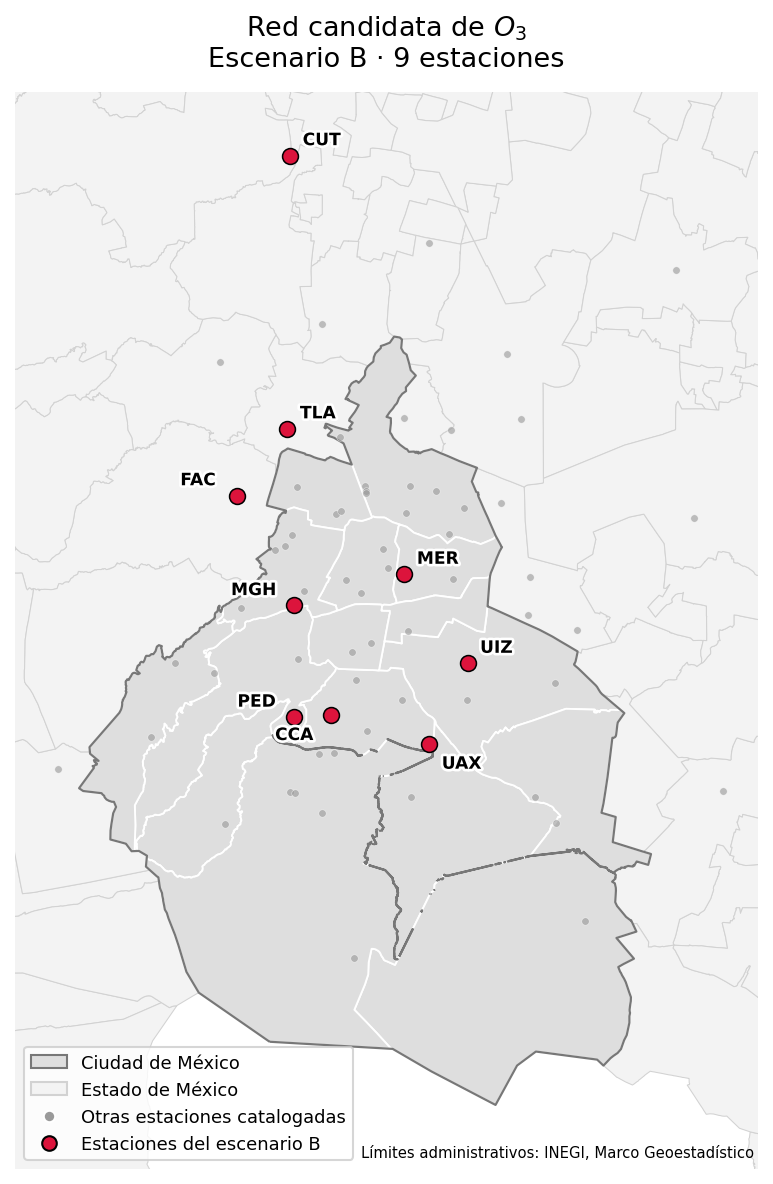

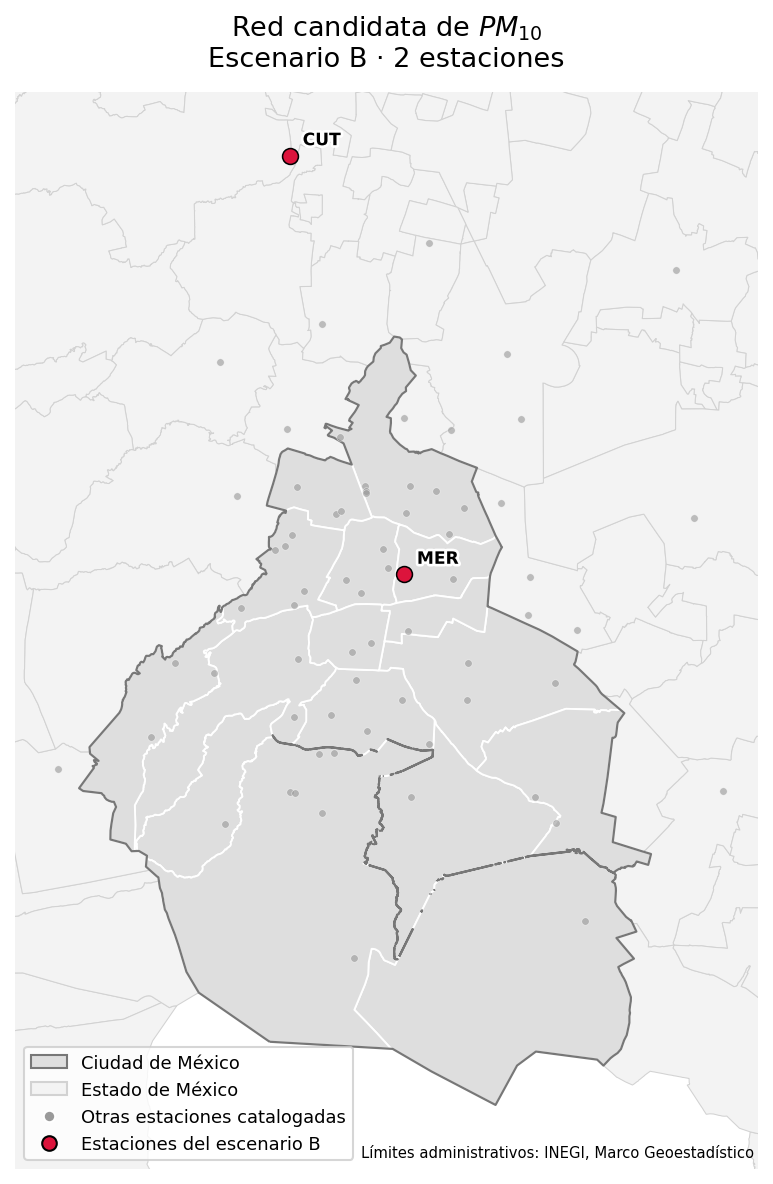

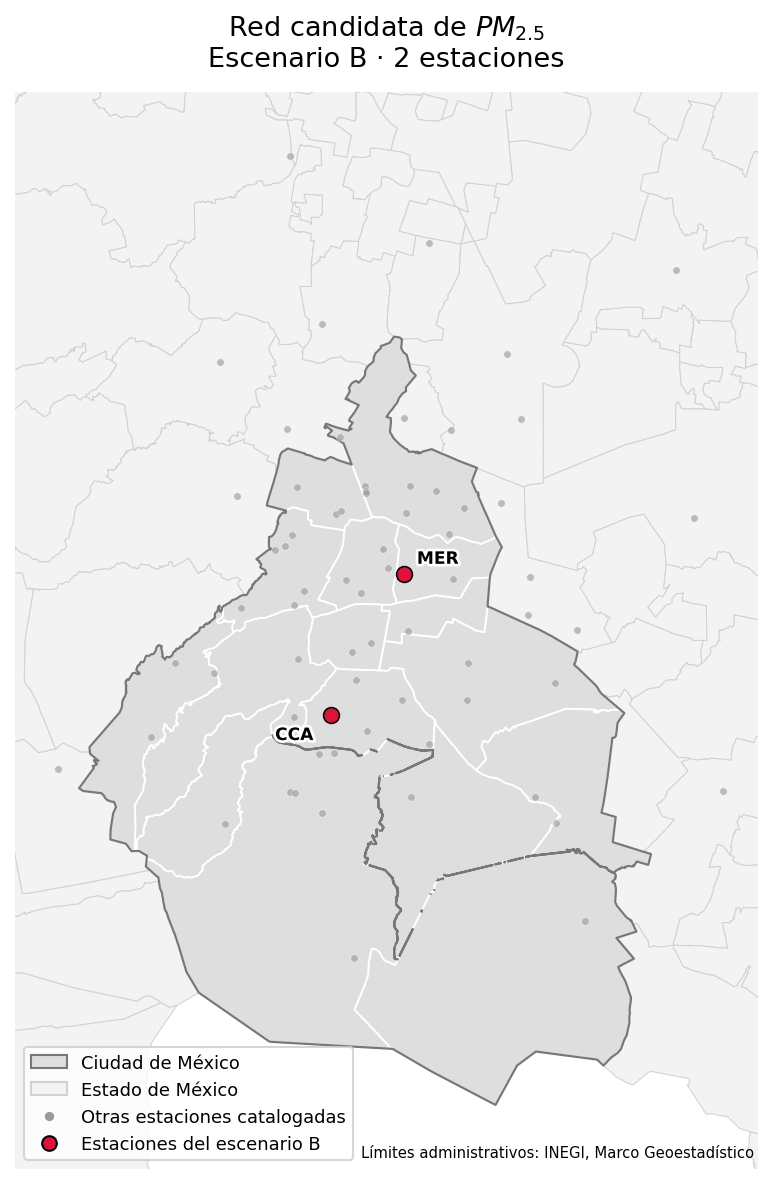

In [29]:
# MAPAS DE LAS REDES CANDIDATAS: ESCENARIO B

import matplotlib.patheffects as pe
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

# Encuadre común: CDMX y todas las candidatas.
limites_encuadre = np.vstack([
    gdf_mun_cdmx.total_bounds,
    estaciones_unicas_mapa.total_bounds,
])

MARGEN_MAPA = 5000  # Metros en EPSG:6372

XLIM_MAPA = (
    limites_encuadre[:, 0].min() - MARGEN_MAPA,
    limites_encuadre[:, 2].max() + MARGEN_MAPA,
)

YLIM_MAPA = (
    limites_encuadre[:, 1].min() - MARGEN_MAPA,
    limites_encuadre[:, 3].max() + MARGEN_MAPA,
)

OFFSETS_ESTACIONES = {
    "CCA": (-27, -12),
    "CUT": (6, 5),
    "FAC": (-27, 5),
    "MER": (6, 5),
    "MGH": (-30, 5),
    "PED": (-27, 5),
    "TLA": (6, 5),
    "UAX": (6, -12),
    "UIZ": (6, 5),
}

NOMBRES_CONTAMINANTES = {
    "O3": r"$O_3$",
    "PM10": r"$PM_{10}$",
    "PM25": r"$PM_{2.5}$",
}

figuras_redes_b = {}

for contaminante in CONTAMINANTES_OBJETIVO:

    red = gdf_candidatas_mapa.loc[
        (
            gdf_candidatas_mapa["CONTAMINANTE"]
            == contaminante
        )
        & gdf_candidatas_mapa["ESCENARIO_B"]
    ].copy()

    contexto = gdf_catalogo_mapa.loc[
        ~gdf_catalogo_mapa["cve_estac"].isin(red["ESTACION"])
    ]

    fig, ax = plt.subplots(figsize=(8.2, 8.0), dpi=150)

    gdf_mun_edomex.plot(
        ax=ax, color="#F3F3F3", edgecolor="#D2D2D2",
        linewidth=0.50, zorder=1,
    )

    gdf_mun_cdmx.plot(
        ax=ax, color="#DEDEDE", edgecolor="white",
        linewidth=0.9, zorder=2,
    )

    gdf_mun_cdmx.dissolve().boundary.plot(
        ax=ax, color="#777777", linewidth=1.05, zorder=3,
    )

    contexto.plot(
        ax=ax, color="#9A9A9A", markersize=13,
        edgecolor="white", linewidth=0.30,
        alpha=0.62, zorder=4,
    )

    red.plot(
        ax=ax, color="crimson", markersize=58,
        edgecolor="black", linewidth=0.75, zorder=5,
    )

    for _, fila in red.iterrows():
        texto = ax.annotate(
            fila["ESTACION"],
            xy=(fila.geometry.x, fila.geometry.y),
            xytext=OFFSETS_ESTACIONES.get(
                fila["ESTACION"], (5, 5)
            ),
            textcoords="offset points",
            fontsize=8.2,
            fontweight="bold",
            zorder=6,
        )

        texto.set_path_effects([
            pe.Stroke(linewidth=2.6, foreground="white"),
            pe.Normal(),
        ])

    ax.set_xlim(XLIM_MAPA)
    ax.set_ylim(YLIM_MAPA)
    ax.set_aspect("equal")
    ax.axis("off")

    ax.set_title(
        f"Red candidata de {NOMBRES_CONTAMINANTES[contaminante]}"
        f"\nEscenario B · {len(red)} estaciones",
        fontsize=13,
        pad=12,
    )

    ax.legend(
        handles=[
            Patch(
                facecolor="#DEDEDE", edgecolor="#777777",
                label="Ciudad de México",
            ),
            Patch(
                facecolor="#F3F3F3", edgecolor="#D2D2D2",
                label="Estado de México",
            ),
            Line2D(
                [0], [0], marker="o", linestyle="None",
                markerfacecolor="#9A9A9A",
                markeredgecolor="white", markersize=5.5,
                label="Otras estaciones catalogadas",
            ),
            Line2D(
                [0], [0], marker="o", linestyle="None",
                markerfacecolor="crimson",
                markeredgecolor="black", markersize=7,
                label="Estaciones del escenario B",
            ),
        ],
        loc="lower left",
        frameon=True,
        fontsize=8.6,
    )

    ax.text(
        0.995, 0.008,
        "Límites administrativos: INEGI, Marco Geoestadístico",
        transform=ax.transAxes,
        ha="right", va="bottom", fontsize=7.1,
    )

    fig.tight_layout()
    figuras_redes_b[contaminante] = fig
    plt.show()

In [30]:
# GUARDAR LOS MAPAS DEL ESCENARIO B EN PNG A 600 DPI

DIR_FIGURAS_00 = (
    RUTA_BASE
    / "resultados_00_diagnostico_RAMA_contingencias"
    / "figuras"
)

DIR_FIGURAS_00.mkdir(parents=True, exist_ok=True)

for contaminante in CONTAMINANTES_OBJETIVO:

    ruta_figura = (
        DIR_FIGURAS_00
        / f"mapa_red_candidata_{contaminante}_escenario_B.png"
    )

    figuras_redes_b[contaminante].savefig(
        ruta_figura,
        dpi=200,
        bbox_inches="tight",
        facecolor="white",
    )

    print(f"Guardado: {ruta_figura.resolve()}")

Guardado: /Users/juanalbertomartinez/Desktop/contaminantes_Isay/resultados_00_diagnostico_RAMA_contingencias/figuras/mapa_red_candidata_O3_escenario_B.png
Guardado: /Users/juanalbertomartinez/Desktop/contaminantes_Isay/resultados_00_diagnostico_RAMA_contingencias/figuras/mapa_red_candidata_PM10_escenario_B.png
Guardado: /Users/juanalbertomartinez/Desktop/contaminantes_Isay/resultados_00_diagnostico_RAMA_contingencias/figuras/mapa_red_candidata_PM25_escenario_B.png


### 6.9. Comparación de la dispersión espacial entre escenarios

Calcularemos las distancias geodésicas entre pares de estaciones de cada
red candidata, expresadas en kilómetros.

Utilizaremos las longitudes y latitudes del catálogo y el elipsoide WGS84,
de forma coherente con el supuesto de referencia adoptado anteriormente.

Para cada contaminante y escenario resumiremos:

- número y claves de estaciones;
- distancia mínima entre pares;
- distancia media entre pares;
- distancia máxima entre pares.

Las redes de una sola estación no tienen distancias entre pares; sus
indicadores se registrarán como valores no aplicables.

Estas medidas describen la separación espacial de las estaciones.
Una distancia mayor no implica automáticamente mejor representatividad,
por lo que interpretaremos los resultados junto con los mapas y la
disponibilidad temporal.

In [31]:
# DISTANCIAS GEODÉSICAS ENTRE ESTACIONES POR ESCENARIO

from pyproj import Geod
from itertools import combinations

geod = Geod(ellps="WGS84")

registros_distancias = []
registros_dispersion = []

for contaminante in CONTAMINANTES_OBJETIVO:
    for escenario in ["ESCENARIO_A", "ESCENARIO_B", "ESCENARIO_C"]:

        red = (
            candidatas_geograficas.loc[
                (
                    candidatas_geograficas["CONTAMINANTE"]
                    == contaminante
                )
                & candidatas_geograficas[escenario]
            ]
            .sort_values("ESTACION")
            .set_index("ESTACION")
        )

        distancias_km = []

        for estacion_1, estacion_2 in combinations(red.index, 2):

            _, _, distancia_m = geod.inv(
                red.loc[estacion_1, "longitud"],
                red.loc[estacion_1, "latitud"],
                red.loc[estacion_2, "longitud"],
                red.loc[estacion_2, "latitud"],
            )

            distancia_km = distancia_m / 1000
            distancias_km.append(distancia_km)

            registros_distancias.append({
                "CONTAMINANTE": contaminante,
                "ESCENARIO": escenario,
                "ESTACION_1": estacion_1,
                "ESTACION_2": estacion_2,
                "DISTANCIA_KM": distancia_km,
            })

        registros_dispersion.append({
            "CONTAMINANTE": contaminante,
            "ESCENARIO": escenario,
            "N_ESTACIONES": len(red),
            "ESTACIONES": ", ".join(red.index),
            "DIST_MIN_KM": (
                min(distancias_km) if distancias_km else np.nan
            ),
            "DIST_MEDIA_KM": (
                np.mean(distancias_km) if distancias_km else np.nan
            ),
            "DIST_MAX_KM": (
                max(distancias_km) if distancias_km else np.nan
            ),
        })

distancias_entre_estaciones = pd.DataFrame(registros_distancias)
dispersion_espacial_escenarios = pd.DataFrame(registros_dispersion)

print("Dispersión espacial por contaminante y escenario:")
display(
    dispersion_espacial_escenarios.round({
        "DIST_MIN_KM": 2,
        "DIST_MEDIA_KM": 2,
        "DIST_MAX_KM": 2,
    })
)

print("\nDistancias entre pares en las redes B de partículas:")
display(
    distancias_entre_estaciones.loc[
        (
            distancias_entre_estaciones["ESCENARIO"]
            == "ESCENARIO_B"
        )
        & distancias_entre_estaciones["CONTAMINANTE"].isin(
            ["PM10", "PM25"]
        )
    ]
    .round({"DISTANCIA_KM": 2})
    .reset_index(drop=True)
)

Dispersión espacial por contaminante y escenario:


,CONTAMINANTE,ESCENARIO,N_ESTACIONES,ESTACIONES,DIST_MIN_KM,DIST_MEDIA_KM,DIST_MAX_KM
0,O3,ESCENARIO_A,14,"CCA, CUT, FAC, LLA, MER, MGH, MON, NEZ, PED, S...",2.95,22.25,47.31
1,O3,ESCENARIO_B,9,"CCA, CUT, FAC, MER, MGH, PED, TLA, UAX, UIZ",2.95,19.23,47.31
2,O3,ESCENARIO_C,5,"CCA, CUT, FAC, MER, MGH",9.02,21.34,43.91
3,PM10,ESCENARIO_A,3,"CUT, MER, TLA",14.61,23.32,33.97
4,PM10,ESCENARIO_B,2,"CUT, MER",33.97,33.97,33.97
5,PM10,ESCENARIO_C,1,CUT,NaN,NaN,NaN
6,PM25,ESCENARIO_A,4,"CCA, MER, TLA, UAX",7.99,16.35,27.03
7,PM25,ESCENARIO_B,2,"CCA, MER",12.42,12.42,12.42
8,PM25,ESCENARIO_C,1,CCA,NaN,NaN,NaN



Distancias entre pares en las redes B de partículas:


,CONTAMINANTE,ESCENARIO,ESTACION_1,ESTACION_2,DISTANCIA_KM
0,PM10,ESCENARIO_B,CUT,MER,33.97
1,PM25,ESCENARIO_B,CCA,MER,12.42


### 6.10. Comparación conjunta de disponibilidad temporal y dispersión espacial

Compararemos los escenarios A, B y C utilizando el mismo periodo horario
2015–2025.

Para cada red calcularemos:

- porcentaje de horas con al menos una estación disponible;
- porcentaje de horas con al menos dos estaciones disponibles;
- porcentaje de horas con toda la red disponible;
- duración máxima de una interrupción sin ninguna estación disponible.

Incorporaremos las distancias entre estaciones calculadas anteriormente.

Una red de una sola estación tendrá como no aplicable el porcentaje de
horas con al menos dos estaciones disponibles.

La comparación permitirá identificar qué estaciones adicionales aportan
continuidad o redundancia temporal y cuáles amplían la separación espacial.
La disponibilidad de alguna estación no equivale a conocer la concentración
en todos los puntos de la región.

Mantendremos el criterio de disponibilidad utilizado en el diagnóstico:
una medición numérica no faltante y distinta de -99.

In [32]:
# COMPARACIÓN TEMPORAL Y ESPACIAL DE LOS ESCENARIOS

# Guardar matrices para reutilizarlas en los siguientes análisis.
disponibilidad_candidatas = {}

for contaminante in CONTAMINANTES_OBJETIVO:

    estaciones = sorted(
        candidatas_geograficas.loc[
            candidatas_geograficas["CONTAMINANTE"] == contaminante,
            "ESTACION",
        ].unique()
    )

    bloques = []

    for anio in ANIOS:

        filas_archivo = inventario_objetivo.loc[
            (inventario_objetivo["ANIO"] == anio)
            & (inventario_objetivo["CONTAMINANTE"] == contaminante)
        ]

        if len(filas_archivo) != 1:
            raise ValueError(
                f"Se esperaba un archivo para {contaminante}, {anio}."
            )

        df = pd.read_excel(filas_archivo.iloc[0]["RUTA"])

        timestamp = (
            pd.to_datetime(df["FECHA"], errors="raise")
            + pd.to_timedelta(
                pd.to_numeric(df["HORA"], errors="raise") - 1,
                unit="h",
            )
        )

        # Las columnas ausentes se incorporan como NaN.
        bloque = (
            df.reindex(columns=estaciones)
            .apply(pd.to_numeric, errors="coerce")
        )
        bloque.index = pd.DatetimeIndex(timestamp)
        bloques.append(bloque)

    datos = pd.concat(bloques).sort_index()

    if datos.index.has_duplicates:
        raise ValueError(
            f"Hay horas duplicadas en las series de {contaminante}."
        )

    datos = datos.reindex(indice_horario_completo)

    disponibilidad_candidatas[contaminante] = (
        datos.notna() & datos.ne(-99)
    )

registros_comparacion = []

for contaminante in CONTAMINANTES_OBJETIVO:
    for escenario in ["ESCENARIO_A", "ESCENARIO_B", "ESCENARIO_C"]:

        estaciones = candidatas_geograficas.loc[
            (
                candidatas_geograficas["CONTAMINANTE"]
                == contaminante
            )
            & candidatas_geograficas[escenario],
            "ESTACION",
        ].tolist()

        if not estaciones:
            raise ValueError(
                f"Red vacía: {contaminante}, {escenario}."
            )

        k = disponibilidad_candidatas[contaminante][
            estaciones
        ].sum(axis=1)

        rachas = longitudes_rachas_faltantes(k >= 1)

        registros_comparacion.append({
            "CONTAMINANTE": contaminante,
            "ESCENARIO": escenario,
            "PCT_HORAS_GE_1": 100 * (k >= 1).mean(),
            "PCT_HORAS_GE_2": (
                100 * (k >= 2).mean()
                if len(estaciones) >= 2 else np.nan
            ),
            "PCT_HORAS_TODAS": (
                100 * (k == len(estaciones)).mean()
            ),
            "MAX_RACHA_SIN_RED_DIAS": (
                rachas.max() / 24 if len(rachas) else 0
            ),
        })

comparacion_temporal_espacial = (
    dispersion_espacial_escenarios.merge(
        pd.DataFrame(registros_comparacion),
        on=["CONTAMINANTE", "ESCENARIO"],
        how="left",
        validate="one_to_one",
    )
)

for contaminante in CONTAMINANTES_OBJETIVO:
    print(f"\n{contaminante}: comparación temporal y espacial")
    display(
        comparacion_temporal_espacial.loc[
            comparacion_temporal_espacial["CONTAMINANTE"]
            == contaminante
        ]
        .drop(columns="CONTAMINANTE")
        .round(2)
        .reset_index(drop=True)
    )


O3: comparación temporal y espacial


,ESCENARIO,N_ESTACIONES,ESTACIONES,DIST_MIN_KM,DIST_MEDIA_KM,DIST_MAX_KM,PCT_HORAS_GE_1,PCT_HORAS_GE_2,PCT_HORAS_TODAS,MAX_RACHA_SIN_RED_DIAS
0,ESCENARIO_A,14,"CCA, CUT, FAC, LLA, MER, MGH, MON, NEZ, PED, S...",2.95,22.25,47.31,98.22,98.04,17.42,0.25
1,ESCENARIO_B,9,"CCA, CUT, FAC, MER, MGH, PED, TLA, UAX, UIZ",2.95,19.23,47.31,98.04,97.79,42.78,0.25
2,ESCENARIO_C,5,"CCA, CUT, FAC, MER, MGH",9.02,21.34,43.91,97.95,97.68,67.00,0.33



PM10: comparación temporal y espacial


,ESCENARIO,N_ESTACIONES,ESTACIONES,DIST_MIN_KM,DIST_MEDIA_KM,DIST_MAX_KM,PCT_HORAS_GE_1,PCT_HORAS_GE_2,PCT_HORAS_TODAS,MAX_RACHA_SIN_RED_DIAS
0,ESCENARIO_A,3,"CUT, MER, TLA",14.61,23.32,33.97,99.30,92.08,59.48,2.21
1,ESCENARIO_B,2,"CUT, MER",33.97,33.97,33.97,97.20,74.66,74.66,29.12
2,ESCENARIO_C,1,CUT,NaN,NaN,NaN,87.31,NaN,87.31,38.58



PM25: comparación temporal y espacial


,ESCENARIO,N_ESTACIONES,ESTACIONES,DIST_MIN_KM,DIST_MEDIA_KM,DIST_MAX_KM,PCT_HORAS_GE_1,PCT_HORAS_GE_2,PCT_HORAS_TODAS,MAX_RACHA_SIN_RED_DIAS
0,ESCENARIO_A,4,"CCA, MER, TLA, UAX",7.99,16.35,27.03,99.82,97.76,51.52,1.00
1,ESCENARIO_B,2,"CCA, MER",12.42,12.42,12.42,97.56,76.66,76.66,29.29
2,ESCENARIO_C,1,CCA,NaN,NaN,NaN,89.68,NaN,89.68,46.08


La ampliación de las redes de partículas tiene un beneficio temporal claro. En PM$_{10}$, añadir TLA reduce la interrupción máxima de 29.12 a 2.21 días. En PM$_{2.5}$, añadir TLA y UAX aumenta la disponibilidad con dos estaciones de 76.66 % a 97.76 % y reduce la interrupción máxima a un día.
Para ozono, pasar de B a A aporta solo 0.18 puntos porcentuales de disponibilidad con alguna estación y no reduce la interrupción máxima. Eso favorece conservar B como candidata principal, aunque las cinco estaciones adicionales podrían aportar información espacial que estas métricas no capturan.

### 6.11. Contribución incremental de estaciones en las redes de partículas

Evaluaremos ampliaciones específicas de las redes del escenario B:

- PM10: añadir TLA a CUT–MER.
- PM2.5: añadir TLA, UAX o ambas a CCA–MER.

Para cada configuración calcularemos la disponibilidad horaria, la
redundancia y la interrupción máxima sin información.

También calcularemos las horas recuperadas respecto de la red B: horas
en las que la red B no tenía datos, pero la configuración ampliada dispone
de al menos una estación.

Incorporaremos la distancia máxima entre estaciones para describir la
extensión espacial de cada configuración. Las horas recuperadas por
diferentes ampliaciones pueden coincidir y no deben sumarse directamente.

In [33]:
# CONTRIBUCIÓN INCREMENTAL EN LAS REDES DE PARTÍCULAS

CONFIGURACIONES_PARTICULAS = {
    "PM10": {
        "BASE_B": ["CUT", "MER"],
        "B_MAS_TLA": ["CUT", "MER", "TLA"],
    },
    "PM25": {
        "BASE_B": ["CCA", "MER"],
        "B_MAS_TLA": ["CCA", "MER", "TLA"],
        "B_MAS_UAX": ["CCA", "MER", "UAX"],
        "B_MAS_TLA_UAX": ["CCA", "MER", "TLA", "UAX"],
    },
}

coordenadas_por_estacion = (
    catalogo_estaciones.set_index("cve_estac")
)

registros_incrementales = []

for contaminante, configuraciones in CONFIGURACIONES_PARTICULAS.items():

    disponibilidad = disponibilidad_candidatas[contaminante]

    k_base = disponibilidad[
        configuraciones["BASE_B"]
    ].sum(axis=1)

    for nombre, estaciones in configuraciones.items():

        k = disponibilidad[estaciones].sum(axis=1)
        rachas = longitudes_rachas_faltantes(k >= 1)

        horas_recuperadas = int(
            ((k_base == 0) & (k >= 1)).sum()
        )

        distancias = []

        for est1, est2 in combinations(estaciones, 2):
            _, _, distancia_m = geod.inv(
                coordenadas_por_estacion.loc[est1, "longitud"],
                coordenadas_por_estacion.loc[est1, "latitud"],
                coordenadas_por_estacion.loc[est2, "longitud"],
                coordenadas_por_estacion.loc[est2, "latitud"],
            )
            distancias.append(distancia_m / 1000)

        registros_incrementales.append({
            "CONTAMINANTE": contaminante,
            "CONFIGURACION": nombre,
            "N_ESTACIONES": len(estaciones),
            "ESTACIONES": ", ".join(estaciones),
            "PCT_HORAS_GE_1": 100 * (k >= 1).mean(),
            "PCT_HORAS_GE_2": 100 * (k >= 2).mean(),
            "MAX_RACHA_SIN_RED_DIAS": (
                rachas.max() / 24 if len(rachas) else 0
            ),
            "HORAS_RECUPERADAS_VS_B": horas_recuperadas,
            "GANANCIA_GE_1_PP": (
                100 * horas_recuperadas / len(k)
            ),
            "DIST_MAX_KM": max(distancias),
        })

comparacion_incremental_particulas = pd.DataFrame(
    registros_incrementales
)

for contaminante in CONFIGURACIONES_PARTICULAS:
    print(f"\n{contaminante}: contribución incremental")
    display(
        comparacion_incremental_particulas.loc[
            comparacion_incremental_particulas["CONTAMINANTE"]
            == contaminante
        ]
        .drop(columns="CONTAMINANTE")
        .round(2)
        .reset_index(drop=True)
    )


PM10: contribución incremental


,CONFIGURACION,N_ESTACIONES,ESTACIONES,PCT_HORAS_GE_1,PCT_HORAS_GE_2,MAX_RACHA_SIN_RED_DIAS,HORAS_RECUPERADAS_VS_B,GANANCIA_GE_1_PP,DIST_MAX_KM
0,BASE_B,2,"CUT, MER",97.2,74.66,29.12,0,0.0,33.97
1,B_MAS_TLA,3,"CUT, MER, TLA",99.3,92.08,2.21,2027,2.1,33.97



PM25: contribución incremental


,CONFIGURACION,N_ESTACIONES,ESTACIONES,PCT_HORAS_GE_1,PCT_HORAS_GE_2,MAX_RACHA_SIN_RED_DIAS,HORAS_RECUPERADAS_VS_B,GANANCIA_GE_1_PP,DIST_MAX_KM
0,BASE_B,2,"CCA, MER",97.56,76.66,29.29,0,0.00,12.42
1,B_MAS_TLA,3,"CCA, MER, TLA",99.16,92.74,11.00,1541,1.60,22.67
2,B_MAS_UAX,3,"CCA, MER, UAX",99.53,94.08,2.04,1901,1.97,13.41
3,B_MAS_TLA_UAX,4,"CCA, MER, TLA, UAX",99.82,97.76,1.00,2175,2.26,27.03


**Los resultados respaldan incorporar TLA para PM$_{10}$ y TLA–UAX para PM$_{2.5}$.**

- **PM$_{10}$:** TLA recupera 2027 horas sin información en la red B y reduce su interrupción máxima de 29.12 a 2.21 días.
- **PM$_{2.5}$:** UAX aporta más continuidad que TLA cuando se añaden por separado. La combinación de ambas obtiene la mayor redundancia temporal y una separación máxima de 27.03 km. Frente a añadir solo UAX, incorporar también TLA recupera **274 horas adicionales**.



In [34]:
# DISPONIBILIDAD POR AÑO–MES DE LAS REDES PROVISIONALES

REDES_PROVISIONALES = {
    "O3": [
        "CCA", "CUT", "FAC", "MER", "MGH",
        "PED", "TLA", "UAX", "UIZ",
    ],
    "PM10": ["CUT", "MER", "TLA"],
    "PM25": ["CCA", "MER", "TLA", "UAX"],
}

series_redes_provisionales = {}
registros_mensuales_red = []

for contaminante, estaciones in REDES_PROVISIONALES.items():

    k = disponibilidad_candidatas[contaminante][
        estaciones
    ].sum(axis=1)

    series_redes_provisionales[contaminante] = k

    for periodo, sub in k.groupby(k.index.to_period("M")):

        registros_mensuales_red.append({
            "CONTAMINANTE": contaminante,
            "ANIO": periodo.year,
            "MES": periodo.month,
            "PERIODO": str(periodo),
            "N_ESTACIONES_RED": len(estaciones),
            "HORAS_ESPERADAS": len(sub),
            "HORAS_SIN_RED": int((sub == 0).sum()),
            "PCT_HORAS_GE_1": 100 * (sub >= 1).mean(),
            "PCT_HORAS_GE_2": 100 * (sub >= 2).mean(),
            "MEDIA_ESTACIONES_DISPONIBLES": sub.mean(),
        })

disponibilidad_mensual_redes = pd.DataFrame(
    registros_mensuales_red
)

for contaminante in CONTAMINANTES_OBJETIVO:

    tabla = disponibilidad_mensual_redes.loc[
        disponibilidad_mensual_redes["CONTAMINANTE"]
        == contaminante
    ]

    print(
        f"\n{contaminante}: diez meses con menor "
        "disponibilidad de alguna estación"
    )

    display(
        tabla.sort_values(
            ["PCT_HORAS_GE_1", "PCT_HORAS_GE_2", "PERIODO"]
        )
        .head(10)
        .drop(columns="CONTAMINANTE")
        .round(2)
        .reset_index(drop=True)
    )

print("\nNúmero de meses evaluados por contaminante:")
display(
    disponibilidad_mensual_redes.groupby("CONTAMINANTE")
    .size()
    .reindex(CONTAMINANTES_OBJETIVO)
    .rename("N_MESES")
    .to_frame()
)


O3: diez meses con menor disponibilidad de alguna estación


,ANIO,MES,PERIODO,N_ESTACIONES_RED,HORAS_ESPERADAS,HORAS_SIN_RED,PCT_HORAS_GE_1,PCT_HORAS_GE_2,MEDIA_ESTACIONES_DISPONIBLES
0,2024,4,2024-04,9,720,27,96.25,96.11,8.09
1,2019,5,2019-05,9,744,23,96.91,96.91,7.54
2,2020,5,2020-05,9,744,23,96.91,96.91,8.52
3,2019,1,2019-01,9,744,22,97.04,97.04,8.51
4,2024,8,2024-08,9,744,22,97.04,97.04,8.22
5,2024,2,2024-02,9,696,20,97.13,97.13,6.98
6,2017,2,2017-02,9,672,19,97.17,97.17,7.55
7,2017,12,2017-12,9,744,21,97.18,97.18,7.00
8,2018,3,2018-03,9,744,21,97.18,97.18,8.01
9,2018,12,2018-12,9,744,21,97.18,97.18,8.39



PM10: diez meses con menor disponibilidad de alguna estación


,ANIO,MES,PERIODO,N_ESTACIONES_RED,HORAS_ESPERADAS,HORAS_SIN_RED,PCT_HORAS_GE_1,PCT_HORAS_GE_2,MEDIA_ESTACIONES_DISPONIBLES
0,2020,8,2020-08,3,744,96,87.10,28.76,1.16
1,2017,8,2017-08,3,744,92,87.63,55.38,1.43
2,2020,7,2020-07,3,744,57,92.34,60.22,1.82
3,2025,4,2025-04,3,720,55,92.36,77.78,2.13
4,2023,4,2023-04,3,720,36,95.00,70.97,1.94
5,2023,6,2023-06,3,720,30,95.83,42.36,1.38
6,2025,1,2025-01,3,744,29,96.10,83.06,2.25
7,2023,2,2023-02,3,672,17,97.47,74.26,2.11
8,2024,5,2024-05,3,744,18,97.58,75.40,1.96
9,2024,2,2024-02,3,696,15,97.84,76.15,1.80



PM25: diez meses con menor disponibilidad de alguna estación


,ANIO,MES,PERIODO,N_ESTACIONES_RED,HORAS_ESPERADAS,HORAS_SIN_RED,PCT_HORAS_GE_1,PCT_HORAS_GE_2,MEDIA_ESTACIONES_DISPONIBLES
0,2017,8,2017-08,4,744,63,91.53,59.01,1.94
1,2018,8,2018-08,4,744,16,97.85,88.17,2.34
2,2024,2,2024-02,4,696,12,98.28,78.88,1.83
3,2024,6,2024-06,4,720,9,98.75,91.39,2.45
4,2024,4,2024-04,4,720,8,98.89,96.67,2.67
5,2024,1,2024-01,4,744,8,98.92,84.27,1.89
6,2020,2,2020-02,4,696,7,98.99,96.55,3.60
7,2024,5,2024-05,4,744,6,99.19,83.60,2.07
8,2019,10,2019-10,4,744,6,99.19,89.92,2.32
9,2020,8,2020-08,4,744,6,99.19,92.34,2.60



Número de meses evaluados por contaminante:


,N_MESES
CONTAMINANTE,
O3,132
PM10,132
PM25,132


La revisión por año–mes confirma que **la cobertura global oculta algunos periodos débiles**:

- **$O_3$:** el peor mes conserva 96.25 % de disponibilidad con alguna estación.
- **PM$_{10}$:** agosto de 2020 baja a 87.10 %, y solo tiene dos estaciones disponibles en 28.76 % de las horas.
- **PM$_{2.5}$:** agosto de 2017 baja a 91.53 %, con dos estaciones disponibles en 59.01 %.


### 6.13. Selección de las redes de trabajo

Seleccionaremos las siguientes redes para continuar la construcción de
la base horaria:

$$
S_{O_3}
=
\{CCA,CUT,FAC,MER,MGH,PED,TLA,UAX,UIZ\},
$$

$$
S_{PM_{10}}
=
\{CUT,MER,TLA\},
$$

$$
S_{PM_{2.5}}
=
\{CCA,MER,TLA,UAX\}.
$$

Para ozono adoptaremos el escenario B, que combina estabilidad individual
con elevada disponibilidad conjunta.

Para partículas adoptaremos las redes del escenario A. Las estaciones
adicionales reducen las interrupciones de la red y aumentan la disponibilidad
simultánea de al menos dos estaciones.

La selección se apoya en la continuidad temporal, la complementariedad
entre estaciones y su distribución geográfica. No implica que las redes
representen exhaustivamente la contaminación de toda la ZMVM.

Construiremos una tabla de síntesis con los indicadores globales y los
meses más débiles. Distinguiremos el mes con menor disponibilidad de alguna
estación del mes con menor disponibilidad de al menos dos estaciones.

Los faltantes se conservarán. La suficiencia para construir rezagos,
promedios móviles y etiquetas se evaluará en la siguiente etapa.

In [35]:
# SELECCIÓN Y RESUMEN DE LAS REDES DE TRABAJO

REDES_SELECCIONADAS = {
    contaminante: estaciones.copy()
    for contaminante, estaciones in REDES_PROVISIONALES.items()
}

ESCENARIOS_SELECCIONADOS = {
    "O3": "ESCENARIO_B",
    "PM10": "ESCENARIO_A",
    "PM25": "ESCENARIO_A",
}

registros_resumen_final = []

for contaminante in CONTAMINANTES_OBJETIVO:

    escenario = ESCENARIOS_SELECCIONADOS[contaminante]

    registro = comparacion_temporal_espacial.loc[
        (
            comparacion_temporal_espacial["CONTAMINANTE"]
            == contaminante
        )
        & (
            comparacion_temporal_espacial["ESCENARIO"]
            == escenario
        )
    ].iloc[0].to_dict()

    # Comprobar que el resumen corresponde a la red elegida.
    estaciones_resumen = set(
        registro["ESTACIONES"].split(", ")
    )

    if estaciones_resumen != set(
        REDES_SELECCIONADAS[contaminante]
    ):
        raise ValueError(
            f"La composición del resumen no coincide para {contaminante}."
        )

    meses = disponibilidad_mensual_redes.loc[
        disponibilidad_mensual_redes["CONTAMINANTE"]
        == contaminante
    ]

    peor_ge1 = (
        meses.sort_values(["PCT_HORAS_GE_1", "PERIODO"])
        .iloc[0]
    )

    peor_ge2 = (
        meses.sort_values(["PCT_HORAS_GE_2", "PERIODO"])
        .iloc[0]
    )

    registro.update({
        "PEOR_PERIODO_GE_1": peor_ge1["PERIODO"],
        "MIN_MENSUAL_GE_1": peor_ge1["PCT_HORAS_GE_1"],
        "PEOR_PERIODO_GE_2": peor_ge2["PERIODO"],
        "MIN_MENSUAL_GE_2": peor_ge2["PCT_HORAS_GE_2"],
    })

    registros_resumen_final.append(registro)

resumen_final_redes = pd.DataFrame(registros_resumen_final)

print("Redes seleccionadas:")
for contaminante, estaciones in REDES_SELECCIONADAS.items():
    print(
        f"{contaminante}: {', '.join(estaciones)} "
        f"({len(estaciones)} estaciones)"
    )

print("\nIndicadores globales:")
display(
    resumen_final_redes[
        [
            "CONTAMINANTE",
            "N_ESTACIONES",
            "PCT_HORAS_GE_1",
            "PCT_HORAS_GE_2",
            "PCT_HORAS_TODAS",
            "MAX_RACHA_SIN_RED_DIAS",
            "DIST_MAX_KM",
        ]
    ].round(2)
)

print("\nPeriodos mensuales más débiles:")
display(
    resumen_final_redes[
        [
            "CONTAMINANTE",
            "PEOR_PERIODO_GE_1",
            "MIN_MENSUAL_GE_1",
            "PEOR_PERIODO_GE_2",
            "MIN_MENSUAL_GE_2",
        ]
    ].round(2)
)

Redes seleccionadas:
O3: CCA, CUT, FAC, MER, MGH, PED, TLA, UAX, UIZ (9 estaciones)
PM10: CUT, MER, TLA (3 estaciones)
PM25: CCA, MER, TLA, UAX (4 estaciones)

Indicadores globales:


,CONTAMINANTE,N_ESTACIONES,PCT_HORAS_GE_1,PCT_HORAS_GE_2,PCT_HORAS_TODAS,MAX_RACHA_SIN_RED_DIAS,DIST_MAX_KM
0,O3,9,98.04,97.79,42.78,0.25,47.31
1,PM10,3,99.30,92.08,59.48,2.21,33.97
2,PM25,4,99.82,97.76,51.52,1.00,27.03



Periodos mensuales más débiles:


,CONTAMINANTE,PEOR_PERIODO_GE_1,MIN_MENSUAL_GE_1,PEOR_PERIODO_GE_2,MIN_MENSUAL_GE_2
0,O3,2024-04,96.25,2024-04,96.11
1,PM10,2020-08,87.10,2020-08,28.76
2,PM25,2017-08,91.53,2017-08,59.01


### 6.14. Mapas de las redes seleccionadas

Representaremos las redes elegidas para continuar el proyecto:

- O3: nueve estaciones.
- PM10: tres estaciones.
- PM2.5: cuatro estaciones.

Conservaremos la misma extensión geográfica en los tres mapas para facilitar
su comparación. Las estaciones seleccionadas aparecerán en rojo y las demás
estaciones catalogadas se mostrarán en gris como contexto.

Ajustaremos la etiqueta CCA para distinguirla claramente de PED.

Guardaremos los mapas en formato PNG a 600 dpi, con nombres diferentes
de los mapas del escenario B, para conservar ambas etapas del análisis.

Guardado: /Users/juanalbertomartinez/Desktop/contaminantes_Isay/resultados_00_diagnostico_RAMA_contingencias/figuras/mapa_redes_seleccionadas_1x3_2015_2025.png


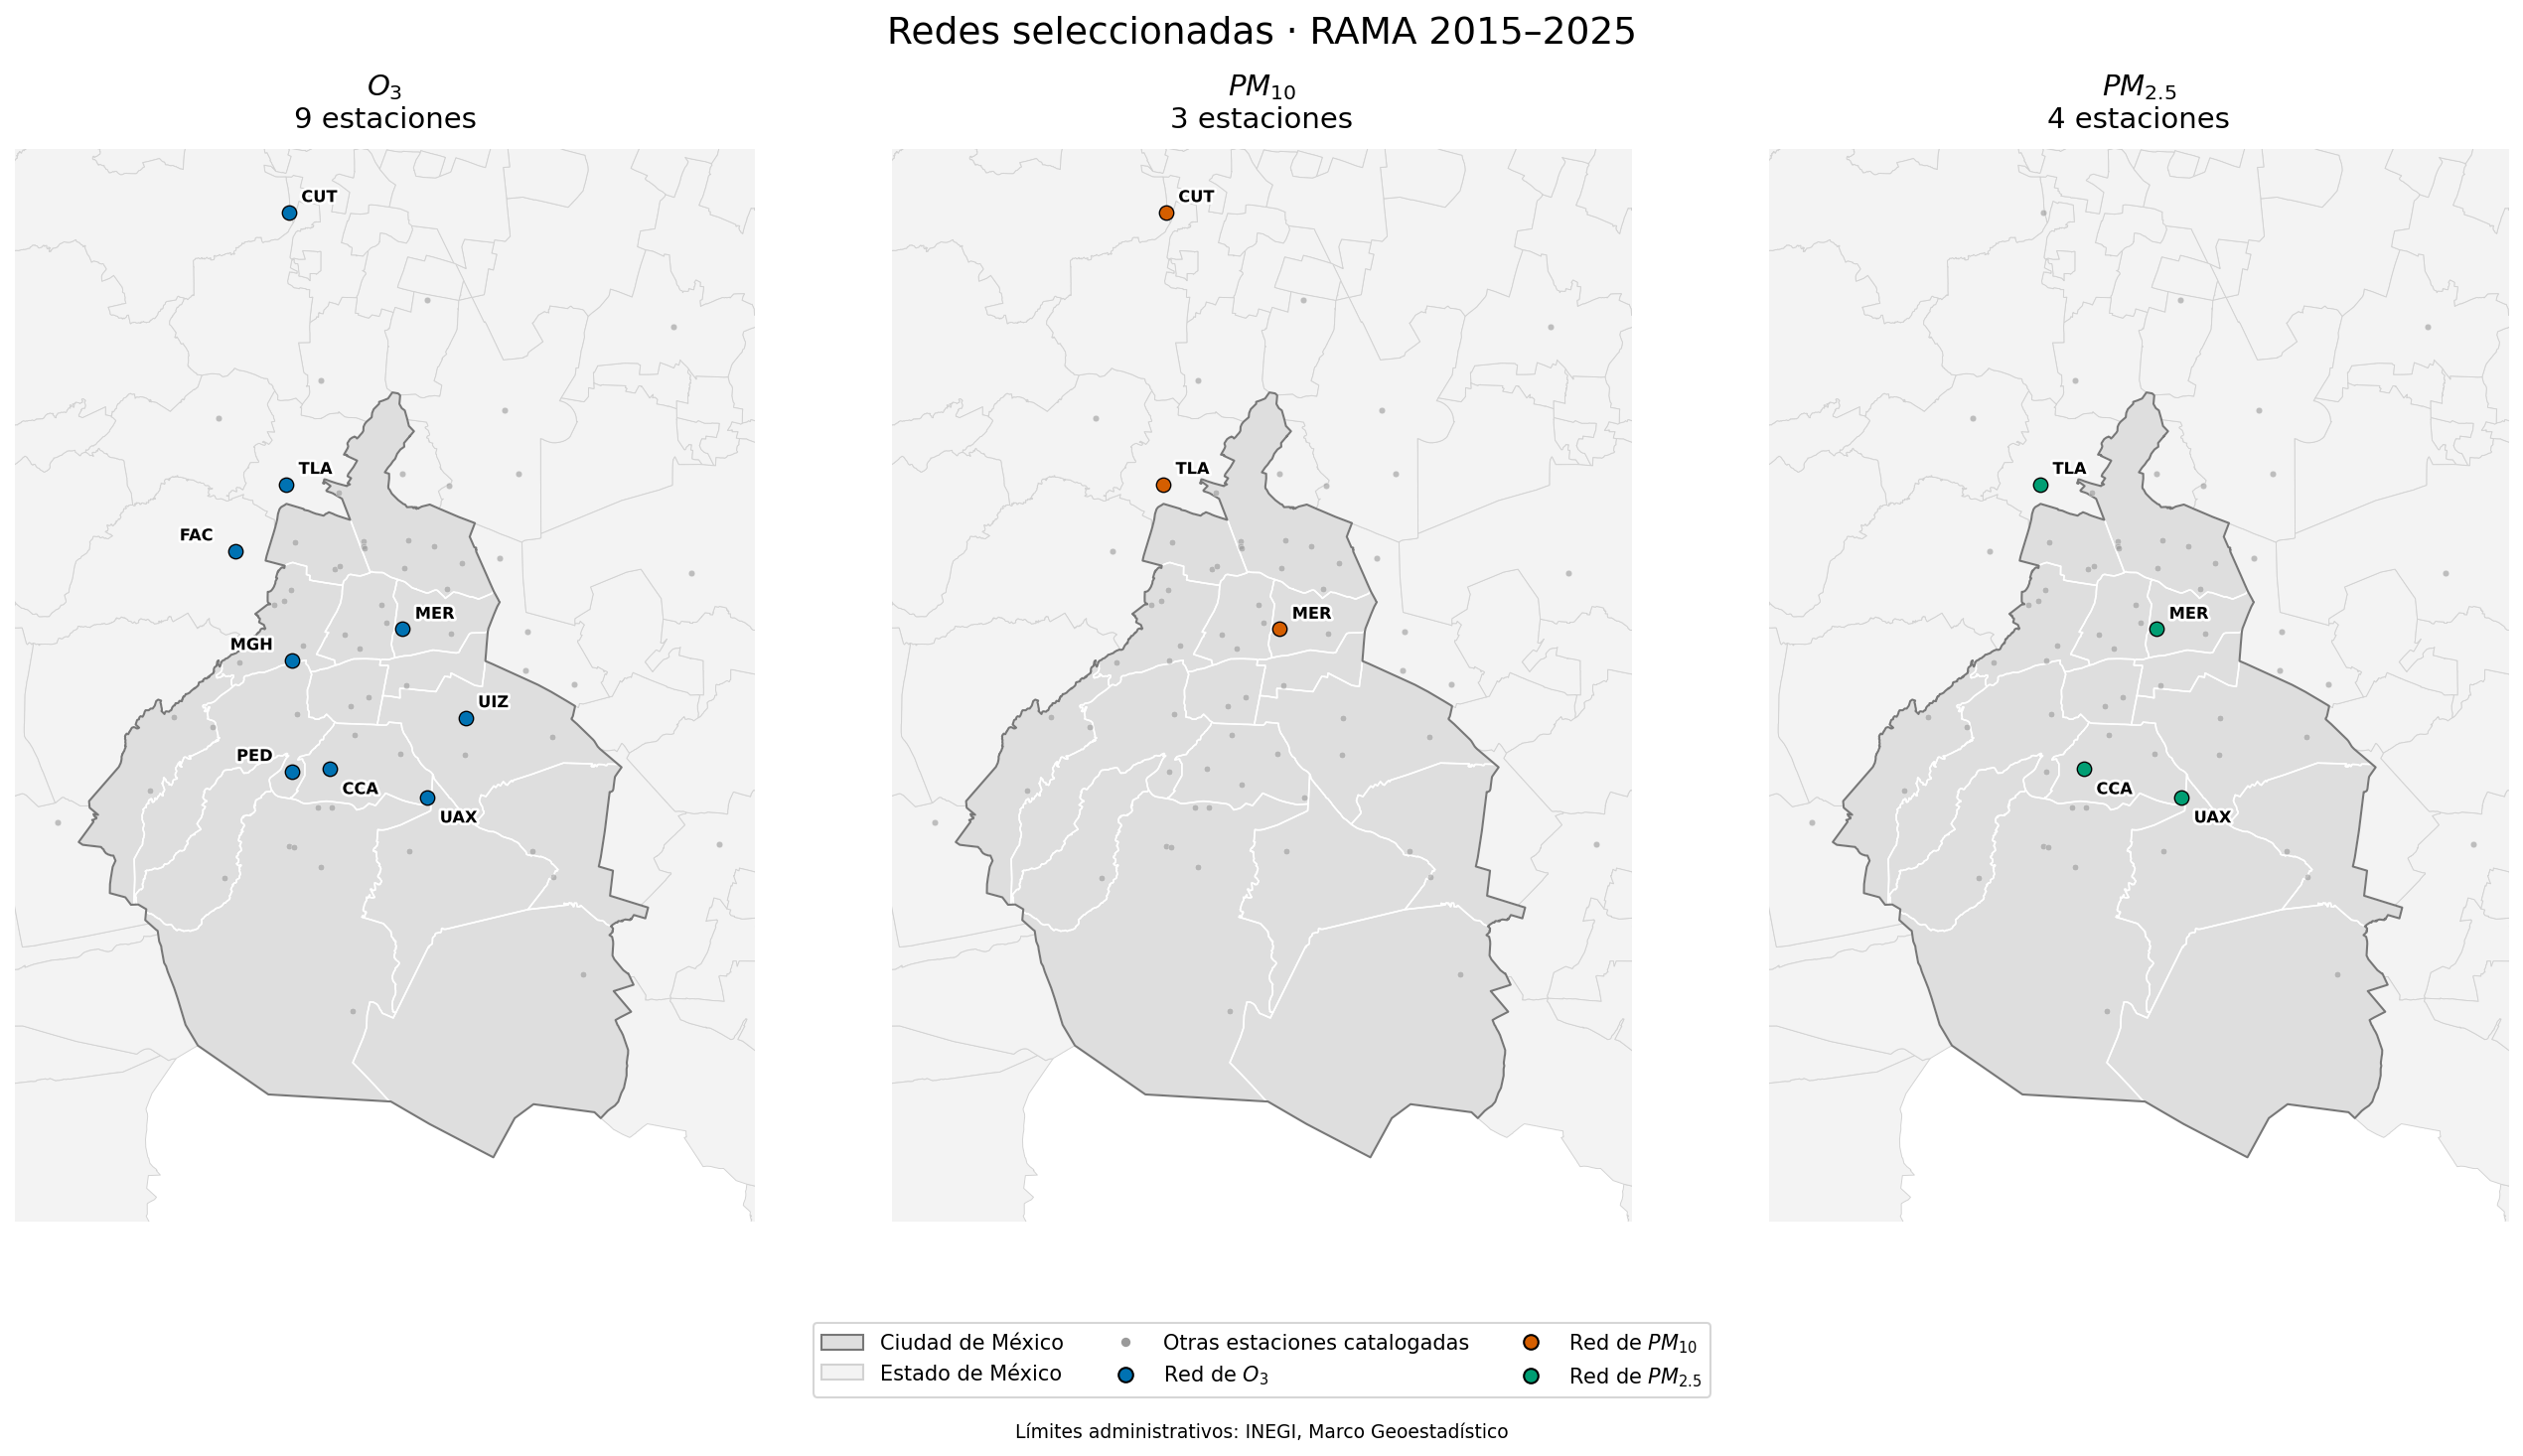

In [36]:
# MAPAS CONJUNTOS 1 × 3 CON CONTORNO EXTERIOR DE CDMX

RUTA_ENT_CDMX = (
    CARPETAS_CARTOGRAFIA["CDMX"] / "09ent.shp"
)

gdf_ent_cdmx = gpd.read_file(RUTA_ENT_CDMX)

if gdf_ent_cdmx.crs is None:
    raise ValueError("La capa estatal de CDMX no tiene CRS definido.")

gdf_ent_cdmx = gdf_ent_cdmx.to_crs(CRS_MAPA)

# Extraer polígonos para dibujar solamente los anillos exteriores.
poligonos_cdmx = []

for geometria in gdf_ent_cdmx.geometry:
    if geometria is None or geometria.is_empty:
        raise ValueError("La capa estatal contiene geometrías ausentes o vacías.")

    if geometria.geom_type == "Polygon":
        poligonos_cdmx.append(geometria)
    elif geometria.geom_type == "MultiPolygon":
        poligonos_cdmx.extend(geometria.geoms)
    else:
        raise ValueError(
            f"Geometría estatal inesperada: {geometria.geom_type}"
        )

COLORES_CONTAMINANTES = {
    "O3": "#0072B2",
    "PM10": "#D55E00",
    "PM25": "#009E73",
}

OFFSETS_ESTACIONES["CCA"] = (6, -12)

fig_redes_1x3, axes = plt.subplots(
    1, 3,
    figsize=(18, 10),
    dpi=150,
    sharex=True,
    sharey=True,
)

for ax, contaminante in zip(axes, CONTAMINANTES_OBJETIVO):

    estaciones = REDES_SELECCIONADAS[contaminante]

    red = gdf_candidatas_mapa.loc[
        (
            gdf_candidatas_mapa["CONTAMINANTE"]
            == contaminante
        )
        & gdf_candidatas_mapa["ESTACION"].isin(estaciones)
    ].copy()

    if (
        len(red) != len(estaciones)
        or set(red["ESTACION"]) != set(estaciones)
    ):
        raise ValueError(f"Revisar la red geográfica de {contaminante}.")

    contexto = gdf_catalogo_mapa.loc[
        ~gdf_catalogo_mapa["cve_estac"].isin(estaciones)
    ]

    gdf_mun_edomex.plot(
        ax=ax,
        color="#F3F3F3",
        edgecolor="#D2D2D2",
        linewidth=0.45,
        zorder=1,
    )

    # Fondo continuo de CDMX: oculta líneas de capas inferiores.
    for poligono in poligonos_cdmx:
        x, y = poligono.exterior.xy
        ax.fill(
            x, y,
            facecolor="#DEDEDE",
            edgecolor="none",
            zorder=2,
        )

    # Límites internos de alcaldías en blanco.
    gdf_mun_cdmx.boundary.plot(
        ax=ax,
        color="white",
        linewidth=0.75,
        zorder=3,
    )

    # Contorno gris exclusivamente exterior.
    for poligono in poligonos_cdmx:
        x, y = poligono.exterior.xy
        ax.plot(
            x, y,
            color="#777777",
            linewidth=1.0,
            zorder=4,
        )

    contexto.plot(
        ax=ax,
        color="#9A9A9A",
        markersize=10,
        edgecolor="white",
        linewidth=0.25,
        alpha=0.60,
        zorder=5,
    )

    red.plot(
        ax=ax,
        color=COLORES_CONTAMINANTES[contaminante],
        markersize=48,
        edgecolor="black",
        linewidth=0.65,
        zorder=6,
    )

    for _, fila in red.iterrows():
        texto = ax.annotate(
            fila["ESTACION"],
            xy=(fila.geometry.x, fila.geometry.y),
            xytext=OFFSETS_ESTACIONES.get(
                fila["ESTACION"], (5, 5)
            ),
            textcoords="offset points",
            fontsize=7.8,
            fontweight="bold",
            zorder=7,
        )

        texto.set_path_effects([
            pe.Stroke(linewidth=2.6, foreground="white"),
            pe.Normal(),
        ])

    ax.set_xlim(XLIM_MAPA)
    ax.set_ylim(YLIM_MAPA)
    ax.set_aspect("equal")
    ax.axis("off")

    ax.set_title(
        f"{NOMBRES_CONTAMINANTES[contaminante]}"
        f"\n{len(red)} estaciones",
        fontsize=14,
        pad=10,
    )

leyenda_comun = [
    Patch(
        facecolor="#DEDEDE",
        edgecolor="#777777",
        label="Ciudad de México",
    ),
    Patch(
        facecolor="#F3F3F3",
        edgecolor="#D2D2D2",
        label="Estado de México",
    ),
    Line2D(
        [0], [0],
        marker="o",
        linestyle="None",
        markerfacecolor="#9A9A9A",
        markeredgecolor="white",
        markersize=5.5,
        label="Otras estaciones catalogadas",
    ),
]

for contaminante in CONTAMINANTES_OBJETIVO:
    leyenda_comun.append(
        Line2D(
            [0], [0],
            marker="o",
            linestyle="None",
            markerfacecolor=COLORES_CONTAMINANTES[contaminante],
            markeredgecolor="black",
            markersize=7,
            label=f"Red de {NOMBRES_CONTAMINANTES[contaminante]}",
        )
    )

fig_redes_1x3.suptitle(
    "Redes seleccionadas · RAMA 2015–2025",
    fontsize=18,
    y=0.97,
)

fig_redes_1x3.legend(
    handles=leyenda_comun,
    loc="lower center",
    bbox_to_anchor=(0.5, 0.035),
    ncol=3,
    fontsize=10,
    frameon=True,
)

fig_redes_1x3.text(
    0.5, 0.015,
    "Límites administrativos: INEGI, Marco Geoestadístico",
    ha="center",
    fontsize=9,
)

fig_redes_1x3.subplots_adjust(
    left=0.015,
    right=0.985,
    top=0.88,
    bottom=0.16,
    wspace=0.035,
)

DIR_FIGURAS_00.mkdir(parents=True, exist_ok=True)

ruta_mapa_conjunto = (
    DIR_FIGURAS_00
    / "mapa_redes_seleccionadas_1x3_2015_2025.png"
)

fig_redes_1x3.savefig(
    ruta_mapa_conjunto,
    dpi=300,
    bbox_inches="tight",
    facecolor="white",
)

print(f"Guardado: {ruta_mapa_conjunto.resolve()}")
plt.show()

### 6.15. Comparación gráfica de la disponibilidad entre escenarios

Representaremos la disponibilidad horaria de los escenarios A, B y C
para cada contaminante.

Cada panel mostrará:

- porcentaje de horas con al menos una estación disponible;
- porcentaje de horas con al menos dos estaciones disponibles;
- número de estaciones de cada escenario.

Los tres paneles utilizarán la misma escala porcentual. La disponibilidad
con al menos dos estaciones se omitirá para las redes de una sola estación,
porque ese indicador no es aplicable.

Esta figura permitirá comparar la continuidad y redundancia temporal de
las redes. Los porcentajes representan disponibilidad de mediciones,
no desempeño predictivo ni cobertura completa de la región.

Guardado: /Users/juanalbertomartinez/Desktop/contaminantes_Isay/resultados_00_diagnostico_RAMA_contingencias/figuras/comparacion_disponibilidad_escenarios_2015_2025.png


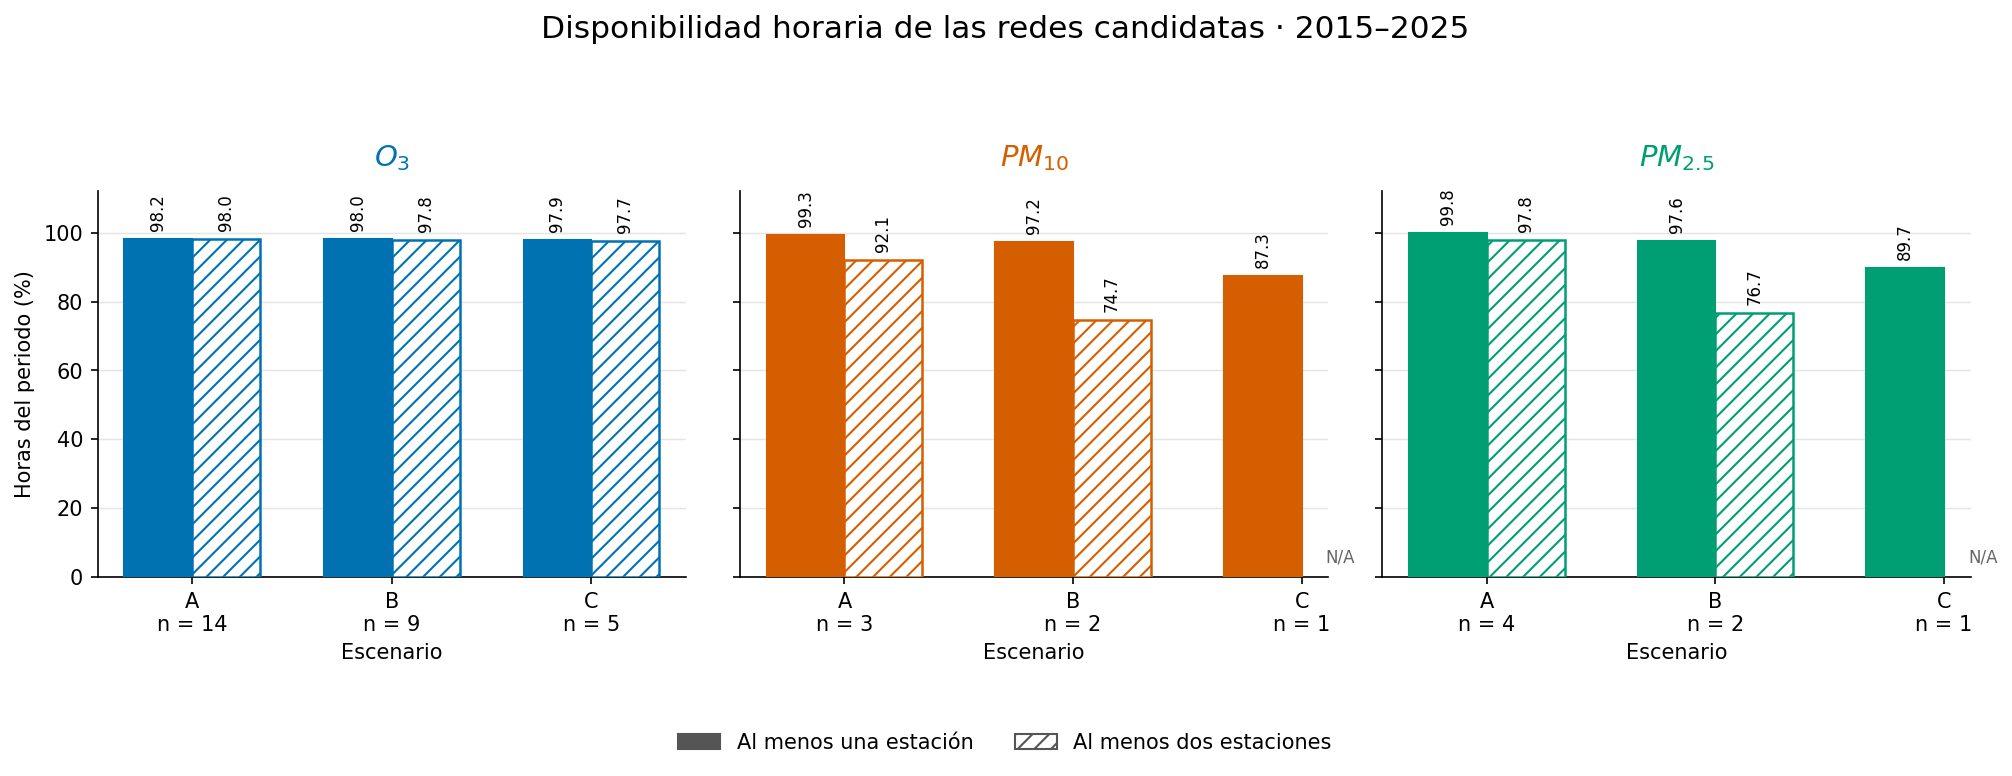

In [37]:
# COMPARACIÓN GRÁFICA DE DISPONIBILIDAD: ESCENARIOS A, B Y C

fig_disponibilidad, axes = plt.subplots(
    1, 3,
    figsize=(13.5, 5.2),
    dpi=150,
    sharey=True,
)

orden_escenarios = [
    "ESCENARIO_A",
    "ESCENARIO_B",
    "ESCENARIO_C",
]

x = np.arange(3)
ancho = 0.34

for ax, contaminante in zip(axes, CONTAMINANTES_OBJETIVO):

    tabla = (
        comparacion_temporal_espacial.loc[
            comparacion_temporal_espacial["CONTAMINANTE"]
            == contaminante
        ]
        .set_index("ESCENARIO")
        .loc[orden_escenarios]
    )

    color = COLORES_CONTAMINANTES[contaminante]

    barras_ge1 = ax.bar(
        x - ancho / 2,
        tabla["PCT_HORAS_GE_1"],
        width=ancho,
        color=color,
        edgecolor=color,
        linewidth=1,
        zorder=3,
    )

    valores_ge2 = tabla["PCT_HORAS_GE_2"].to_numpy()
    aplicables = np.isfinite(valores_ge2)

    barras_ge2 = ax.bar(
        x[aplicables] + ancho / 2,
        valores_ge2[aplicables],
        width=ancho,
        facecolor="white",
        edgecolor=color,
        hatch="///",
        linewidth=1.2,
        zorder=3,
    )

    ax.bar_label(
        barras_ge1,
        labels=[
            f"{valor:.1f}"
            for valor in tabla["PCT_HORAS_GE_1"]
        ],
        padding=4,
        fontsize=8,
        rotation=90,
    )

    ax.bar_label(
        barras_ge2,
        labels=[
            f"{valor:.1f}"
            for valor in valores_ge2[aplicables]
        ],
        padding=4,
        fontsize=8,
        rotation=90,
    )

    for posicion in x[~aplicables]:
        ax.text(
            posicion + ancho / 2,
            3,
            "N/A",
            ha="center",
            va="bottom",
            fontsize=8,
            color="#666666",
        )

    ax.set_xticks(x)
    ax.set_xticklabels([
        f"{escenario.rsplit('_', 1)[-1]}\n"
        f"n = {int(numero)}"
        for escenario, numero in zip(
            orden_escenarios,
            tabla["N_ESTACIONES"],
        )
    ])

    ax.set_title(
        NOMBRES_CONTAMINANTES[contaminante],
        fontsize=14,
        color=color,
        pad=12,
    )

    ax.set_xlabel("Escenario")
    ax.set_ylim(0, 112)
    ax.set_yticks(np.arange(0, 101, 20))
    ax.grid(axis="y", color="#E5E5E5", linewidth=0.7)
    ax.set_axisbelow(True)
    ax.spines[["top", "right"]].set_visible(False)

axes[0].set_ylabel("Horas del periodo (%)")

fig_disponibilidad.suptitle(
    "Disponibilidad horaria de las redes candidatas · 2015–2025",
    fontsize=15,
    y=0.98,
)

fig_disponibilidad.legend(
    handles=[
        Patch(
            facecolor="#555555",
            edgecolor="#555555",
            label="Al menos una estación",
        ),
        Patch(
            facecolor="white",
            edgecolor="#555555",
            hatch="///",
            label="Al menos dos estaciones",
        ),
    ],
    loc="lower center",
    bbox_to_anchor=(0.5, 0.01),
    ncol=2,
    frameon=False,
    fontsize=10,
)

fig_disponibilidad.tight_layout(
    rect=(0, 0.12, 1, 0.91)
)

ruta_fig_disponibilidad = (
    DIR_FIGURAS_00
    / "comparacion_disponibilidad_escenarios_2015_2025.png"
)

fig_disponibilidad.savefig(
    ruta_fig_disponibilidad,
    dpi=300,
    bbox_inches="tight",
    facecolor="white",
)

print(f"Guardado: {ruta_fig_disponibilidad.resolve()}")
plt.show()

### 6.16. Contribución de las estaciones adicionales en partículas

Representaremos el efecto de ampliar las redes B de PM10 y PM2.5.

La figura tendrá dos columnas, una por contaminante, y dos filas:

- horas recuperadas respecto de la red B;
- duración máxima de una interrupción sin estaciones disponibles.

Las horas recuperadas corresponden a instantes en que la red B no tenía
información y la configuración ampliada dispone de alguna estación.

Cada configuración se compara con la misma red B. Por tanto, las horas
recuperadas de las ampliaciones individuales no deben sumarse: pueden
coincidir.

La figura permitirá valorar simultáneamente el aumento de disponibilidad
y la reducción de interrupciones prolongadas.

Guardado: /Users/juanalbertomartinez/Desktop/contaminantes_Isay/resultados_00_diagnostico_RAMA_contingencias/figuras/contribucion_estaciones_particulas_2015_2025.png


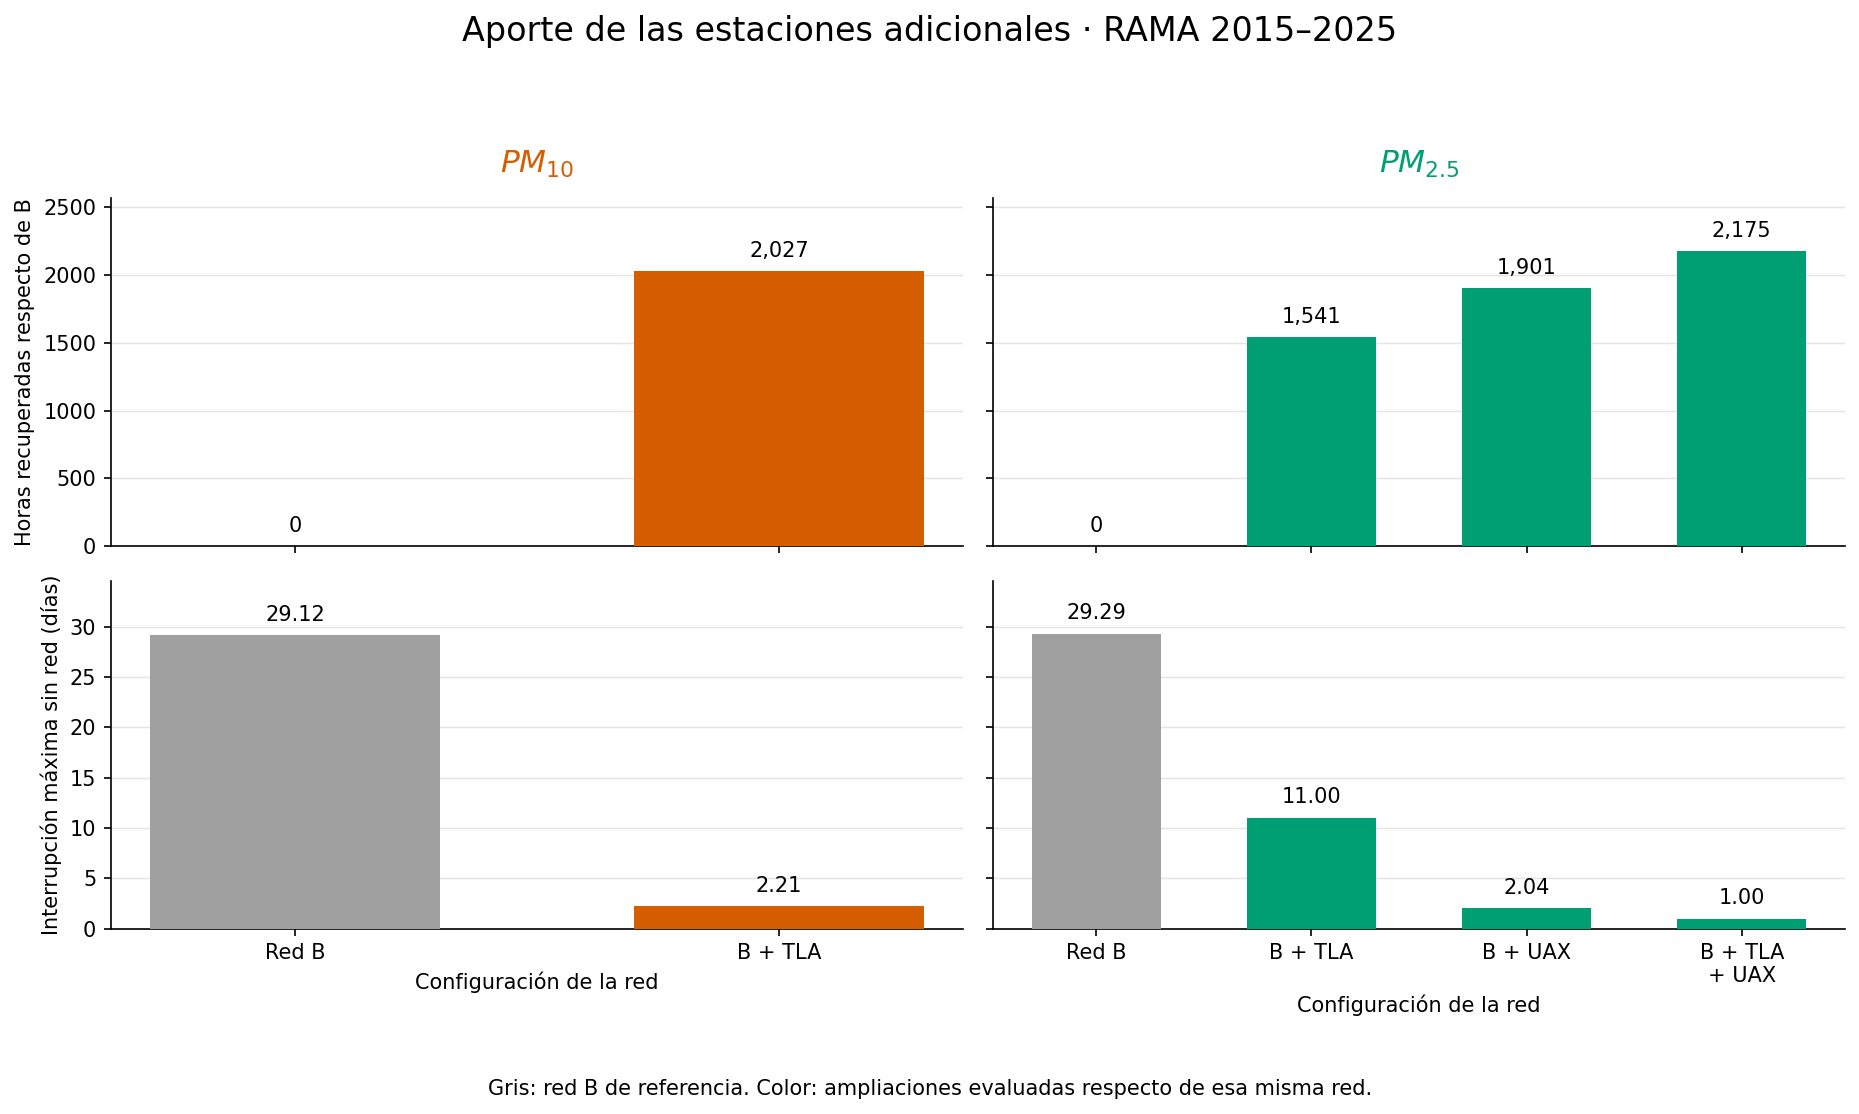

In [38]:
# CONTRIBUCIÓN DE TLA Y UAX: HORAS RECUPERADAS E INTERRUPCIONES

fig_contribucion, axes = plt.subplots(
    2, 2,
    figsize=(12.5, 7.5),
    dpi=150,
    sharex="col",
    sharey="row",
)

CONFIGURACIONES_GRAFICA = {
    "PM10": ["BASE_B", "B_MAS_TLA"],
    "PM25": [
        "BASE_B",
        "B_MAS_TLA",
        "B_MAS_UAX",
        "B_MAS_TLA_UAX",
    ],
}

ETIQUETAS_CONFIGURACION = {
    "BASE_B": "Red B",
    "B_MAS_TLA": "B + TLA",
    "B_MAS_UAX": "B + UAX",
    "B_MAS_TLA_UAX": "B + TLA\n+ UAX",
}

for columna, contaminante in enumerate(["PM10", "PM25"]):

    orden = CONFIGURACIONES_GRAFICA[contaminante]

    tabla = (
        comparacion_incremental_particulas.loc[
            comparacion_incremental_particulas["CONTAMINANTE"]
            == contaminante
        ]
        .set_index("CONFIGURACION")
        .loc[orden]
    )

    x = np.arange(len(tabla))
    color = COLORES_CONTAMINANTES[contaminante]
    colores = ["#A0A0A0"] + [color] * (len(tabla) - 1)

    horas = tabla["HORAS_RECUPERADAS_VS_B"].to_numpy()
    rachas = tabla["MAX_RACHA_SIN_RED_DIAS"].to_numpy()

    barras_horas = axes[0, columna].bar(
        x, horas,
        width=0.60,
        color=colores,
        zorder=3,
    )

    axes[0, columna].bar_label(
        barras_horas,
        labels=[f"{int(valor):,}" for valor in horas],
        padding=5,
        fontsize=10,
    )

    barras_rachas = axes[1, columna].bar(
        x, rachas,
        width=0.60,
        color=colores,
        zorder=3,
    )

    axes[1, columna].bar_label(
        barras_rachas,
        labels=[f"{valor:.2f}" for valor in rachas],
        padding=5,
        fontsize=10,
    )

    axes[0, columna].set_title(
        NOMBRES_CONTAMINANTES[contaminante],
        fontsize=15,
        color=color,
        pad=12,
    )

    for fila in range(2):
        ax = axes[fila, columna]

        ax.set_xticks(x)
        ax.set_xticklabels([
            ETIQUETAS_CONFIGURACION[nombre]
            for nombre in orden
        ])

        ax.grid(axis="y", color="#E5E5E5", linewidth=0.7)
        ax.set_axisbelow(True)
        ax.spines[["top", "right"]].set_visible(False)

    axes[1, columna].set_xlabel("Configuración de la red")

# Escalas comunes por fila, iniciadas en cero.
axes[0, 0].set_ylim(
    0,
    comparacion_incremental_particulas[
        "HORAS_RECUPERADAS_VS_B"
    ].max() * 1.18,
)

axes[1, 0].set_ylim(
    0,
    comparacion_incremental_particulas[
        "MAX_RACHA_SIN_RED_DIAS"
    ].max() * 1.18,
)

axes[0, 0].set_ylabel("Horas recuperadas respecto de B")
axes[1, 0].set_ylabel("Interrupción máxima sin red (días)")

fig_contribucion.suptitle(
    "Aporte de las estaciones adicionales · RAMA 2015–2025",
    fontsize=16,
    y=0.98,
)

fig_contribucion.text(
    0.5, 0.02,
    "Gris: red B de referencia. "
    "Color: ampliaciones evaluadas respecto de esa misma red.",
    ha="center",
    fontsize=10,
)

fig_contribucion.tight_layout(
    rect=(0, 0.07, 1, 0.93)
)

ruta_fig_contribucion = (
    DIR_FIGURAS_00
    / "contribucion_estaciones_particulas_2015_2025.png"
)

fig_contribucion.savefig(
    ruta_fig_contribucion,
    dpi=300,
    bbox_inches="tight",
    facecolor="white",
)

print(f"Guardado: {ruta_fig_contribucion.resolve()}")
plt.show()

### 6.17. Disponibilidad mensual de las redes seleccionadas

Construiremos una matriz de mapas de calor con dos filas y tres columnas:

- columnas: O3, PM10 y PM2.5;
- primera fila: porcentaje de horas con al menos una estación disponible;
- segunda fila: porcentaje de horas con al menos dos estaciones disponibles.

Cada celda representará una combinación año–mes del periodo 2015–2025.

Los seis paneles compartirán una escala de 0 a 100 %, para permitir una
comparación directa. Señalaremos el mes con menor disponibilidad de cada
panel y escribiremos su porcentaje.

La figura mostrará periodos de menor continuidad o redundancia que pueden
quedar ocultos en los indicadores globales. Los colores representan
disponibilidad de mediciones, no concentraciones de contaminantes.

Guardado: /Users/juanalbertomartinez/Desktop/contaminantes_Isay/resultados_00_diagnostico_RAMA_contingencias/figuras/disponibilidad_mensual_redes_seleccionadas_2015_2025.png


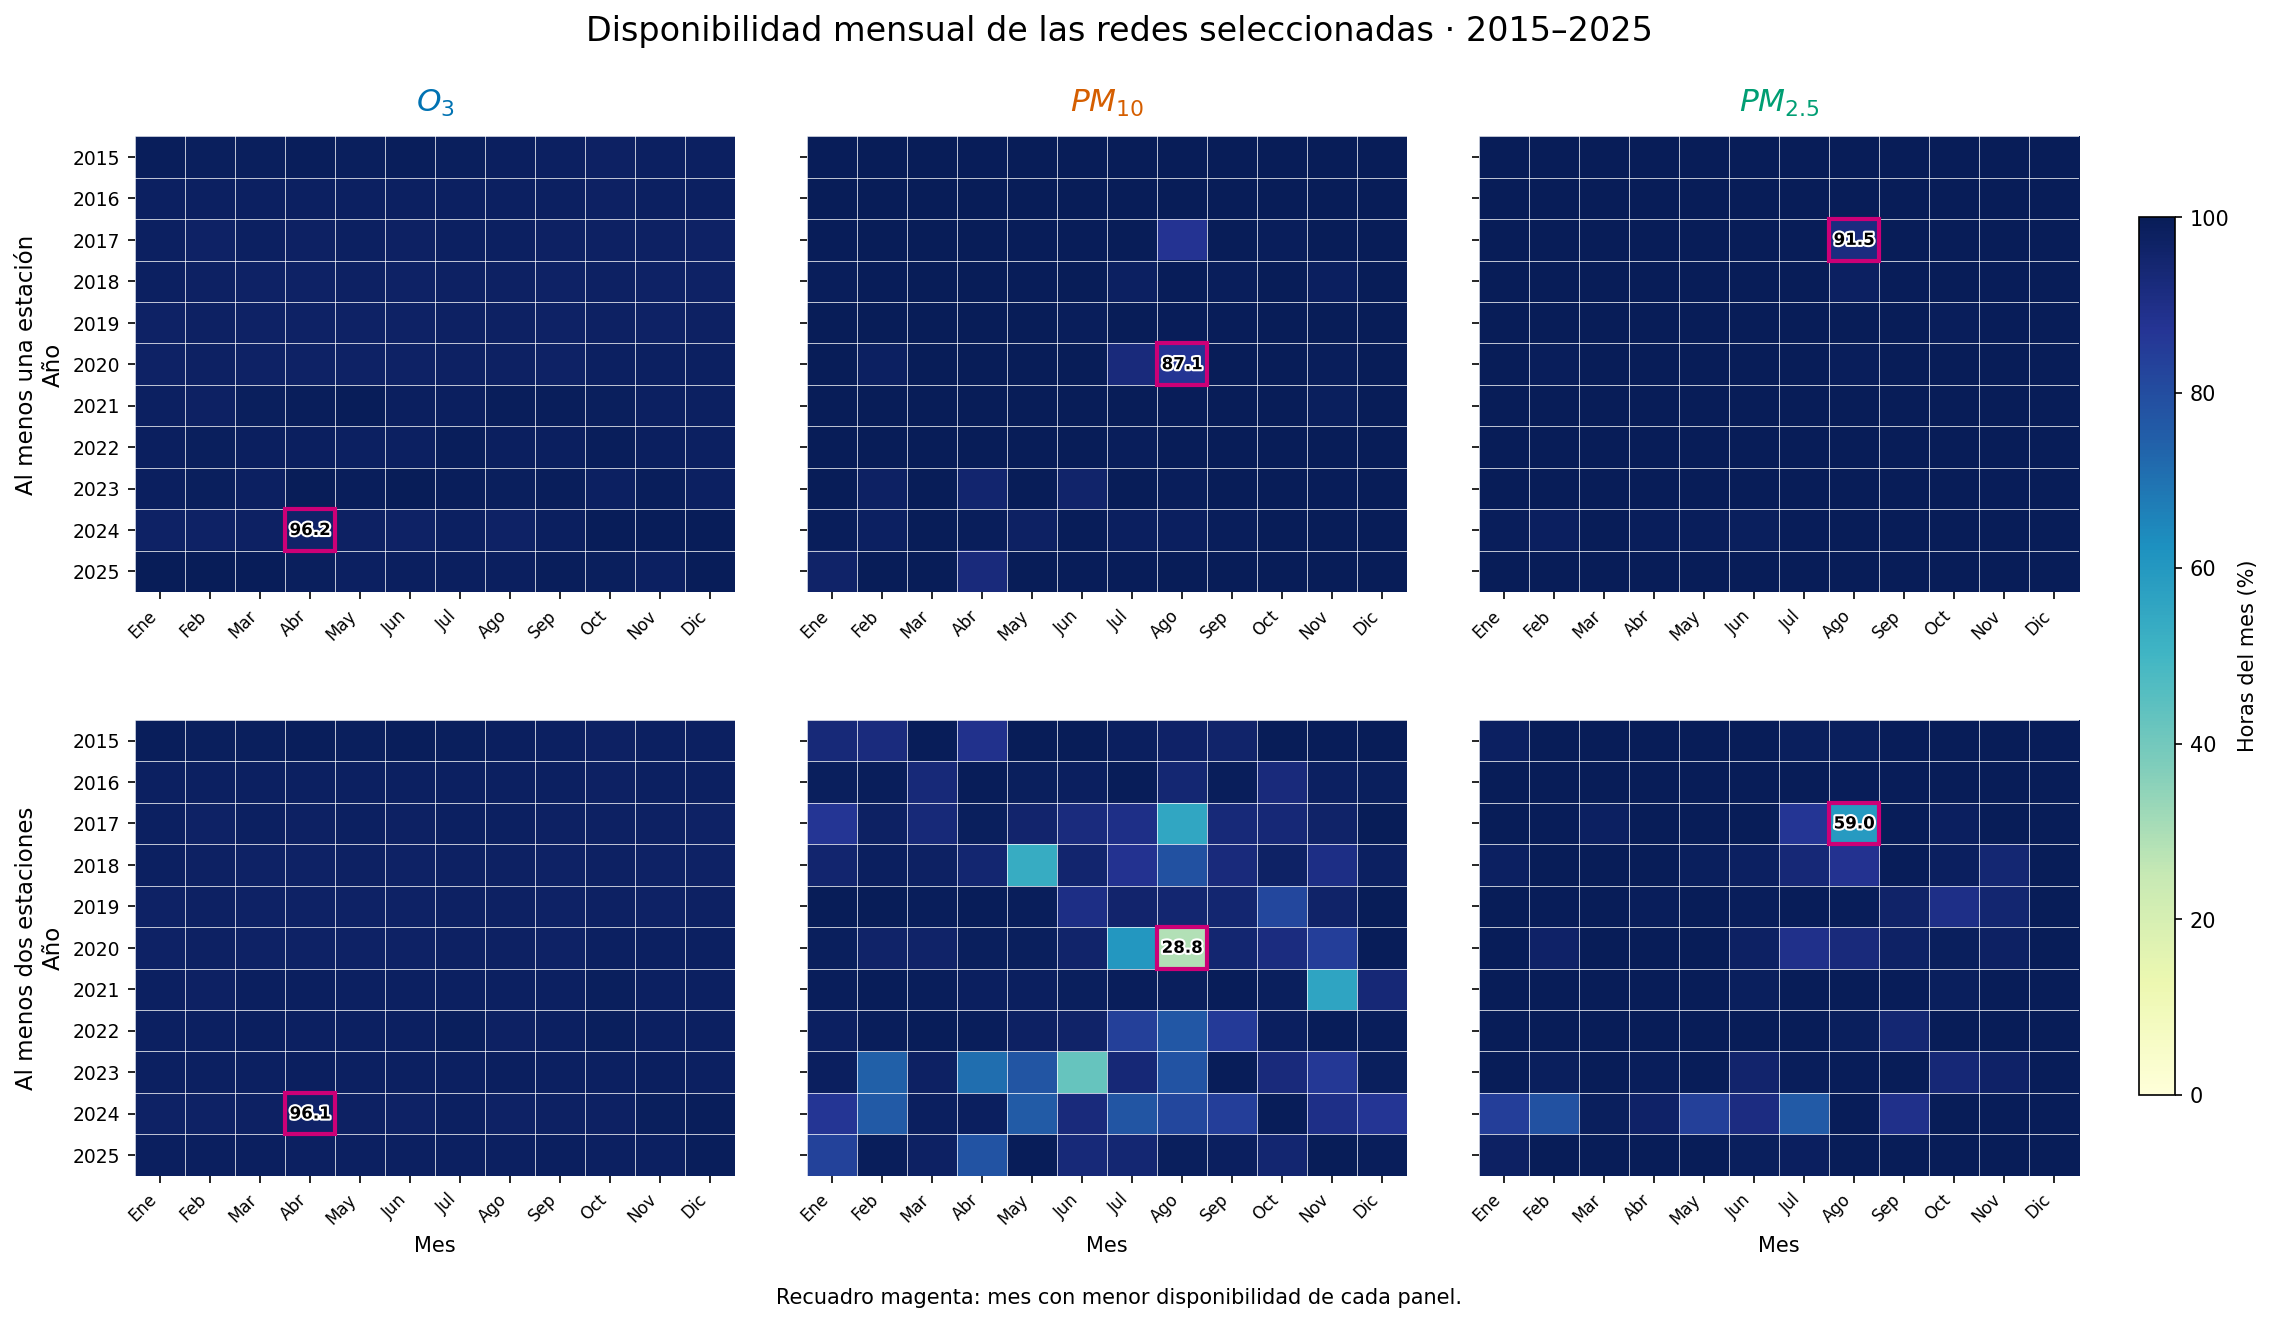


Mínimos señalados en la figura:


,CONTAMINANTE,INDICADOR,ANIO,MES,PORCENTAJE
0,O3,Al menos una estación,2024,4,96.25
1,O3,Al menos dos estaciones,2024,4,96.11
2,PM10,Al menos una estación,2020,8,87.10
3,PM10,Al menos dos estaciones,2020,8,28.76
4,PM25,Al menos una estación,2017,8,91.53
5,PM25,Al menos dos estaciones,2017,8,59.01


In [39]:
# MAPAS DE CALOR: DISPONIBILIDAD POR AÑO–MES

from matplotlib.patches import Rectangle

MESES_CORTOS = [
    "Ene", "Feb", "Mar", "Abr", "May", "Jun",
    "Jul", "Ago", "Sep", "Oct", "Nov", "Dic",
]

METRICAS_MENSUALES = [
    ("PCT_HORAS_GE_1", "Al menos una estación"),
    ("PCT_HORAS_GE_2", "Al menos dos estaciones"),
]

fig_cobertura_mensual, axes = plt.subplots(
    2, 3,
    figsize=(16, 9),
    dpi=150,
    sharey=True,
)

minimos_figura_mensual = []

for columna, contaminante in enumerate(CONTAMINANTES_OBJETIVO):

    tabla = disponibilidad_mensual_redes.loc[
        disponibilidad_mensual_redes["CONTAMINANTE"]
        == contaminante
    ]

    for fila, (metrica, descripcion) in enumerate(METRICAS_MENSUALES):

        ax = axes[fila, columna]

        matriz = (
            tabla.pivot(
                index="ANIO",
                columns="MES",
                values=metrica,
            )
            .reindex(
                index=list(ANIOS),
                columns=range(1, 13),
            )
        )

        valores = matriz.to_numpy(dtype=float)

        if not np.isfinite(valores).all():
            raise ValueError(
                f"Revisar la cobertura mensual de {contaminante}: {metrica}."
            )

        imagen = ax.imshow(
            valores,
            cmap="YlGnBu",
            vmin=0,
            vmax=100,
            aspect="auto",
            interpolation="nearest",
        )

        ax.set_xticks(np.arange(12))
        ax.set_xticklabels(
            MESES_CORTOS,
            rotation=45,
            ha="right",
            fontsize=8,
        )

        ax.set_yticks(np.arange(len(ANIOS)))
        ax.set_yticklabels(list(ANIOS), fontsize=9)

        # Separación visual de las celdas.
        ax.set_xticks(np.arange(-0.5, 12, 1), minor=True)
        ax.set_yticks(
            np.arange(-0.5, len(ANIOS), 1),
            minor=True,
        )
        ax.grid(
            which="minor",
            color="white",
            linewidth=0.35,
        )
        ax.tick_params(which="minor", bottom=False, left=False)

        for borde in ax.spines.values():
            borde.set_visible(False)

        if fila == 0:
            ax.set_title(
                NOMBRES_CONTAMINANTES[contaminante],
                fontsize=15,
                color=COLORES_CONTAMINANTES[contaminante],
                pad=12,
            )

        if columna == 0:
            ax.set_ylabel(
                f"{descripcion}\nAño",
                fontsize=11,
            )

        if fila == 1:
            ax.set_xlabel("Mes", fontsize=10)

        # Si hay empate, señalar el primer mínimo cronológico.
        i, j = np.unravel_index(
            np.argmin(valores),
            valores.shape,
        )
        minimo = valores[i, j]

        ax.add_patch(
            Rectangle(
                (j - 0.5, i - 0.5),
                1, 1,
                fill=False,
                edgecolor="#CC0077",
                linewidth=2,
                zorder=4,
            )
        )

        texto = ax.text(
            j, i,
            f"{minimo:.1f}",
            ha="center",
            va="center",
            fontsize=8,
            fontweight="bold",
            color="black",
            zorder=5,
        )

        texto.set_path_effects([
            pe.Stroke(linewidth=2, foreground="white"),
            pe.Normal(),
        ])

        minimos_figura_mensual.append({
            "CONTAMINANTE": contaminante,
            "INDICADOR": descripcion,
            "ANIO": int(matriz.index[i]),
            "MES": int(matriz.columns[j]),
            "PORCENTAJE": minimo,
        })

fig_cobertura_mensual.suptitle(
    "Disponibilidad mensual de las redes seleccionadas · 2015–2025",
    fontsize=16,
    y=0.98,
)

fig_cobertura_mensual.subplots_adjust(
    left=0.09,
    right=0.90,
    bottom=0.12,
    top=0.89,
    wspace=0.12,
    hspace=0.28,
)

ax_colorbar = fig_cobertura_mensual.add_axes(
    [0.925, 0.18, 0.015, 0.65]
)

colorbar = fig_cobertura_mensual.colorbar(
    imagen,
    cax=ax_colorbar,
    ticks=np.arange(0, 101, 20),
)

colorbar.set_label("Horas del mes (%)", fontsize=10)

fig_cobertura_mensual.text(
    0.5, 0.025,
    "Recuadro magenta: mes con menor disponibilidad de cada panel.",
    ha="center",
    fontsize=10,
)

ruta_fig_cobertura_mensual = (
    DIR_FIGURAS_00
    / "disponibilidad_mensual_redes_seleccionadas_2015_2025.png"
)

fig_cobertura_mensual.savefig(
    ruta_fig_cobertura_mensual,
    dpi=300,
    bbox_inches="tight",
    facecolor="white",
)

print(f"Guardado: {ruta_fig_cobertura_mensual.resolve()}")
plt.show()

print("\nMínimos señalados en la figura:")
display(
    pd.DataFrame(minimos_figura_mensual)
    .round({"PORCENTAJE": 2})
)

## 7. Conclusiones y resultados del diagnóstico

El análisis de RAMA 2015–2025 permitió seleccionar redes de trabajo por
contaminante, considerando estabilidad individual, complementariedad
temporal y distribución geográfica.

### 7.1. Redes seleccionadas

| Contaminante | Estaciones | Horas con ≥1 estación | Horas con ≥2 estaciones |
|---|---|---:|---:|
| O3 | CCA, CUT, FAC, MER, MGH, PED, TLA, UAX, UIZ | 98.04 % | 97.79 % |
| PM10 | CUT, MER, TLA | 99.30 % | 92.08 % |
| PM2.5 | CCA, MER, TLA, UAX | 99.82 % | 97.76 % |

Para ozono se seleccionó el escenario B. La ampliación al escenario A
incrementa ligeramente la disponibilidad conjunta y no reduce la
interrupción máxima sin información.

Para partículas se seleccionaron las redes del escenario A. Añadir TLA
a CUT–MER recupera 2027 horas para PM10. Incorporar TLA y UAX a CCA–MER
recupera 2175 horas para PM2.5.

Estos resultados muestran que una estación con menor continuidad individual
puede contribuir a la red cuando sus mediciones complementan los faltantes
de otras estaciones.

### 7.2. Continuidad y periodos débiles

Las interrupciones máximas sin ninguna estación disponible fueron:

- O3: 6 horas.
- PM10: aproximadamente 53 horas.
- PM2.5: 24 horas.

La disponibilidad global elevada no implica uniformidad temporal:

| Contaminante | Mes más débil | Horas con ≥1 estación | Horas con ≥2 estaciones |
|---|---|---:|---:|
| O3 | Abril de 2024 | 96.25 % | 96.11 % |
| PM10 | Agosto de 2020 | 87.10 % | 28.76 % |
| PM2.5 | Agosto de 2017 | 91.53 % | 59.01 % |

Los mapas de calor permiten localizar estos periodos. Su impacto sobre
rezagos, promedios móviles y etiquetas deberá evaluarse en la siguiente
etapa, conservando los faltantes sin imputación en este diagnóstico.

### 7.3. Distribución espacial

Las redes seleccionadas tienen separaciones máximas entre estaciones de
47.31 km para O3, 33.97 km para PM10 y 27.03 km para PM2.5.

Los mapas y las distancias describen su distribución geográfica, pero no
demuestran que las redes representen exhaustivamente la contaminación
de toda la ZMVM.

Se adoptó EPSG:4326 como supuesto para las coordenadas del catálogo,
pendiente de confirmación mediante sus metadatos. Los mapas utilizan
EPSG:6372 y las distancias se calcularon sobre el elipsoide WGS84.

### 7.4. Alcance de los resultados

Este notebook establece la selección de estaciones y caracteriza la
disponibilidad de sus mediciones. Todavía no define los episodios extremos,
las etiquetas de contingencia, los horizontes de anticipación ni los modelos.

Disponer de alguna estación no equivale a conocer las concentraciones
en todos los puntos de la región. Tampoco garantiza que una hora tenga
información suficiente para construir todos los predictores.

Los datos parciales de 2026 quedan fuera del diagnóstico de años completos.

### 7.5. Salidas para continuar el proyecto

Exportaremos las tablas de auditoría, cobertura, selección y comparación,
las coordenadas de las redes y la configuración metodológica.

Las figuras de síntesis son:

1. mapa conjunto de las redes seleccionadas;
2. comparación de disponibilidad entre escenarios;
3. contribución de estaciones adicionales en partículas;
4. disponibilidad mensual de las redes seleccionadas.

Estas salidas permitirán continuar con la construcción de la base horaria
y la definición operativa de los eventos.

In [40]:
# EXPORTACIÓN FINAL DEL DIAGNÓSTICO

import json

RUTA_RESULTADOS_00 = (
    RUTA_BASE / "resultados_00_diagnostico_RAMA_contingencias"
)
RUTA_RESULTADOS_00.mkdir(parents=True, exist_ok=True)

redes_seleccionadas_tabla = pd.DataFrame([
    {"CONTAMINANTE": contaminante, "ESTACION": estacion}
    for contaminante, estaciones in REDES_SELECCIONADAS.items()
    for estacion in estaciones
])

redes_seleccionadas_geograficas = (
    redes_seleccionadas_tabla.merge(
        catalogo_estaciones[
            [
                "cve_estac", "nom_estac", "longitud", "latitud",
                "alt", "obs_estac", "id_station",
            ]
        ],
        left_on="ESTACION",
        right_on="cve_estac",
        how="left",
        validate="many_to_one",
    )
    .drop(columns="cve_estac")
)

tablas_exportar = {
    "inventario_archivos_objetivo.csv": inventario_objetivo,
    "auditoria_estructural_archivos.csv": auditoria_objetivo,
    "cobertura_anual_estacion_contaminante.csv": cobertura_panel,
    "resumen_longitudinal_estaciones.csv": resumen_longitudinal,
    "cobertura_mensual_estaciones.csv": cobertura_mensual,
    "indicadores_estabilidad_temporal.csv": estabilidad_integrada,
    "sensibilidad_seleccion_estaciones.csv": sensibilidad_estaciones,
    "catalogo_estaciones_preparado.csv": catalogo_estaciones,
    "candidatas_con_coordenadas.csv": candidatas_geograficas,
    "distancias_entre_estaciones.csv": distancias_entre_estaciones,
    "dispersion_espacial_escenarios.csv": dispersion_espacial_escenarios,
    "comparacion_temporal_espacial.csv": comparacion_temporal_espacial,
    "comparacion_incremental_particulas.csv": (
        comparacion_incremental_particulas
    ),
    "disponibilidad_mensual_redes_seleccionadas.csv": (
        disponibilidad_mensual_redes
    ),
    "resumen_final_redes_seleccionadas.csv": resumen_final_redes,
    "redes_seleccionadas.csv": redes_seleccionadas_tabla,
    "redes_seleccionadas_con_coordenadas.csv": (
        redes_seleccionadas_geograficas
    ),
    "minimos_disponibilidad_mensual.csv": (
        pd.DataFrame(minimos_figura_mensual)
    ),
}

resumen_exportacion = []

for nombre, tabla in tablas_exportar.items():
    ruta = RUTA_RESULTADOS_00 / nombre
    tabla.to_csv(ruta, index=False, encoding="utf-8-sig")

    resumen_exportacion.append({
        "ARCHIVO": nombre,
        "FILAS": len(tabla),
        "COLUMNAS": len(tabla.columns),
        "BYTES": ruta.stat().st_size,
    })

configuracion = {
    "anios_estudio": list(ANIOS),
    "resolucion_temporal": "horaria",
    "redes_seleccionadas": REDES_SELECCIONADAS,
    "criterio_disponibilidad": "Dato numérico no faltante y distinto de -99",
    "imputacion_realizada": False,
    "datos_2026_incluidos": False,
    "crs_catalogo_asumido": CRS_CATALOGO,
    "crs_catalogo_confirmado": False,
    "crs_mapas": CRS_MAPA,
    "elipsoide_distancias": "WGS84",
    "indice_temporal_interno": "FECHA + (HORA - 1) horas",
    "semantica_horaria": (
        "Verificar la convención de HORA antes de cruzar eventos externos"
    ),
    "archivo_catalogo": str(RUTA_CATALOGO),
    "capas_administrativas": {
        "CDMX": str(RUTA_MUN_CDMX),
        "EDOMEX": str(RUTA_MUN_EDOMEX),
        "CONTORNO_CDMX": str(RUTA_ENT_CDMX),
    },
}

ruta_configuracion = RUTA_RESULTADOS_00 / "configuracion_diagnostico.json"
ruta_configuracion.write_text(
    json.dumps(configuracion, ensure_ascii=False, indent=2),
    encoding="utf-8",
)

nombres_figuras = [
    "mapa_redes_seleccionadas_1x3_2015_2025.png",
    "comparacion_disponibilidad_escenarios_2015_2025.png",
    "contribucion_estaciones_particulas_2015_2025.png",
    "disponibilidad_mensual_redes_seleccionadas_2015_2025.png",
]

inventario_figuras_finales = pd.DataFrame([
    {
        "FIGURA": nombre,
        "RUTA": str(DIR_FIGURAS_00 / nombre),
        "EXISTE": (DIR_FIGURAS_00 / nombre).is_file(),
    }
    for nombre in nombres_figuras
])

inventario_figuras_finales.to_csv(
    RUTA_RESULTADOS_00 / "inventario_figuras_finales.csv",
    index=False,
    encoding="utf-8-sig",
)

print(f"Directorio: {RUTA_RESULTADOS_00.resolve()}")

print("\nTablas exportadas:")
display(pd.DataFrame(resumen_exportacion))

print("\nFiguras de síntesis:")
display(inventario_figuras_finales)

print(f"\nConfiguración guardada: {ruta_configuracion.name}")

Directorio: /Users/juanalbertomartinez/Desktop/contaminantes_Isay/resultados_00_diagnostico_RAMA_contingencias

Tablas exportadas:


,ARCHIVO,FILAS,COLUMNAS,BYTES
0,inventario_archivos_objetivo.csv,33,5,1626
1,auditoria_estructural_archivos.csv,33,15,2577
2,cobertura_anual_estacion_contaminante.csv,1067,12,68201
3,resumen_longitudinal_estaciones.csv,97,11,4229
4,cobertura_mensual_estaciones.csv,2772,9,132393
5,indicadores_estabilidad_temporal.csv,21,18,1869
6,sensibilidad_seleccion_estaciones.csv,21,21,2242
7,catalogo_estaciones_preparado.csv,69,8,5095
8,candidatas_con_coordenadas.csv,21,14,2133
9,distancias_entre_estaciones.csv,148,5,6205



Figuras de síntesis:


,FIGURA,RUTA,EXISTE
0,mapa_redes_seleccionadas_1x3_2015_2025.png,resultados_00_diagnostico_RAMA_contingencias/f...,True
1,comparacion_disponibilidad_escenarios_2015_202...,resultados_00_diagnostico_RAMA_contingencias/f...,True
2,contribucion_estaciones_particulas_2015_2025.png,resultados_00_diagnostico_RAMA_contingencias/f...,True
3,disponibilidad_mensual_redes_seleccionadas_201...,resultados_00_diagnostico_RAMA_contingencias/f...,True



Configuración guardada: configuracion_diagnostico.json
